In [ ]:
%pip install gdstk

### 库函数调用

In [1]:
import gdstk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

### 绘制函数

In [2]:
def plot_gds(cell):
    fig, ax = plt.subplots(figsize=(14, 10))
    
    layer_config = {
        0: {'color': '#87CEEB', 'alpha': 0.6, 'label': 'S/D (L0)', 'zorder': 2},
        1: {'color': '#D3D3D3', 'alpha': 0.5, 'label': 'SG (L1)', 'hatch': '///', 'zorder': 1},
        2: {'color': '#FF1493', 'alpha': 0.9, 'label': 'BG (L2)', 'zorder': 3}, 
        3: {'color': '#8A2BE2', 'alpha': 0.9, 'label': 'PG (L3)', 'zorder': 4}, 
    }
    
    # 绘制多边形
    for layer in [1, 0, 2, 3]: 
        polygons = cell.get_polygons(layer=layer, datatype=0)
        if not polygons: continue
        cfg = layer_config.get(layer)
        for pts in polygons:
            if hasattr(pts, 'points'): pts = pts.points
            pts = np.array(pts)
            if pts.ndim != 2 or len(pts) < 3: continue
            pts = np.concatenate((pts, [pts[0]]))
            poly = MplPolygon(pts, closed=True, 
                              facecolor=cfg['color'], edgecolor='black', linewidth=0.5,
                              alpha=cfg['alpha'], hatch=cfg.get('hatch', ''), 
                              label=cfg['label'], zorder=cfg['zorder'])
            ax.add_patch(poly)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper right')

    ax.set_aspect('equal')
    
    # --- [修改] 自动计算并设置视图范围 ---
    bbox = cell.bounding_box()
    if bbox is not None:
        min_x, min_y = bbox[0]
        max_x, max_y = bbox[1]
        
        # 计算宽和高
        width = max_x - min_x
        height = max_y - min_y
        
        # 添加 10% 的边距
        margin_x = width * 0.1
        margin_y = height * 0.1
        
        ax.set_xlim(min_x - margin_x, max_x + margin_x)
        ax.set_ylim(min_y - margin_y, max_y + margin_y)
        print(f"Auto-adjusting View: X[{min_x:.2f}, {max_x:.2f}], Y[{min_y:.2f}, {max_y:.2f}]")
    else:
        # Fallback if cell is empty
        ax.autoscale_view()
    
    ax.set_title('Final QD Layout V6: Fully Parametrized SGs')
    ax.set_xlabel('x (um)')
    ax.set_ylabel('y (um)')
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 六量子点绘制

In [3]:
def create_final_layout_v6(
    # --- 几何尺寸输入 ---
    pg_max_width,
    pg_vert_side_len,
    pg_chamfer_h,
    pg_bot_flat_w,
    pg_top_flat_w,
    bg_max_width,
    bg_vert_side_len,
    bg_top_flat_w,
    bg_bot_flat_w,
    # --- 间距参数输入 ---
    gap_pg_bg,
    d1_gap,
    d2_gap,
    sd_gap_to_gate,
    gap_gate_outer_sg,
    # --- SG 参数输入 ---
    sg_mid_thick,   
    sg_top_thick,   
    sg_bot_thick,   
    sg_extension,   
    # --- 引线参数输入 ---
    lead_width,
    lead_length_bot,
    lead_length_top,
    lead_overlap,
    # --- S/D 参数输入 ---
    sd_height,
    sd_width,       # 用于中间 S/D 的宽度
    sd_lead_width,
    sd_outer_length # 定义外侧 S/D 的延伸长度
):
    # ==========================================
    # 1. 参数定义
    # ==========================================
    
    # 层定义
    LAYER_SD = 0
    LAYER_SG = 1
    LAYER_BG = 2
    LAYER_PG = 3
    
    # --- 纵向布局 ---
    gate_half_height = pg_vert_side_len/2 + pg_chamfer_h 
    
    # [自动计算] 行间距
    row_pitch = gate_half_height + d1_gap + sg_mid_thick + d2_gap + gate_half_height
    
    lib = gdstk.Library()
    cell = lib.new_cell('QD_DEVICE_V6')

    # ==========================================
    # 2. 形状生成函数
    # ==========================================
    
    def get_pg_points(center, flip_y=False):
        cx, cy = center
        y_v_top = pg_vert_side_len / 2
        y_v_bot = -pg_vert_side_len / 2
        y_top = y_v_top + pg_chamfer_h
        y_bot = y_v_bot - pg_chamfer_h
        
        x_max = pg_max_width / 2
        x_top_flat = pg_top_flat_w / 2
        x_bot_flat = pg_bot_flat_w / 2
        
        pts = [
            (cx + x_top_flat, cy + y_top), (cx + x_max, cy + y_v_top),
            (cx + x_max, cy + y_v_bot), (cx + x_bot_flat, cy + y_bot),
            (cx - x_bot_flat, cy + y_bot), (cx - x_max, cy + y_v_bot),
            (cx - x_max, cy + y_v_top), (cx - x_top_flat, cy + y_top)
        ]
        
        if flip_y:
            pts = [(x, 2*cy - y) for x, y in pts]
            visual_top_y = 2*cy - y_bot 
            visual_bot_y = 2*cy - y_top
            return pts, visual_top_y, visual_bot_y
        else:
            return pts, y_top, y_bot

    def get_bg_points(center, flip_y=False):
        cx, cy = center
        y_v_top = bg_vert_side_len / 2
        y_v_bot = -bg_vert_side_len / 2
        
        bg_chamfer_h_top = (bg_max_width - bg_top_flat_w) / 2
        bg_chamfer_h_bot = (bg_max_width - bg_bot_flat_w) / 2
        y_top = y_v_top + bg_chamfer_h_top 
        y_bot = y_v_bot - bg_chamfer_h_bot
        
        x_max = bg_max_width / 2
        x_top_flat = bg_top_flat_w / 2
        x_bot_flat = bg_bot_flat_w / 2
        
        pts = [
            (cx + x_top_flat, cy + y_top), (cx + x_max, cy + y_v_top),
            (cx + x_max, cy + y_v_bot), (cx + x_bot_flat, cy + y_bot),
            (cx - x_bot_flat, cy + y_bot), (cx - x_max, cy + y_v_bot),
            (cx - x_max, cy + y_v_top), (cx - x_top_flat, cy + y_top)
        ]
        
        if flip_y:
            pts = [(x, 2*cy - y) for x, y in pts]
            return pts, 2*cy - y_bot, 2*cy - y_top
        else:
            return pts, y_top, y_bot

    # ==========================================
    # 计算引线的全局统一终点 Y 坐标
    # ==========================================
    pg_local_bot_y = -(pg_vert_side_len / 2 + pg_chamfer_h) 
    bg_local_bot_y = -(bg_vert_side_len / 2 + (bg_max_width - bg_bot_flat_w) / 2)
    global_min_gate_local_y = min(pg_local_bot_y, bg_local_bot_y)
    fixed_lead_bot_end_y = 0 + global_min_gate_local_y - lead_length_bot
    
    y_center_top = row_pitch
    pg_local_top_y = (pg_vert_side_len / 2 + pg_chamfer_h)
    bg_local_top_y = (bg_vert_side_len / 2 + (bg_max_width - bg_top_flat_w) / 2)
    global_max_gate_local_y = max(pg_local_top_y, bg_local_top_y)
    fixed_lead_top_end_y = y_center_top + global_max_gate_local_y + lead_length_top

    # ==========================================
    # 3. 布局生成：Bottom Row
    # ==========================================
    
    all_shapes = []
    y_center_bot = 0
    current_x = 0
    
    elements = []
    for _ in range(6):
        elements.extend([('BG', bg_max_width, LAYER_BG), ('PG', pg_max_width, LAYER_PG)])
    elements.append(('BG', bg_max_width, LAYER_BG))
    
    bot_tips_y = [] 
    
    for i, (g_type, w, layer) in enumerate(elements):
        if i == 0: current_x = 0
        else:
            prev_w = elements[i-1][1]
            current_x += (prev_w / 2) + gap_pg_bg + (w / 2)
            
        center = (current_x, y_center_bot)
        
        if g_type == 'PG': pts, tip_y, base_y = get_pg_points(center, flip_y=False)
        else: pts, tip_y, base_y = get_bg_points(center, flip_y=False)
        
        bot_tips_y.append(tip_y)
        
        poly = gdstk.Polygon(pts, layer=layer, datatype=0)
        
        lead_y_start = base_y + lead_overlap 
        lead_y_end = fixed_lead_bot_end_y 
        
        lead = gdstk.rectangle((current_x - lead_width/2, lead_y_start),
                               (current_x + lead_width/2, lead_y_end),
                               layer=layer, datatype=0)
        
        all_shapes.extend(gdstk.boolean([poly, lead], [], 'or', layer=layer, datatype=0))

    bot_min_x = 0 - bg_max_width/2
    bot_max_x = current_x + bg_max_width/2
    
    # ==========================================
    # 4. 布局生成：Top Row (SETs)
    # ==========================================
    
    center_x_global = (bot_min_x + bot_max_x) / 2
    inner_gap_required = 2 * sd_gap_to_gate + sd_width 
    offset_from_center = inner_gap_required/2 + bg_max_width/2 + gap_pg_bg + pg_max_width/2
    
    left_set_center_pg_x = center_x_global - offset_from_center
    right_set_center_pg_x = center_x_global + offset_from_center

    top_tips_y = [] 

    def create_set_at(center_pg_x):
        shapes = []
        offsets = [
            -(pg_max_width/2 + gap_pg_bg + bg_max_width/2), 
            0, 
            (pg_max_width/2 + gap_pg_bg + bg_max_width/2)
        ]
        types = [('BG', LAYER_BG), ('PG', LAYER_PG), ('BG', LAYER_BG)]
        
        for offset, (gname, lay) in zip(offsets, types):
            cx = center_pg_x + offset
            
            if gname == 'PG': pts, shape_top_y_length, shape_bot_y_length = get_pg_points((cx, y_center_top), flip_y=False)
            else: pts, shape_top_y_length, shape_bot_y_length = get_bg_points((cx, y_center_top), flip_y=False)
            
            top_tips_y.append(shape_bot_y_length)
            
            poly = gdstk.Polygon(pts, layer=lay, datatype=0)
            
            Wire_top_y = np.max([pt[1] for pt in pts])

            lead_y_start = Wire_top_y - lead_overlap
            lead_y_end = fixed_lead_top_end_y
            
            lead = gdstk.rectangle((cx - lead_width/2, lead_y_start),
                                   (cx + lead_width/2, lead_y_end),
                                   layer=lay, datatype=0)
            
            shapes.extend(gdstk.boolean([poly, lead], [], 'or', layer=lay, datatype=0))
        return shapes

    all_shapes.extend(create_set_at(left_set_center_pg_x))
    all_shapes.extend(create_set_at(right_set_center_pg_x))
    
    cell.add(*all_shapes)

    # ==========================================
    # 5. Screening Gates (SGs)
    # ==========================================
    
    sg_x_start = bot_min_x - sg_extension
    sg_x_end = bot_max_x + sg_extension
    
    # --- Mid SG (SG2) ---
    max_bot_tip = max(bot_tips_y)
    y_sg_mid_bot = max_bot_tip + d1_gap
    y_sg_mid_top = y_sg_mid_bot + sg_mid_thick
    sg2 = gdstk.rectangle((sg_x_start, y_sg_mid_bot), (sg_x_end, y_sg_mid_top), 
                          layer=LAYER_SG, datatype=0)
    
    # --- Top SG (SG1) ---
    y_sg1_bot = y_center_top + gate_half_height + gap_gate_outer_sg
    y_sg1_top = y_sg1_bot + sg_top_thick
    sg1 = gdstk.rectangle((sg_x_start, y_sg1_bot), (sg_x_end, y_sg1_top),
                          layer=LAYER_SG, datatype=0)
                          
    # --- Bottom SG (SG3/Bot) ---
    bot_gate_base_y = y_center_bot - gate_half_height
    y_sg_bot_top = bot_gate_base_y - gap_gate_outer_sg
    y_sg_bot_bot = y_sg_bot_top - sg_bot_thick
    sg_bot = gdstk.rectangle((sg_x_start, y_sg_bot_bot), (sg_x_end, y_sg_bot_top),
                             layer=LAYER_SG, datatype=0)
    cell.add(sg1, sg2, sg_bot)

    # ==========================================
    # 6. S/D Electrodes (含圆角处理) [修改]
    # ==========================================
    
    sd_shapes = []
    # 定义圆角半径 (略小于高度的一半，例如 0.03)
    sd_corner_r = 0.020 

    # --- 辅助函数：创建带特定圆角的矩形 ---
    def create_rounded_sd(x_min, y_min, x_max, y_max, corners_to_round):
        """
        corners_to_round: list of bool [BottomLeft, BottomRight, TopRight, TopLeft]
        """
        # 定义矩形的四个顶点 (CCW)
        pts = [(x_min, y_min), (x_max, y_min), (x_max, y_max), (x_min, y_max)]
        poly = gdstk.Polygon(pts, layer=LAYER_SD, datatype=0)
        
        # 定义每个顶点的圆角半径，若为True则设为 sd_corner_r，否则0
        radii = [sd_corner_r if c else 0 for c in corners_to_round]
        poly.fillet(radii, tolerance=0.001)
        return poly
    
    # 1. 计算位置参数
    bot_left_bg_edge = bot_min_x 
    bot_left_sd_inner_x = bot_left_bg_edge - sd_gap_to_gate
    
    bot_right_bg_edge = bot_max_x
    bot_right_sd_inner_x = bot_right_bg_edge + sd_gap_to_gate
    
    global_outer_left_x = bot_left_sd_inner_x - sd_outer_length
    global_outer_right_x = bot_right_sd_inner_x + sd_outer_length
    
    # --- Bottom Row S/D ---
    # Bottom Left: 靠近 BG 的是右侧 (Inner=Right)。圆角：TR, BR
    sd_shapes.append(create_rounded_sd(
        global_outer_left_x, y_center_bot - sd_height/2,
        bot_left_sd_inner_x, y_center_bot + sd_height/2,
        corners_to_round=[False, True, True, False] # [BL, BR, TR, TL]
    ))
        
    # Bottom Right: 靠近 BG 的是左侧 (Inner=Left)。圆角：TL, BL
    sd_shapes.append(create_rounded_sd(
        bot_right_sd_inner_x, y_center_bot - sd_height/2,
        global_outer_right_x, y_center_bot + sd_height/2,
        corners_to_round=[True, False, False, True] # [BL, BR, TR, TL]
    ))
        
    # --- Top Row S/D ---
    set_half_width = bg_max_width + gap_pg_bg + pg_max_width/2
    l_set_left_edge = left_set_center_pg_x - set_half_width
    top_left_sd_inner_x = l_set_left_edge - sd_gap_to_gate
    r_set_left_edge = right_set_center_pg_x + set_half_width
    top_right_sd_inner_x = r_set_left_edge + sd_gap_to_gate
    
    # Top Left: Inner=Right. 圆角：TR, BR
    sd_shapes.append(create_rounded_sd(
        global_outer_left_x, y_center_top - sd_height/2,
        top_left_sd_inner_x, y_center_top + sd_height/2,
        corners_to_round=[False, True, True, False]
    ))
        
    # Top Right: Inner=Left. 圆角：TL, BL
    sd_shapes.append(create_rounded_sd(
        top_right_sd_inner_x, y_center_top - sd_height/2,
        global_outer_right_x, y_center_top + sd_height/2,
        corners_to_round=[True, False, False, True]
    ))
    
    # --- Top Middle S/D ---
    l_set_right_edge = left_set_center_pg_x + set_half_width
    s_mid_x_min = l_set_right_edge + sd_gap_to_gate
    r_set_left_edge = right_set_center_pg_x - set_half_width
    s_mid_x_max = r_set_left_edge - sd_gap_to_gate
    
    # Middle: 靠近 BG/Channel 的是底部。圆角：BL, BR
    mid_sd_poly = create_rounded_sd(
        s_mid_x_min, y_center_top - sd_height/2,
        s_mid_x_max, y_center_top + sd_height/2,
        corners_to_round=[True, True, True, True] # [BL, BR, TR, TL]
    )
    
    mid_sd_center_x = (s_mid_x_min + s_mid_x_max) / 2
    mid_sd_lead = gdstk.rectangle(
        (mid_sd_center_x - sd_lead_width/2, y_center_top),
        (mid_sd_center_x + sd_lead_width/2, y_center_top + lead_length_top), 
        layer=LAYER_SD, datatype=0)
    
    sd_shapes.extend(gdstk.boolean([mid_sd_poly, mid_sd_lead], [], 'or', layer=LAYER_SD, datatype=0))
        
    cell.add(*sd_shapes)

    return lib, cell

print("Function 'create_final_layout_v6' defined.")


Function 'create_final_layout_v6' defined.


### 主函数

GDS saved as 'qd_device_v6.gds'
Auto-adjusting View: X[-0.34, 1.44], Y[-0.46, 0.82]


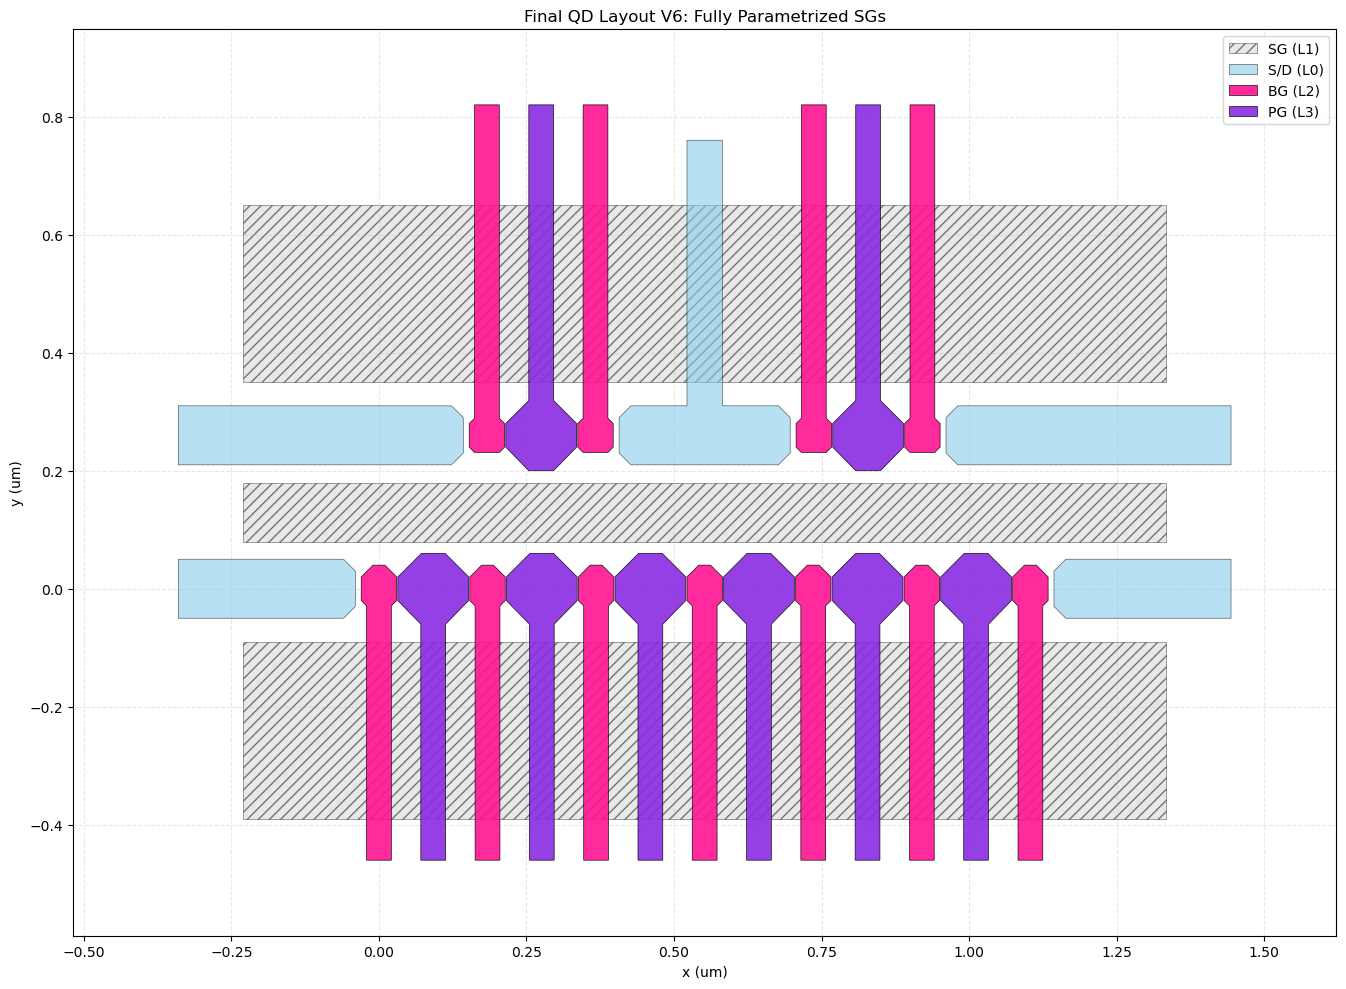

In [4]:
if __name__ == '__main__':
    # ==========================================
    # 在 Main 中定义可调参数
    # ==========================================
    
    # --- 几何尺寸 ---
    pg_max_width = 0.120
    pg_vert_side_len = 0.040
    pg_chamfer_h = 0.040 
    pg_bot_flat_w = 0.042 
    pg_top_flat_w = 0.040 
    
    bg_max_width = 0.060
    bg_vert_side_len = 0.040
    bg_top_flat_w = 0.020 
    bg_bot_flat_w = 0.042 
    
    # --- 间距参数 ---
    gap_pg_bg = 0.002       
    d1_gap = 0.020          
    d2_gap = 0.020          
    sd_gap_to_gate = 0.01   
    gap_gate_outer_sg = 0.030 
    
    # --- SG 参数 ---
    sg_mid_thick = 0.100    
    sg_top_thick = 0.300    
    sg_bot_thick = 0.300    
    sg_extension = 0.200   
    
    # --- 引线参数 ---
    lead_width = 0.042
    lead_length_bot = 0.4  
    lead_length_top = 0.5
    lead_overlap = 0.025    
    
    # --- S/D 参数 ---
    sd_height = 0.10      
    sd_width = 0.35      # 中间S/D宽度
    sd_lead_width = 0.060
    
    # [新增] 专门用于定义外侧四个 S/D 长度的参数 (以量子点阵列行为基准)
    # 结果：顶部 S/D 会自动变长以和底部 S/D 的外边共线
    sd_outer_length = 0.300 
    
    # ==========================================
    # 调用函数生成布局
    # ==========================================
    lib, cell = create_final_layout_v6(
        # 几何
        pg_max_width, pg_vert_side_len, pg_chamfer_h, pg_bot_flat_w, pg_top_flat_w,
        bg_max_width, bg_vert_side_len, bg_top_flat_w, bg_bot_flat_w,
        # 间距
        gap_pg_bg, d1_gap, d2_gap, sd_gap_to_gate, gap_gate_outer_sg,
        # SG 参数
        sg_mid_thick, sg_top_thick, sg_bot_thick, sg_extension,
        # 引线
        lead_width, lead_length_bot, lead_length_top, lead_overlap,
        # S/D
        sd_height, sd_width, sd_lead_width, sd_outer_length
    )
    
    lib.write_gds('qd_device_v6.gds')
    print("GDS saved as 'qd_device_v6.gds'")
    plot_gds(cell)



### Generate Quantum Dot Pad Layout

In [104]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re

def create_balanced_pad_layout(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=150,
    pad_spacing=30,
    edge_margin=100,
    active_size=20,
    gds_filename='qd_pad_layout_detailed.gds'
):
    """
    Generates a Pad Layout GDS with:
    - Equalized Edge Counts (Balanced Overflow).
    - Specific Sequence Order.
    - Annotations for Chip Size, Pad Size, Pad Spacing, and Total Count.
    """

    # ==========================================
    # 1. Prepare Data & Fixed Lists (Same Logic)
    # ==========================================
    
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    # Gate Sequence
    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    # Fixed Edges
    top_pads = []
    if num_sets >= 1: top_pads.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_pads.append("SET_S")
    if num_sets >= 2: top_pads.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    left_fixed = []
    left_fixed.append("SG1")        
    if num_sets >= 1: left_fixed.append("SET1_D") 
    left_fixed.append("SG2")        
    left_fixed.append("QD_D")
    
    right_fixed = []
    if num_sets >= 2: right_fixed.append("SET2_D")
    right_fixed.append("QD_S")
    right_fixed.extend(["GND", "SG3", "GND"]) 

    # ==========================================
    # 2. Global Balancing Algorithm
    # ==========================================
    available_w = layout_width - 2 * edge_margin
    pitch_x = pad_width + pad_spacing
    bottom_capacity = math.floor((available_w + pad_spacing) / pitch_x)
    
    len_seq = len(gate_sequence)
    len_left_fix = len(left_fixed)
    len_right_fix = len(right_fixed)
    total_pads = len_seq + len_left_fix + len_right_fix + len(top_pads) # Include top for total count
    
    # Balancing logic only affects L/R/B
    pads_involved_in_balance = len_seq + len_left_fix + len_right_fix
    target_per_side = pads_involved_in_balance / 3.0
    
    n_seq_left = max(0, int(round(target_per_side)) - len_left_fix)
    n_seq_right = max(0, int(round(target_per_side)) - len_right_fix)
    n_seq_bottom = len_seq - n_seq_left - n_seq_right
    
    if n_seq_bottom > bottom_capacity:
        excess = n_seq_bottom - bottom_capacity
        n_seq_bottom = bottom_capacity
        n_seq_left += math.ceil(excess / 2)
        n_seq_right += math.floor(excess / 2)
        
    pads_left_extra = gate_sequence[:n_seq_left]
    end_idx_bottom = n_seq_left + n_seq_bottom
    pads_bottom = gate_sequence[n_seq_left : end_idx_bottom]
    pads_right_extra = gate_sequence[end_idx_bottom:]

    left_pads = left_fixed + pads_left_extra
    right_pads = right_fixed + pads_right_extra

    # ==========================================
    # 3. Coordinate Generation
    # ==========================================
    placements = []

    def calc_placements(pads, edge):
        count = len(pads)
        if count == 0: return

        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            
            for i, label in enumerate(pads):
                x = start_x + i * (pad_width + pad_spacing)
                placements.append({
                    'label': label,
                    'rect': (x, y, pad_width, pad_height),
                    'edge': edge
                })
        else: # left, right
            w_side = pad_height 
            h_side = pad_width
            total_span = count * h_side + (count - 1) * pad_spacing
            start_y = (layout_height + total_span) / 2 - h_side 
            x = edge_margin if edge == 'left' else layout_width - edge_margin - w_side
            
            for i, label in enumerate(pads):
                y = start_y - i * (h_side + pad_spacing)
                placements.append({
                    'label': label,
                    'rect': (x, y, w_side, h_side),
                    'edge': edge
                })

    calc_placements(top_pads, 'top')
    calc_placements(pads_bottom, 'bottom')
    calc_placements(left_pads, 'left')
    calc_placements(right_pads, 'right')

    # ==========================================
    # 4. GDS Generation
    # ==========================================
    lib = gdstk.Library()
    cell = lib.new_cell('PAD_LAYOUT_DETAILED')

    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=0))
    
    aa_start = (layout_width/2 - active_size/2, layout_height/2 - active_size/2)
    aa_end = (layout_width/2 + active_size/2, layout_height/2 + active_size/2)
    cell.add(gdstk.rectangle(aa_start, aa_end, layer=10))

    for p in placements:
        x, y, w, h = p['rect']
        label = p['label']
        cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=1))
        
        cx, cy = x + w/2, y + h/2
        rot_rad = 0 if w > h else math.pi / 2
        text = gdstk.Label(label, (cx, cy), layer=2, magnification=10, rotation=rot_rad)
        cell.add(text)

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # ==========================================
    # 5. Visualization with Detailed Annotations
    # ==========================================
    fig, ax = plt.subplots(figsize=(13, 13))
    margin_view = 300
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    # Chip & Active Area
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f0f0f0')
    ax.add_patch(chip)
    active_area = patches.Rectangle(aa_start, active_size, active_size, lw=1, ec='red', fc='red')
    ax.add_patch(active_area)
    ax.annotate(f'Active Area\n({active_size}x{active_size})', xy=(layout_width/2, layout_height/2), 
                xytext=(layout_width/2, layout_height/2 + 200),
                arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
                ha='center', color='red', fontsize=10)

    # Draw Pads
    for p in placements:
        x, y, w, h = p['rect']
        label = p['label']
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=7, rotation=t_rot)

    # --- Dimension Lines (Chip Size) ---
    dim_color = 'blue'
    dim_y = -150
    ax.annotate('', xy=(0, dim_y), xytext=(layout_width, dim_y), arrowprops=dict(arrowstyle='<->', lw=1.5, color=dim_color))
    ax.text(layout_width/2, dim_y - 50, f'Chip Width = {layout_width} um', ha='center', va='top', color=dim_color, fontsize=11)
    ax.plot([0, 0], [0, dim_y], color=dim_color, linestyle='--', lw=0.5, alpha=0.5)
    ax.plot([layout_width, layout_width], [0, dim_y], color=dim_color, linestyle='--', lw=0.5, alpha=0.5)

    dim_x = -150
    ax.annotate('', xy=(dim_x, 0), xytext=(dim_x, layout_height), arrowprops=dict(arrowstyle='<->', lw=1.5, color=dim_color))
    ax.text(dim_x - 50, layout_height/2, f'Chip Height = {layout_height} um', ha='right', va='center', color=dim_color, fontsize=11, rotation=90)
    ax.plot([0, dim_x], [0, 0], color=dim_color, linestyle='--', lw=0.5, alpha=0.5)
    ax.plot([0, dim_x], [layout_height, layout_height], color=dim_color, linestyle='--', lw=0.5, alpha=0.5)

    # --- Pad Dimensions & Spacing Annotations (Magenta) ---
    # Find Top Row Pads for annotation
    top_row_pads = [p for p in placements if p['edge'] == 'top']
    top_row_pads.sort(key=lambda p: p['rect'][0]) # Sort by X

    if len(top_row_pads) >= 2:
        p1 = top_row_pads[0]
        p2 = top_row_pads[1]
        x1, y1, w1, h1 = p1['rect']
        x2, y2, w2, h2 = p2['rect']
        
        detail_color = '#C71585' # Medium Violet Red / Magenta-ish

        # 1. Pad Width
        dim_y_pad = y1 + h1 + 40
        ax.annotate('', xy=(x1, dim_y_pad), xytext=(x1 + w1, dim_y_pad), 
                    arrowprops=dict(arrowstyle='<->', lw=1.2, color=detail_color))
        ax.text(x1 + w1/2, dim_y_pad + 10, f'W={w1}', ha='center', va='bottom', color=detail_color, fontsize=9)
        # Guidelines
        ax.plot([x1, x1], [y1+h1, dim_y_pad], color=detail_color, linestyle=':', lw=0.5)
        ax.plot([x1+w1, x1+w1], [y1+h1, dim_y_pad], color=detail_color, linestyle=':', lw=0.5)

        # 2. Pad Height
        dim_x_pad = x1 - 40
        ax.annotate('', xy=(dim_x_pad, y1), xytext=(dim_x_pad, y1 + h1), 
                    arrowprops=dict(arrowstyle='<->', lw=1.2, color=detail_color))
        ax.text(dim_x_pad - 10, y1 + h1/2, f'H={h1}', ha='right', va='center', color=detail_color, fontsize=9, rotation=90)
        # Guidelines
        ax.plot([x1, dim_x_pad], [y1, y1], color=detail_color, linestyle=':', lw=0.5)
        ax.plot([x1, dim_x_pad], [y1+h1, y1+h1], color=detail_color, linestyle=':', lw=0.5)

        # 3. Spacing (Gap)
        # Between end of P1 and start of P2
        mid_y = y1 + h1/2
        ax.annotate('', xy=(x1+w1, mid_y), xytext=(x2, mid_y), 
                    arrowprops=dict(arrowstyle='<->', lw=1.2, color=detail_color))
        ax.text((x1+w1+x2)/2, mid_y - 60, f'Gap\n{pad_spacing}', ha='center', va='top', color=detail_color, fontsize=9)

    # Update Title
    # pad_counts_str = f"L={len(left_pads)} / B={len(pads_bottom)} / R={len(right_pads)} / T={len(top_pads)}"
    # plt.title(f"Quantum Dot Pad Layout (N={N})\nTotal Pads: {total_pads} ({pad_counts_str})", fontsize=16, pad=20)
    plt.title(f"Quantum Dot Pad Layout (N={N})", fontsize=16, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

GDS file saved to: Six-Dot_pad_layout.gds


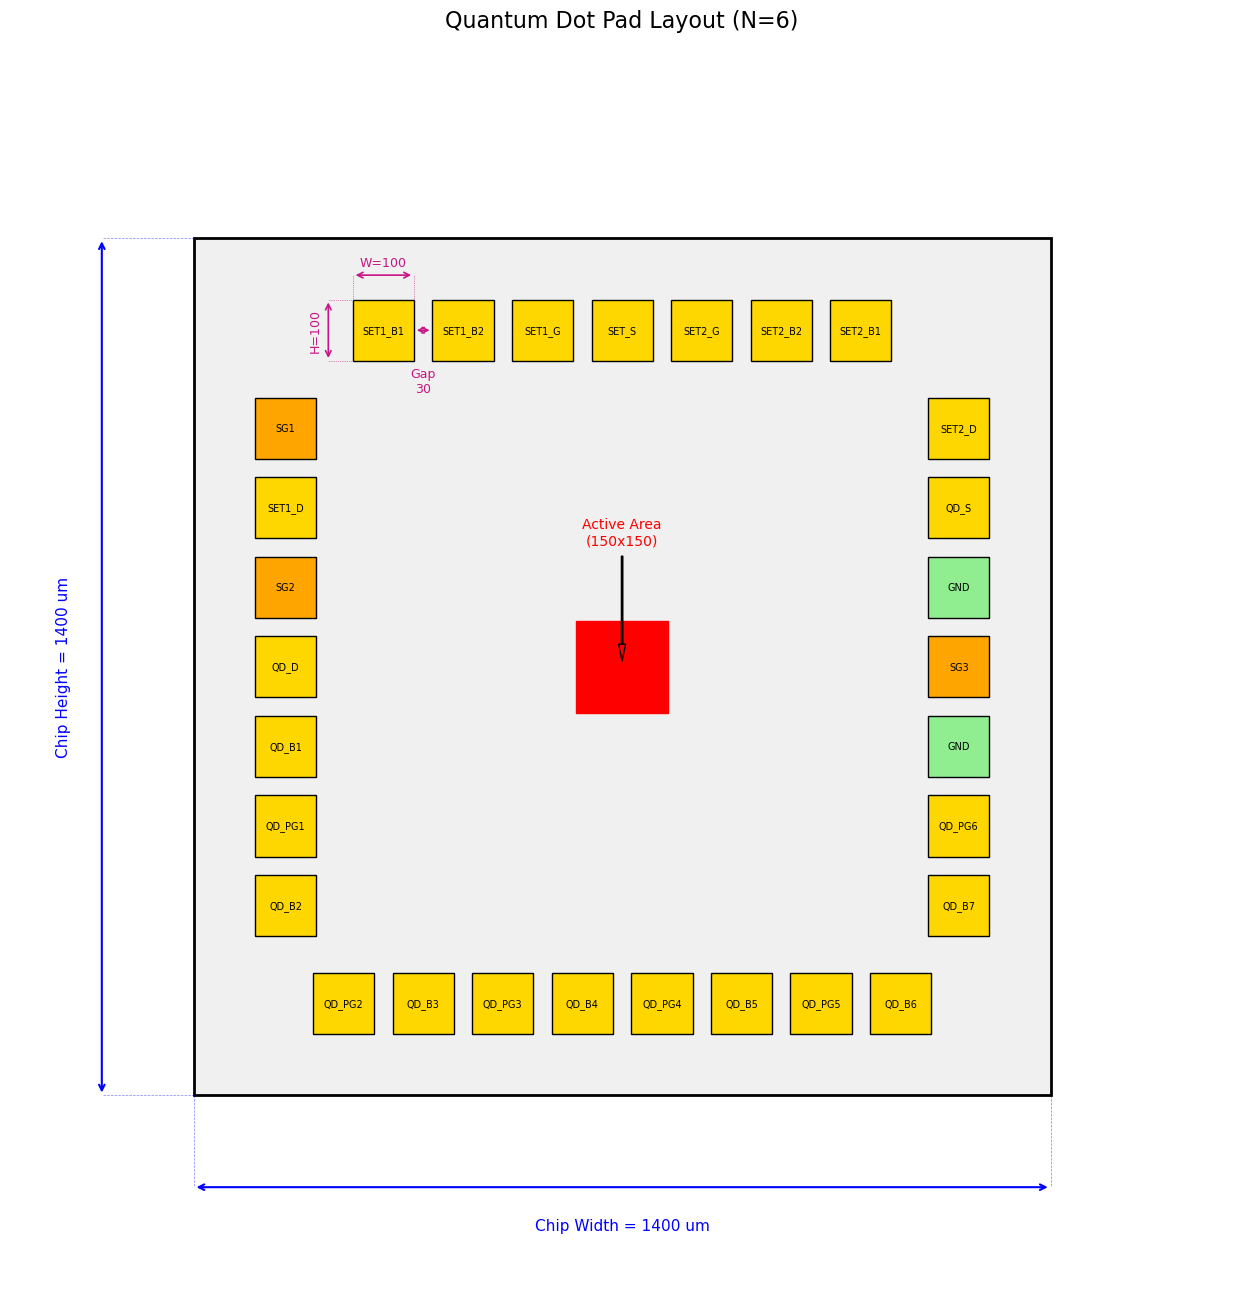

In [110]:
if __name__ == '__main__':
    # ==========================================
    # 可调参数输入
    # ==========================================
    create_balanced_pad_layout(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,
        pad_spacing = 30,
        edge_margin = 100,
        active_size = 150,
        gds_filename='Six-Dot_pad_layout.gds'   
    )

GDS file saved to: qd_layout_ortho.gds


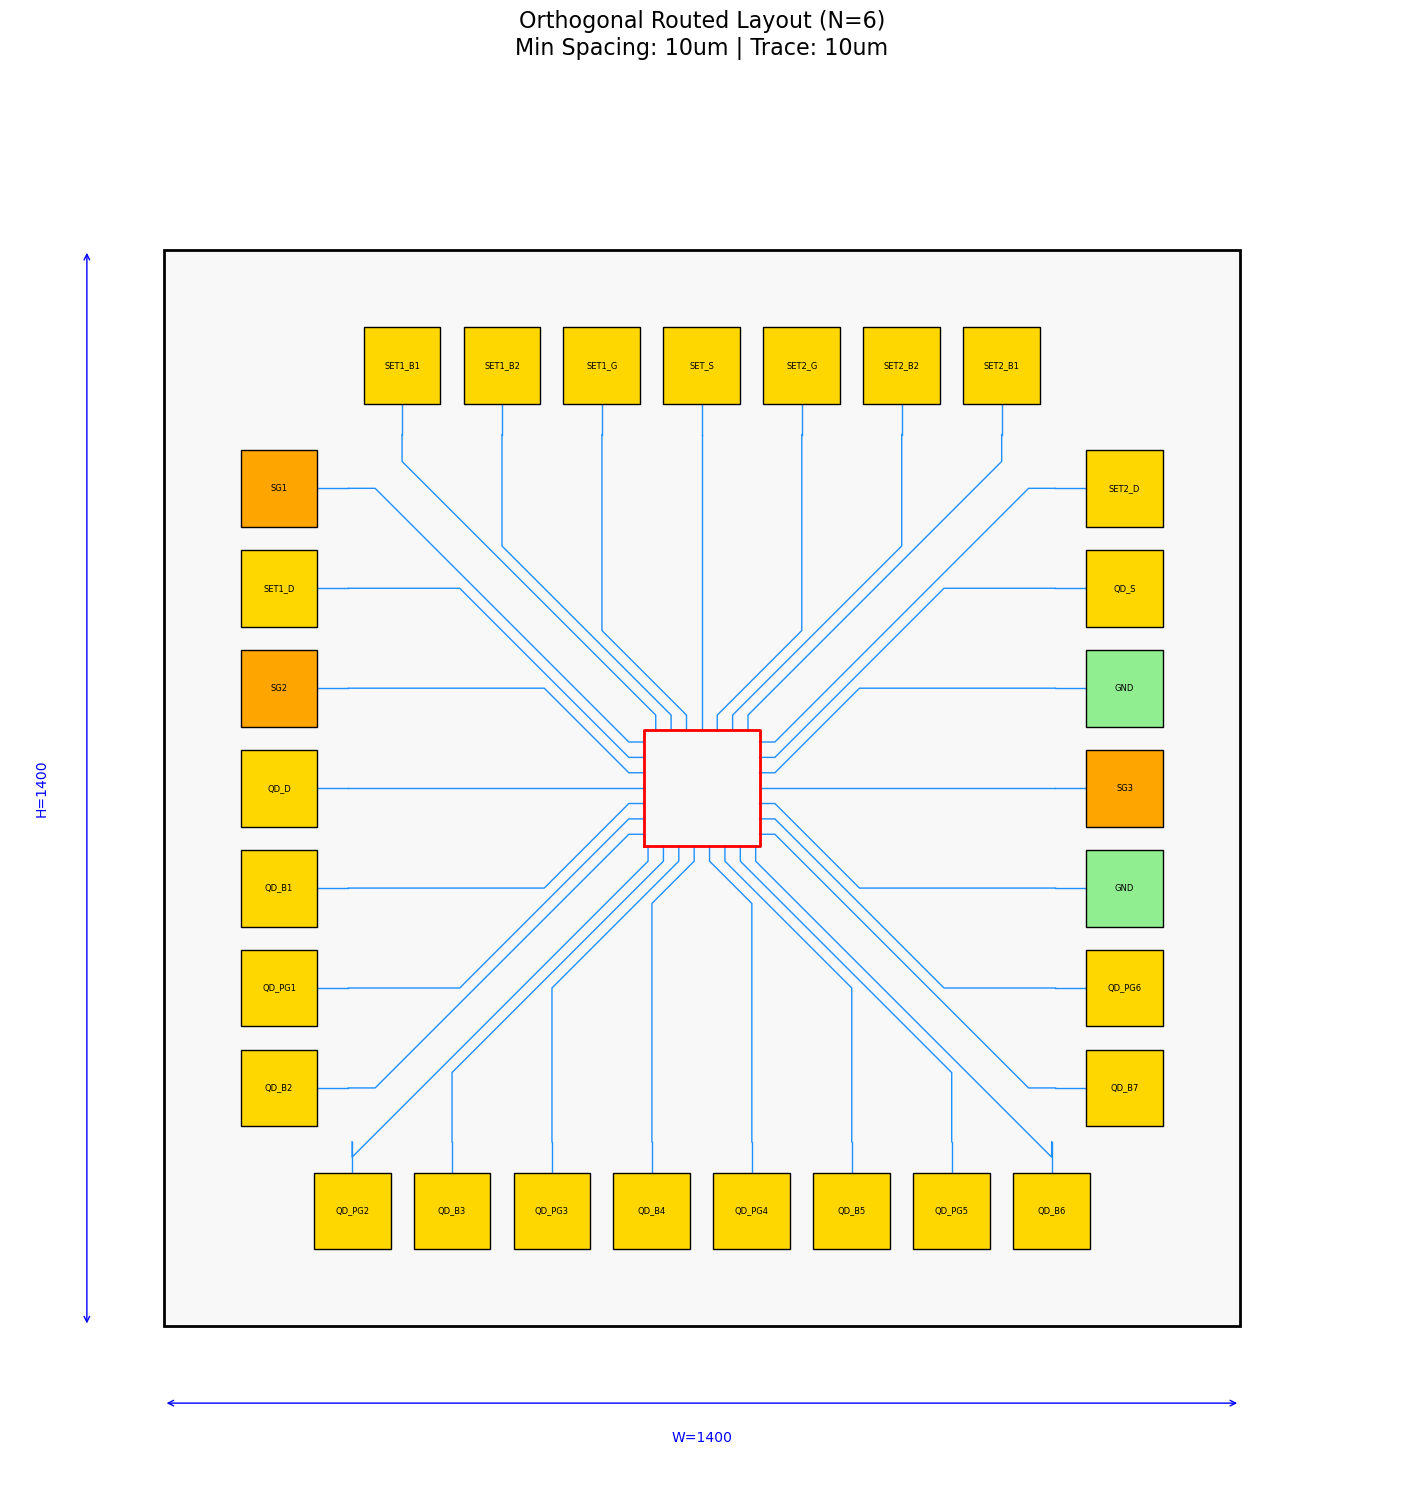

In [116]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re
import numpy as np

def create_ortho_routed_layout(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=100,      # Update: 100
    pad_spacing=30,
    edge_margin=100,
    active_size=100,     # Update: 100
    trace_width=10,
    trace_spacing=10,    # New: Min spacing requirement
    taper_length=40,
    active_entry_len=20, # New: How long the wire goes straight before hitting AA
    gds_filename='qd_layout_ortho.gds'
):
    """
    Generates a Pad Layout with:
    - Z-shaped routing (Manhattan exit/entry + 45 deg mid).
    - Perpendicular entry to Active Region.
    - Min spacing enforcement at the bottleneck (Active Area).
    """

    # ==========================================
    # 1. Pad Classification Logic (Balanced)
    # ==========================================
    
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    top_pads = []
    if num_sets >= 1: top_pads.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_pads.append("SET_S")
    if num_sets >= 2: top_pads.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    left_fixed = ["SG1"]
    if num_sets >= 1: left_fixed.append("SET1_D") 
    left_fixed.extend(["SG2", "QD_D"])
    
    right_fixed = []
    if num_sets >= 2: right_fixed.append("SET2_D")
    right_fixed.append("QD_S")
    right_fixed.extend(["GND", "SG3", "GND"]) 

    available_w = layout_width - 2 * edge_margin
    pitch_x_pad = pad_width + pad_spacing
    bottom_capacity = math.floor((available_w + pad_spacing) / pitch_x_pad)
    
    len_seq = len(gate_sequence)
    # Balancing algorithm
    pads_involved = len_seq + len(left_fixed) + len(right_fixed)
    target_per_side = pads_involved / 3.0
    
    n_seq_left = max(0, int(round(target_per_side)) - len(left_fixed))
    n_seq_right = max(0, int(round(target_per_side)) - len(right_fixed))
    n_seq_bottom = len_seq - n_seq_left - n_seq_right
    
    if n_seq_bottom > bottom_capacity:
        excess = n_seq_bottom - bottom_capacity
        n_seq_bottom = bottom_capacity
        n_seq_left += math.ceil(excess / 2)
        n_seq_right += math.floor(excess / 2)
        
    pads_left_extra = gate_sequence[:n_seq_left]
    end_idx_bottom = n_seq_left + n_seq_bottom
    pads_bottom = gate_sequence[n_seq_left : end_idx_bottom]
    pads_right_extra = gate_sequence[end_idx_bottom:]

    left_pads = left_fixed + pads_left_extra
    right_pads = right_fixed + pads_right_extra

    # ==========================================
    # 2. Coordinate Generation
    # ==========================================
    placements = []

    def assign_coords(pads, edge):
        pad_list_local = []
        count = len(pads)
        if count == 0: return pad_list_local

        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            
            for i, label in enumerate(pads):
                x = start_x + i * (pad_width + pad_spacing)
                pad_list_local.append({'label': label, 'rect': (x, y, pad_width, pad_height), 'edge': edge})
        else:
            w_side = pad_height 
            h_side = pad_width
            total_span = count * h_side + (count - 1) * pad_spacing
            start_y = (layout_height + total_span) / 2 - h_side 
            x = edge_margin if edge == 'left' else layout_width - edge_margin - w_side
            
            for i, label in enumerate(pads):
                y = start_y - i * (h_side + pad_spacing)
                pad_list_local.append({'label': label, 'rect': (x, y, w_side, h_side), 'edge': edge})
        return pad_list_local

    placements.extend(assign_coords(top_pads, 'top'))
    placements.extend(assign_coords(pads_bottom, 'bottom'))
    placements.extend(assign_coords(left_pads, 'left'))
    placements.extend(assign_coords(right_pads, 'right'))

    # ==========================================
    # 3. Routing Logic (Z-Shape)
    # ==========================================
    lib = gdstk.Library()
    cell = lib.new_cell('QD_ORTHO_ROUTED')

    LAYER_SUBSTRATE = 0
    LAYER_PAD = 1
    LAYER_TEXT = 2
    LAYER_TRACE = 3
    LAYER_ACTIVE = 10

    # Draw Chip & Active Area
    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=LAYER_SUBSTRATE))
    
    aa_center_x, aa_center_y = layout_width/2, layout_height/2
    aa_start = (aa_center_x - active_size/2, aa_center_y - active_size/2)
    aa_end = (aa_center_x + active_size/2, aa_center_y + active_size/2)
    cell.add(gdstk.rectangle(aa_start, aa_end, layer=LAYER_ACTIVE))

    # --- Taper Function ---
    def create_taper(p_rect, edge, t_len, t_width):
        x, y, w, h = p_rect
        cx, cy = x + w/2, y + h/2
        
        if edge == 'top':
            p_start_y = y 
            pts = [(x, p_start_y), (x + w, p_start_y), (cx + t_width/2, p_start_y - t_len), (cx - t_width/2, p_start_y - t_len)]
            trace_start = (cx, p_start_y - t_len)
        elif edge == 'bottom':
            p_start_y = y + h
            pts = [(x, p_start_y), (x + w, p_start_y), (cx + t_width/2, p_start_y + t_len), (cx - t_width/2, p_start_y + t_len)]
            trace_start = (cx, p_start_y + t_len)
        elif edge == 'left':
            p_start_x = x + w 
            pts = [(p_start_x, y), (p_start_x, y + h), (p_start_x + t_len, cy + t_width/2), (p_start_x + t_len, cy - t_width/2)]
            trace_start = (p_start_x + t_len, cy)
        elif edge == 'right':
            p_start_x = x 
            pts = [(p_start_x, y), (p_start_x, y + h), (p_start_x - t_len, cy + t_width/2), (p_start_x - t_len, cy - t_width/2)]
            trace_start = (p_start_x - t_len, cy)
            
        return gdstk.Polygon(pts, layer=LAYER_TRACE), trace_start

    # --- Z-Routing Function (Ortho + 45) ---
    def route_z_shape(start_pt, target_pt, edge, width):
        """
        Routes from Pad Taper (Start) to Active Edge (Target).
        Path:
        1. Straight out from pad (Vertical or Horizontal).
        2. 45-degree Diagonal.
        3. Straight into Active Area (Perpendicular).
        """
        x1, y1 = start_pt
        x2, y2 = target_pt
        
        pts = [(x1, y1)]
        
        # Calculate intermediate turning points
        # For Top/Bottom: We move Y first (Straight), then Diagonal, then Straight Y to target.
        # However, to ensure 45 deg, |dx| must equal |dy_diag|.
        
        # We enforce a straight entry into Active Area of length 'active_entry_len'.
        # This fixes the Y-coordinate of the last turn.
        
        if edge in ['top', 'bottom']:
            # Direction check
            is_top = (edge == 'top')
            entry_dy = active_entry_len if is_top else -active_entry_len 
            # Note: If top pad, we go down. Target is below. y2 is top of AA.
            # We want to arrive at y2 from above. Last segment: (x2, y2 + entry_len) -> (x2, y2).
            
            y_turn_2 = y2 + entry_dy 
            
            # Now we need to go from (x1, y1) to (x2, y_turn_2) using V -> D.
            # The Diagonal part connects (some_x, some_y) to (x2, y_turn_2).
            # But the diagonal must start from x1 to conserve X order and prevent collisions.
            # So Diagonal is (x1, y_turn_1) -> (x2, y_turn_2).
            # Constraint: |x2 - x1| == |y_turn_2 - y_turn_1|
            
            dx = abs(x2 - x1)
            dy_needed = dx
            
            # Calculate y_turn_1
            # If Top: y1 > y2. We go down. y_turn_1 must be above y_turn_2.
            # y_turn_1 = y_turn_2 + dy_needed
            if is_top:
                y_turn_1 = y_turn_2 + dy_needed
            else: # Bottom
                # y1 < y2. We go up. y_turn_1 must be below y_turn_2.
                y_turn_1 = y_turn_2 - dy_needed
            
            # Check physical feasibility (Does y_turn_1 overshoot the pad?)
            # If y_turn_1 is "behind" y1 (inside pad), we have a problem (pad too close or lateral shift too huge).
            # But here chip is 1400, AA is 100. Gap is huge. It should fit.
            
            pts.append((x1, y_turn_1)) # End of first straight segment
            pts.append((x2, y_turn_2)) # End of diagonal segment
            pts.append((x2, y2))       # End of entry segment
            
        else: # Left/Right
            is_left = (edge == 'left')
            # Entry is horizontal.
            # Left Pad: Target x2 is left edge of AA. Arrive from left.
            # Segment: (x2 - entry_len, y2) -> (x2, y2)
            
            entry_dx = -active_entry_len if is_left else active_entry_len
            x_turn_2 = x2 + entry_dx
            
            # Diagonal: (x_turn_1, y1) -> (x_turn_2, y2)
            # |y2 - y1| == |x_turn_2 - x_turn_1|
            dy = abs(y2 - y1)
            dx_needed = dy
            
            if is_left:
                # x1 < x2. Go right. x_turn_1 < x_turn_2
                x_turn_1 = x_turn_2 - dx_needed
            else: # Right
                # x1 > x2. Go left. x_turn_1 > x_turn_2
                x_turn_1 = x_turn_2 + dx_needed
                
            pts.append((x_turn_1, y1))
            pts.append((x_turn_2, y2))
            pts.append((x2, y2))
            
        return gdstk.FlexPath(pts, width, layer=LAYER_TRACE), pts

    # --- Target Calculation with Min Spacing ---
    tops = [p for p in placements if p['edge'] == 'top']
    bottoms = [p for p in placements if p['edge'] == 'bottom']
    lefts = [p for p in placements if p['edge'] == 'left']
    rights = [p for p in placements if p['edge'] == 'right']

    ax1, ay1 = aa_start
    ax2, ay2 = aa_end
    
    # Calculate trace pitch
    trace_pitch = trace_width + trace_spacing
    
    def get_centered_targets(pads, edge):
        targets = []
        n = len(pads)
        if n == 0: return targets
        
        # Total width required for traces
        total_trace_width = (n - 1) * trace_pitch
        
        # Center this block on the Active Area edge
        if edge in ['top', 'bottom']:
            # Sort by X to match Pad order
            pads.sort(key=lambda p: p['rect'][0])
            center_x = aa_center_x
            start_x = center_x - total_trace_width / 2
            tgt_y = ay2 if edge == 'top' else ay1
            for i in range(n):
                tx = start_x + i * trace_pitch
                targets.append((tx, tgt_y))
        else:
            # Sort by Y (Top to Bottom) to match Pad order
            pads.sort(key=lambda p: p['rect'][1], reverse=True)
            center_y = aa_center_y
            start_y = center_y + total_trace_width / 2 # Start from top
            tgt_x = ax1 if edge == 'left' else ax2
            for i in range(n):
                ty = start_y - i * trace_pitch
                targets.append((tgt_x, ty))
        return targets

    groups = [
        (tops, get_centered_targets(tops, 'top')),
        (bottoms, get_centered_targets(bottoms, 'bottom')),
        (lefts, get_centered_targets(lefts, 'left')),
        (rights, get_centered_targets(rights, 'right'))
    ]

    for pads_group, targets_group in groups:
        for pad_data, target_pt in zip(pads_group, targets_group):
            x, y, w, h = pad_data['rect']
            label = pad_data['label']
            edge = pad_data['edge']
            
            # GDS Pad
            cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=LAYER_PAD))
            
            # GDS Label
            cx, cy = x + w/2, y + h/2
            rot_rad = 0 if w > h else math.pi / 2
            cell.add(gdstk.Label(label, (cx, cy), layer=LAYER_TEXT, magnification=10, rotation=rot_rad))
            
            # GDS Taper
            poly_taper, trace_start_pt = create_taper(pad_data['rect'], edge, taper_length, trace_width)
            cell.add(poly_taper)
            
            # GDS Route
            path_obj, path_points = route_z_shape(trace_start_pt, target_pt, edge, trace_width)
            cell.add(path_obj)
            
            pad_data['trace_points'] = path_points

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # ==========================================
    # 4. Matplotlib Visualization
    # ==========================================
    fig, ax = plt.subplots(figsize=(15, 15))
    margin_view = 200
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f8f8f8')
    ax.add_patch(chip)
    
    # Active Area (Zoomed for visibility if needed, but here drawn to scale)
    active_area = patches.Rectangle(aa_start, active_size, active_size, lw=1, ec='red', fc='none', zorder=10)
    ax.add_patch(active_area)

    for p in placements:
        x, y, w, h = p['rect']
        label = p['label']
        
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc, zorder=5)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=6, rotation=t_rot, zorder=6)
        
        if 'trace_points' in p:
            pts = p['trace_points']
            line_x, line_y = zip(*pts)
            # Connect taper start visually
            taper_poly, t_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
            # Plot trace
            ax.plot(line_x, line_y, color='#1E90FF', linewidth=1, zorder=4)
            # Plot Taper Line (approx)
            cx, cy = x + w/2, y + h/2
            ax.plot([cx, pts[0][0]], [cy, pts[0][1]], color='#1E90FF', linewidth=1, zorder=4)

    # Dimensions
    dim_color = 'blue'
    dim_y = -100
    ax.annotate('', xy=(0, dim_y), xytext=(layout_width, dim_y), arrowprops=dict(arrowstyle='<->', color=dim_color))
    ax.text(layout_width/2, dim_y - 50, f'W={layout_width}', ha='center', color=dim_color)

    dim_x = -100
    ax.annotate('', xy=(dim_x, 0), xytext=(dim_x, layout_height), arrowprops=dict(arrowstyle='<->', color=dim_color))
    ax.text(dim_x - 50, layout_height/2, f'H={layout_height}', ha='right', va='center', color=dim_color, rotation=90)
    
    # Zoom View annotation
    ax.plot([aa_start[0], aa_end[0], aa_end[0], aa_start[0], aa_start[0]], 
            [aa_start[1], aa_start[1], aa_end[1], aa_end[1], aa_start[1]], color='red', linewidth=2, zorder=11)
    
    plt.title(f"Orthogonal Routed Layout (N={N})\nMin Spacing: {trace_spacing}um | Trace: {trace_width}um", fontsize=16, pad=30)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    create_ortho_routed_layout(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 100,
        active_size = 150,     
        trace_width = 10,
        trace_spacing = 10,
        taper_length = 40,
        active_entry_len = 20
    )

GDS file saved to: qd_layout_no_crossing.gds


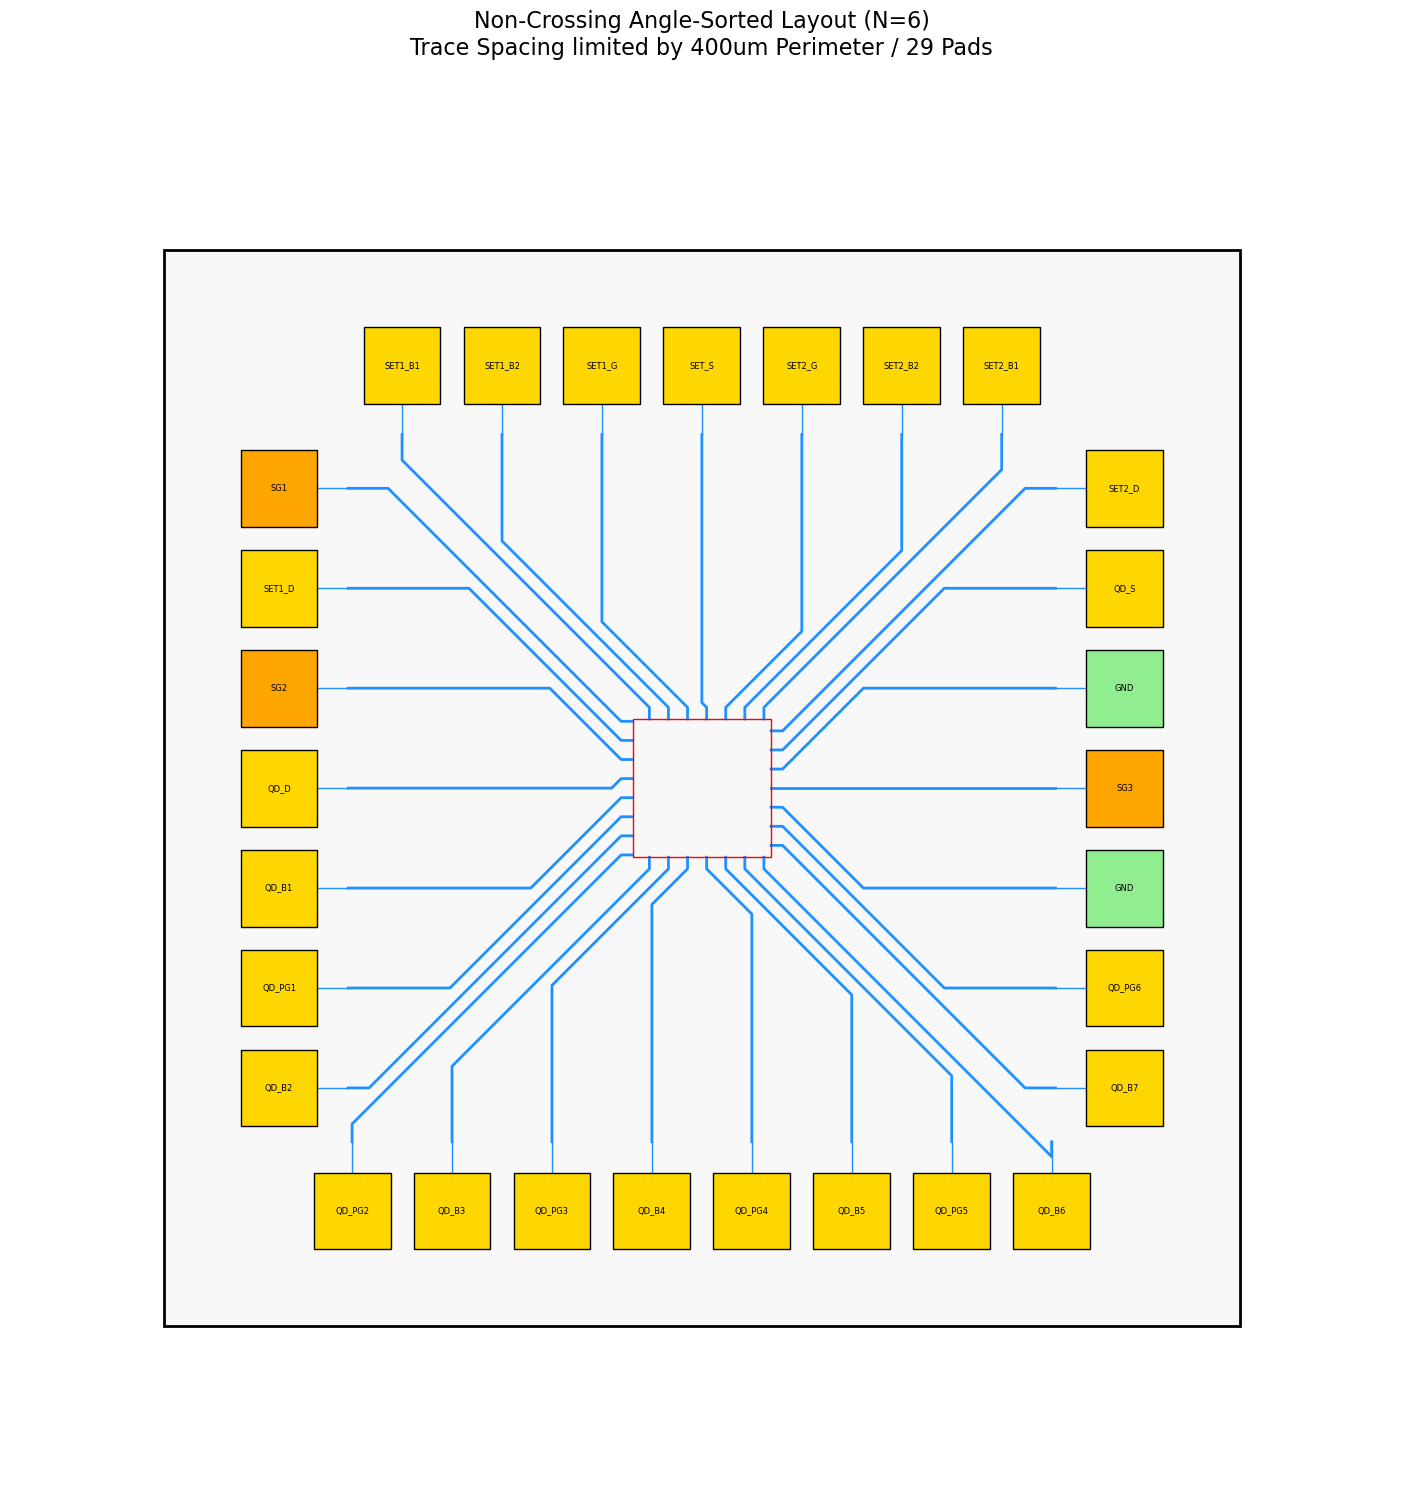

In [120]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re
import numpy as np

def create_non_crossing_layout(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=100,      
    pad_spacing=30,
    edge_margin=100,
    active_size=100,     
    trace_width=10,
    taper_length=40,
    active_entry_len=15, # Length of straight segment entering Active Area
    gds_filename='qd_layout_no_crossing.gds'
):
    """
    Generates a Pad Layout with Global Angle-Based Routing to guarantee NO CROSSINGS.
    
    Logic:
    1. Collect all pads.
    2. Sort pads by angle relative to center.
    3. Map pads to target points along the Active Area perimeter in the same angular order.
    4. Route using flexible Z-shapes.
    """

    # ==========================================
    # 1. Pad Classification & Generation
    # ==========================================
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    top_pads = []
    if num_sets >= 1: top_pads.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_pads.append("SET_S")
    if num_sets >= 2: top_pads.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    left_fixed = ["SG1"]
    if num_sets >= 1: left_fixed.append("SET1_D") 
    left_fixed.extend(["SG2", "QD_D"])
    
    right_fixed = []
    if num_sets >= 2: right_fixed.append("SET2_D")
    right_fixed.append("QD_S")
    right_fixed.extend(["GND", "SG3", "GND"]) 

    # Balancing Logic
    available_w = layout_width - 2 * edge_margin
    pitch_x_pad = pad_width + pad_spacing
    bottom_capacity = math.floor((available_w + pad_spacing) / pitch_x_pad)
    
    len_seq = len(gate_sequence)
    total_pads = len_seq + len(left_fixed) + len(right_fixed) + len(top_pads)
    pads_involved = len_seq + len(left_fixed) + len(right_fixed)
    target_per_side = pads_involved / 3.0
    
    n_seq_left = max(0, int(round(target_per_side)) - len(left_fixed))
    n_seq_right = max(0, int(round(target_per_side)) - len(right_fixed))
    n_seq_bottom = len_seq - n_seq_left - n_seq_right
    
    if n_seq_bottom > bottom_capacity:
        excess = n_seq_bottom - bottom_capacity
        n_seq_bottom = bottom_capacity
        n_seq_left += math.ceil(excess / 2)
        n_seq_right += math.floor(excess / 2)
        
    pads_left_extra = gate_sequence[:n_seq_left]
    end_idx_bottom = n_seq_left + n_seq_bottom
    pads_bottom = gate_sequence[n_seq_left : end_idx_bottom]
    pads_right_extra = gate_sequence[end_idx_bottom:]

    left_pads = left_fixed + pads_left_extra
    right_pads = right_fixed + pads_right_extra

    # ==========================================
    # 2. Pad Coordinate Assignment
    # ==========================================
    all_pads = [] # List of dicts

    def assign_coords(pads, edge):
        count = len(pads)
        if count == 0: return

        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            
            for i, label in enumerate(pads):
                x = start_x + i * (pad_width + pad_spacing)
                # Store Center for Angle calculation
                cx, cy = x + pad_width/2, y + pad_height/2
                all_pads.append({
                    'label': label, 
                    'rect': (x, y, pad_width, pad_height), 
                    'center': (cx, cy),
                    'edge': edge
                })
        else:
            w_side = pad_height 
            h_side = pad_width
            total_span = count * h_side + (count - 1) * pad_spacing
            start_y = (layout_height + total_span) / 2 - h_side 
            x = edge_margin if edge == 'left' else layout_width - edge_margin - w_side
            
            for i, label in enumerate(pads):
                y = start_y - i * (h_side + pad_spacing)
                cx, cy = x + w_side/2, y + h_side/2
                all_pads.append({
                    'label': label, 
                    'rect': (x, y, w_side, h_side), 
                    'center': (cx, cy),
                    'edge': edge
                })

    assign_coords(top_pads, 'top')
    assign_coords(pads_bottom, 'bottom')
    assign_coords(left_pads, 'left')
    assign_coords(right_pads, 'right')

    # ==========================================
    # 3. Angle-Based Target Assignment (The Core Fix)
    # ==========================================
    
    center_x = layout_width / 2
    center_y = layout_height / 2
    
    # 1. Calculate Angle for each pad
    for p in all_pads:
        px, py = p['center']
        # atan2 returns -pi to pi.
        # We want a continuous sort. Let's map to 0-360 starting from East (Right) counter-clockwise?
        # Or start from Top?
        # Let's standard atan2 (East = 0, North = 90, West = 180/-180, South = -90)
        angle = math.atan2(py - center_y, px - center_x)
        p['angle'] = angle

    # 2. Sort pads by angle
    # We want a continuous loop. Let's sort from -PI to +PI
    # This roughly corresponds to: Left-Bottom -> Bottom -> Right-Bottom -> Right-Top -> Top -> Left-Top
    # Check atan2 ranges:
    # Top: ~pi/2. Bottom: ~-pi/2. Left: ~pi (or -pi). Right: ~0.
    # Sort order: -PI to PI starts at West(low), goes South, East, North, West(high).
    # This works perfectly for a counter-clockwise unwrap.
    all_pads.sort(key=lambda p: p['angle'])

    # 3. Map to Perimeter
    # Active Area box
    aa_x1 = center_x - active_size/2
    aa_x2 = center_x + active_size/2
    aa_y1 = center_y - active_size/2
    aa_y2 = center_y + active_size/2
    
    perimeter_len = 2 * (active_size + active_size)
    n_pads = len(all_pads)
    # Distance between targets on perimeter
    # Note: 400um / 23 pads ~= 17.4um.
    # If we insist on 20um (10 trace + 10 space), we physically can't fit.
    # We will use the MAX available spacing.
    step = perimeter_len / n_pads
    
    # We need to align the "phase" of the mapping so Top pads hit Top edge, etc.
    # Pad angles are roughly:
    # Bottom: -90 (-1.57)
    # Right: 0
    # Top: 90 (1.57)
    # Left: 180 (3.14) / -180 (-3.14)
    
    # Perimeter mapping (0 to 400):
    # Let's define 0 at Center-Left (-x, 0)? No, let's match atan2.
    # atan2 discontinuity is at -x (Left).
    # Let's start mapping perimeter from the angle -PI (Left Edge, middle).
    
    # Perimeter path: Start Left-Mid -> Bottom-Left -> Bottom-Right -> Right-Top -> Top-Left -> Left-Mid
    # Coordinates of perimeter based on "distance travelled" 'd' from Left-Mid (aa_x1, center_y) going Counter-Clockwise (Down first)
    
    def get_perimeter_point_and_normal(dist):
        # Unwind the box.
        # Start: (x1, cy) going down to (x1, y1) -> length = active_size/2
        d = dist % perimeter_len # Wrap around
        
        # Segment 1: Left Edge (Mid to Bottom)
        seg1 = active_size / 2
        if d < seg1:
            # Moving down on Left Edge
            return (aa_x1, center_y - d), 'left' # Normal points Left
        
        # Segment 2: Bottom Edge (Left to Right)
        seg2 = seg1 + active_size
        if d < seg2:
            remain = d - seg1
            return (aa_x1 + remain, aa_y1), 'bottom'
        
        # Segment 3: Right Edge (Bottom to Top)
        seg3 = seg2 + active_size
        if d < seg3:
            remain = d - seg2
            return (aa_x2, aa_y1 + remain), 'right'
            
        # Segment 4: Top Edge (Right to Left)
        seg4 = seg3 + active_size
        if d < seg4:
            remain = d - seg3
            return (aa_x2 - remain, aa_y2), 'top'
            
        # Segment 5: Left Edge (Top to Mid)
        remain = d - seg4
        return (aa_x1, aa_y2 - remain), 'left'

    # Shift phase to align roughly with pad distribution
    # We have sorted pads -PI to PI. -PI is Left edge.
    # Our perimeter walk starts at Left edge.
    # Perfect alignment!
    
    for i, p in enumerate(all_pads):
        dist = i * step
        # Add a small offset so we don't start exactly at the corner if possible, 
        # or center the distribution
        dist += step / 2 
        
        tgt_pt, edge_normal = get_perimeter_point_and_normal(dist)
        p['target'] = tgt_pt
        p['target_edge'] = edge_normal

    # ==========================================
    # 4. Routing Logic (Flexible Z-Router)
    # ==========================================
    lib = gdstk.Library()
    cell = lib.new_cell('QD_NO_CROSS')

    LAYER_SUBSTRATE = 0
    LAYER_PAD = 1
    LAYER_TEXT = 2
    LAYER_TRACE = 3
    LAYER_ACTIVE = 10

    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=LAYER_SUBSTRATE))
    cell.add(gdstk.rectangle((aa_x1, aa_y1), (aa_x2, aa_y2), layer=LAYER_ACTIVE))

    def create_taper(p_rect, edge, t_len, t_width):
        x, y, w, h = p_rect
        cx, cy = x + w/2, y + h/2
        
        # Define Taper geometry
        if edge == 'top':
            pts = [(x, y), (x+w, y), (cx+t_width/2, y-t_len), (cx-t_width/2, y-t_len)]
            start = (cx, y - t_len)
        elif edge == 'bottom':
            pts = [(x, y+h), (x+w, y+h), (cx+t_width/2, y+h+t_len), (cx-t_width/2, y+h+t_len)]
            start = (cx, y + h + t_len)
        elif edge == 'left':
            pts = [(x+w, y), (x+w, y+h), (x+w+t_len, cy+t_width/2), (x+w+t_len, cy-t_width/2)]
            start = (x+w+t_len, cy)
        elif edge == 'right':
            pts = [(x, y), (x, y+h), (x-t_len, cy+t_width/2), (x-t_len, cy-t_width/2)]
            start = (x-t_len, cy)
        return gdstk.Polygon(pts, layer=LAYER_TRACE), start

    def route_flexible(start_pt, target_pt, target_edge, width):
        """
        Routes from Start (Pad Taper) to Target (Active Edge).
        Enforces:
        1. Vertical/Horizontal entry to Active Edge (target_edge).
        2. 45-degree connection in between.
        """
        x1, y1 = start_pt
        x2, y2 = target_pt
        pts = [(x1, y1)]
        
        # Back-calculate the entry point to preserve perpendicularity at AA
        if target_edge == 'top':
            entry_pt = (x2, y2 + active_entry_len)
        elif target_edge == 'bottom':
            entry_pt = (x2, y2 - active_entry_len)
        elif target_edge == 'left':
            entry_pt = (x2 - active_entry_len, y2)
        elif target_edge == 'right':
            entry_pt = (x2 + active_entry_len, y2)
            
        # Now we route from (x1, y1) to entry_pt using one turn (L-shape with diagonal)
        # But we must respect the Pad exit direction too?
        # The Taper gets us out of the pad.
        # We need a general (x1,y1) -> (xe, ye) connector.
        
        xe, ye = entry_pt
        
        # Simple algorithm: 
        # Move orthogonal from Start until we can shoot 45-deg to End.
        # OR Move orthogonal from End until we can shoot 45-deg to Start.
        
        # Calculate deltas
        dx = xe - x1
        dy = ye - y1
        
        # We want to insert 1 or 2 points to make the path:
        # Start -> P1 (Ortho) -> P2 (Diagonal) -> End
        
        # Let's assume we extend from Start first (X or Y depending on dominance)
        # But we must match the Taper direction?
        # Usually Taper points "inward".
        
        # Heuristic: 
        # If |dx| > |dy|, we travel X first?
        # To ensure NO CROSSING, the best way is to minimize bends.
        # Since we sorted by angle, "Direct Line" would be safest, but we need 45 deg.
        
        # Determine turn point based on diagonal constraint: |dx_diag| = |dy_diag|
        # Let's try extending Y from Start (Vertical pads) or X from Start (Horizontal pads)
        # But we don't pass 'pad_edge' here easily. Let's infer from geometry.
        # If pads are far out, and AA is center.
        
        # Use simple Manhattan-Diagonal:
        # Try to align Y to Target Y using diagonal?
        
        # Let's use a robust "Greedy" X/Y first approach.
        # Calculate two candidates for the diagonal segment:
        # Option A: Move X then Diag. P1=(x_turn, y1) -> P2=(xe, ye). |xe - x_turn| = |ye - y1|
        # Option B: Move Y then Diag. P1=(x1, y_turn) -> P2=(xe, ye). |xe - x1| = |ye - y_turn|
        
        # We pick the option that keeps the turn point "between" the pad ring and the AA,
        # rather than overshooting.
        
        # Option A (Horizontal first):
        # |dx_diag| = |ye - y1|.
        # x_turn = xe - |ye - y1| * sign(xe - x1)? No.
        # x_turn goes towards xe. distance is |dy|.
        sx = 1 if xe > x1 else -1
        x_turn_A = xe - abs(ye - y1) * sx
        # Segment: (x1,y1) -> (x_turn_A, y1) -> (xe, ye)
        
        # Option B (Vertical first):
        sy = 1 if ye > y1 else -1
        y_turn_B = ye - abs(xe - x1) * sy
        # Segment: (x1,y1) -> (x1, y_turn_B) -> (xe, ye)
        
        # Heuristic: Use Vertical First if Pad is Top/Bottom (based on y1).
        # Use Horizontal First if Pad is Left/Right (based on x1).
        
        # Layout dimensions: 1400. Center 700. Margin 100.
        # Left/Right pads are at x=100 or x=1300.
        # Top/Bottom pads are at y=100 or y=1300.
        
        if abs(y1 - 700) > abs(x1 - 700): 
            # Pad is Top/Bottom (Vertical dominant)
            # Go Vertical (Y) first to clear the pad row?
            # No, if we are Top, we point Down. We want to go Down (Y) then Diag.
            # So Option B.
            pts.append((x1, y_turn_B))
        else:
            # Pad is Left/Right (Horizontal dominant)
            # Go Horizontal (X) first. Option A.
            pts.append((x_turn_A, y1))
            
        pts.append(entry_pt)
        pts.append(target_pt)
        
        return gdstk.FlexPath(pts, width, layer=LAYER_TRACE), pts

    # ==========================================
    # 4. Drawing Loop
    # ==========================================
    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        edge = p['edge']
        
        # Pad
        cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=LAYER_PAD))
        
        # Label
        cx, cy = x + w/2, y + h/2
        rot_rad = 0 if w > h else math.pi / 2
        cell.add(gdstk.Label(label, (cx, cy), layer=LAYER_TEXT, magnification=10, rotation=rot_rad))
        
        # Taper
        poly_taper, trace_start = create_taper(p['rect'], edge, taper_length, trace_width)
        cell.add(poly_taper)
        
        # Route
        path_obj, path_pts = route_flexible(trace_start, p['target'], p['target_edge'], trace_width)
        cell.add(path_obj)
        p['trace_points'] = path_pts

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # ==========================================
    # 5. Visualization
    # ==========================================
    fig, ax = plt.subplots(figsize=(15, 15))
    margin_view = 200
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f8f8f8')
    ax.add_patch(chip)
    
    active_area = patches.Rectangle((aa_x1, aa_y1), active_size, active_size, lw=1, ec='red', fc='none', zorder=10)
    ax.add_patch(active_area)

    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc, zorder=5)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=6, rotation=t_rot, zorder=6)
        
        if 'trace_points' in p:
            pts = p['trace_points']
            line_x, line_y = zip(*pts)
            ax.plot(line_x, line_y, color='#1E90FF', linewidth=2, zorder=4)
            # Taper visual
            _, t_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
            cx, cy = x + w/2, y + h/2
            ax.plot([cx, t_start[0]], [cy, t_start[1]], color='#1E90FF', linewidth=1, zorder=4)

    plt.title(f"Non-Crossing Angle-Sorted Layout (N={N})\nTrace Spacing limited by 400um Perimeter / {n_pads} Pads", fontsize=16, pad=30)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    create_non_crossing_layout(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 100,
        active_size = 180,     
        trace_width = 10,
        taper_length = 40,
        active_entry_len = 15
    )

GDS file saved to: qd_layout_long_entry.gds


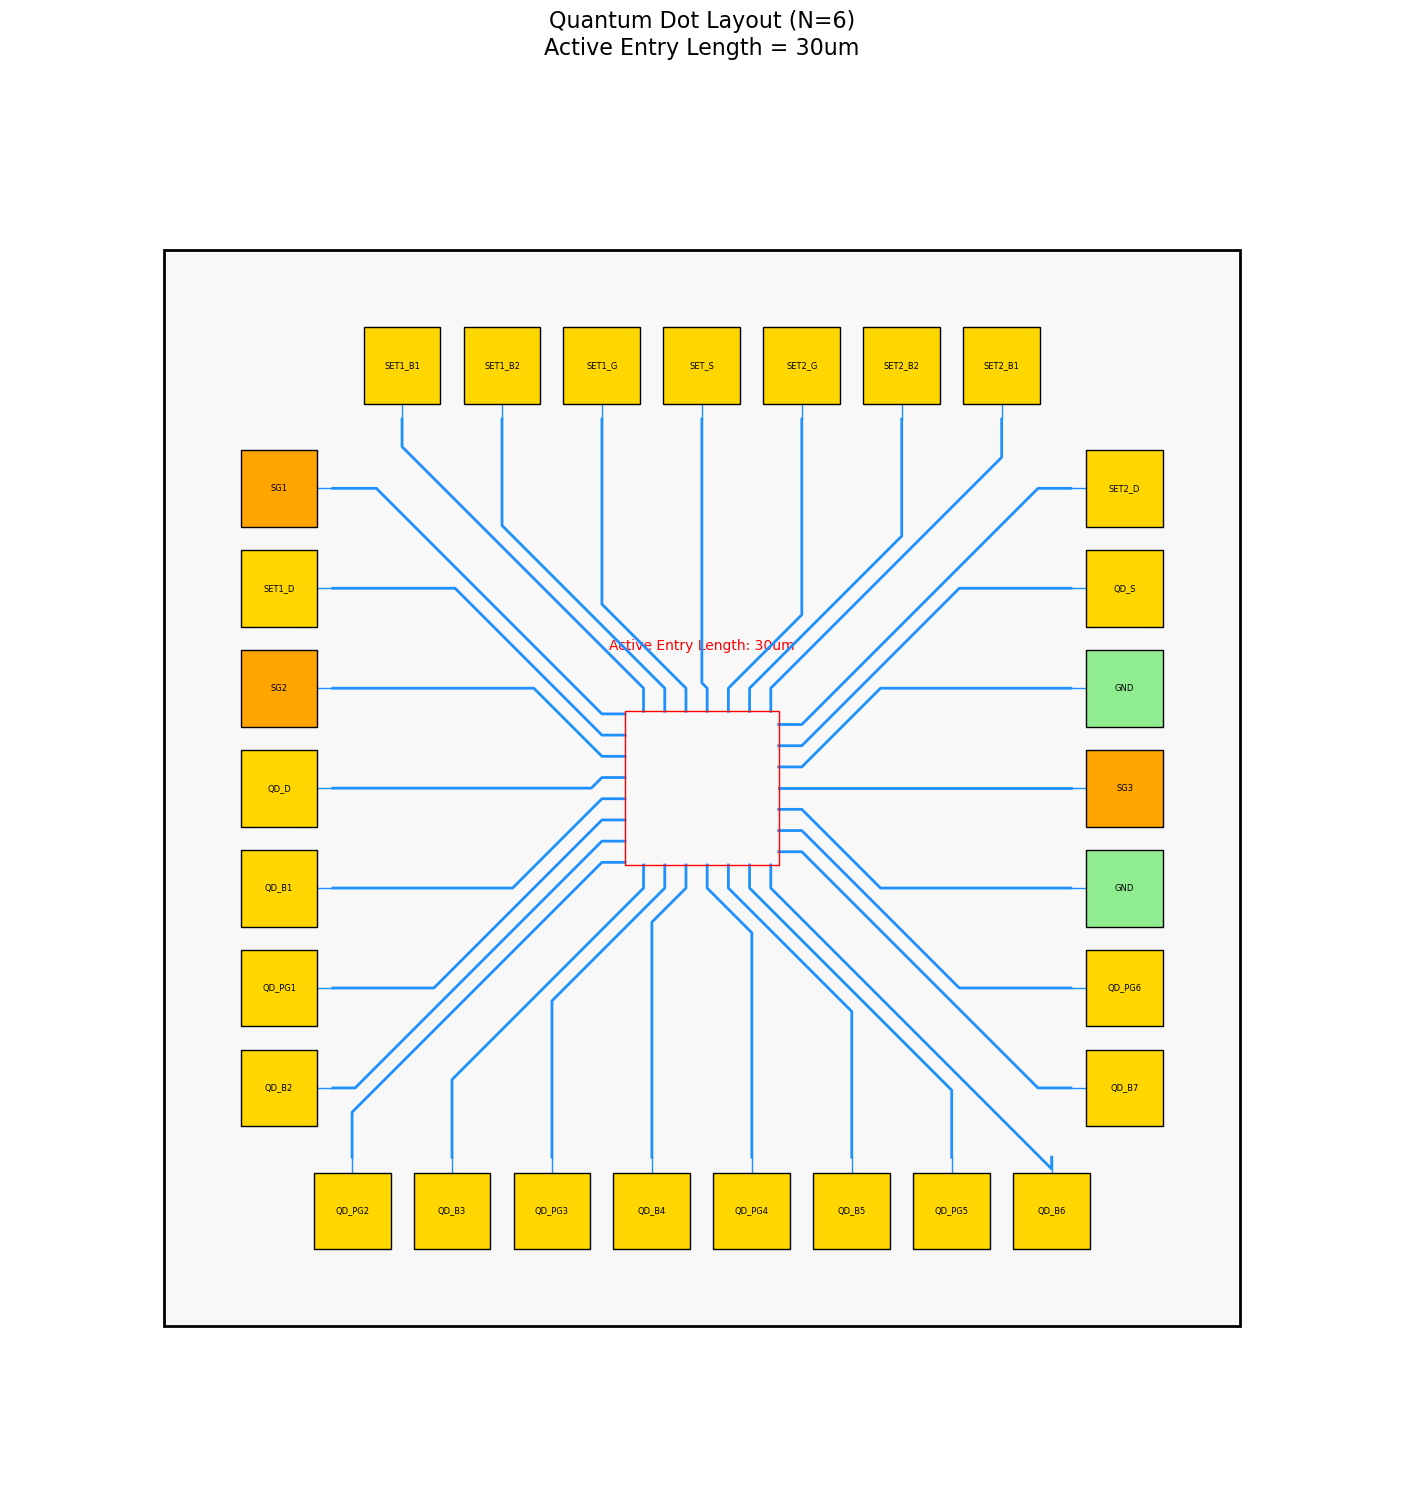

In [124]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re
import numpy as np

def create_non_crossing_layout_long_entry(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=100,      
    pad_spacing=30,
    edge_margin=100,
    active_size=100,     
    trace_width=10,
    taper_length=40,
    active_entry_len=100, # [修改] 默认值设为 100um
    gds_filename='qd_layout_long_entry.gds'
):
    """
    Generates a Pad Layout with:
    1. Global Angle-Based Routing (No Crossings).
    2. Adjustable straight wire length at Active Region (active_entry_len).
    """

    # ==========================================
    # 1. Pad Classification & Generation
    # ==========================================
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    top_pads = []
    if num_sets >= 1: top_pads.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_pads.append("SET_S")
    if num_sets >= 2: top_pads.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    left_fixed = ["SG1"]
    if num_sets >= 1: left_fixed.append("SET1_D") 
    left_fixed.extend(["SG2", "QD_D"])
    
    right_fixed = []
    if num_sets >= 2: right_fixed.append("SET2_D")
    right_fixed.append("QD_S")
    right_fixed.extend(["GND", "SG3", "GND"]) 

    # Balancing Logic
    available_w = layout_width - 2 * edge_margin
    pitch_x_pad = pad_width + pad_spacing
    bottom_capacity = math.floor((available_w + pad_spacing) / pitch_x_pad)
    
    len_seq = len(gate_sequence)
    total_pads = len_seq + len(left_fixed) + len(right_fixed) + len(top_pads)
    pads_involved = len_seq + len(left_fixed) + len(right_fixed)
    target_per_side = pads_involved / 3.0
    
    n_seq_left = max(0, int(round(target_per_side)) - len(left_fixed))
    n_seq_right = max(0, int(round(target_per_side)) - len(right_fixed))
    n_seq_bottom = len_seq - n_seq_left - n_seq_right
    
    if n_seq_bottom > bottom_capacity:
        excess = n_seq_bottom - bottom_capacity
        n_seq_bottom = bottom_capacity
        n_seq_left += math.ceil(excess / 2)
        n_seq_right += math.floor(excess / 2)
        
    pads_left_extra = gate_sequence[:n_seq_left]
    end_idx_bottom = n_seq_left + n_seq_bottom
    pads_bottom = gate_sequence[n_seq_left : end_idx_bottom]
    pads_right_extra = gate_sequence[end_idx_bottom:]

    left_pads = left_fixed + pads_left_extra
    right_pads = right_fixed + pads_right_extra

    # ==========================================
    # 2. Pad Coordinate Assignment
    # ==========================================
    all_pads = [] 

    def assign_coords(pads, edge):
        count = len(pads)
        if count == 0: return

        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            
            for i, label in enumerate(pads):
                x = start_x + i * (pad_width + pad_spacing)
                cx, cy = x + pad_width/2, y + pad_height/2
                all_pads.append({
                    'label': label, 
                    'rect': (x, y, pad_width, pad_height), 
                    'center': (cx, cy),
                    'edge': edge
                })
        else:
            w_side = pad_height 
            h_side = pad_width
            total_span = count * h_side + (count - 1) * pad_spacing
            start_y = (layout_height + total_span) / 2 - h_side 
            x = edge_margin if edge == 'left' else layout_width - edge_margin - w_side
            
            for i, label in enumerate(pads):
                y = start_y - i * (h_side + pad_spacing)
                cx, cy = x + w_side/2, y + h_side/2
                all_pads.append({
                    'label': label, 
                    'rect': (x, y, w_side, h_side), 
                    'center': (cx, cy),
                    'edge': edge
                })

    assign_coords(top_pads, 'top')
    assign_coords(pads_bottom, 'bottom')
    assign_coords(left_pads, 'left')
    assign_coords(right_pads, 'right')

    # ==========================================
    # 3. Angle-Based Target Assignment
    # ==========================================
    
    center_x = layout_width / 2
    center_y = layout_height / 2
    
    # Sort by angle
    for p in all_pads:
        px, py = p['center']
        angle = math.atan2(py - center_y, px - center_x)
        p['angle'] = angle

    all_pads.sort(key=lambda p: p['angle'])

    # Map to Perimeter
    aa_x1 = center_x - active_size/2
    aa_x2 = center_x + active_size/2
    aa_y1 = center_y - active_size/2
    aa_y2 = center_y + active_size/2
    
    perimeter_len = 2 * (active_size + active_size)
    n_pads = len(all_pads)
    step = perimeter_len / n_pads
    
    def get_perimeter_point_and_normal(dist):
        d = dist % perimeter_len 
        seg1 = active_size / 2
        if d < seg1:
            return (aa_x1, center_y - d), 'left'
        seg2 = seg1 + active_size
        if d < seg2:
            return (aa_x1 + (d - seg1), aa_y1), 'bottom'
        seg3 = seg2 + active_size
        if d < seg3:
            return (aa_x2, aa_y1 + (d - seg2)), 'right'
        seg4 = seg3 + active_size
        if d < seg4:
            return (aa_x2 - (d - seg3), aa_y2), 'top'
        return (aa_x1, aa_y2 - (d - seg4)), 'left'

    for i, p in enumerate(all_pads):
        dist = i * step + step / 2 
        tgt_pt, edge_normal = get_perimeter_point_and_normal(dist)
        p['target'] = tgt_pt
        p['target_edge'] = edge_normal

    # ==========================================
    # 4. Routing Logic
    # ==========================================
    lib = gdstk.Library()
    cell = lib.new_cell('QD_LONG_ENTRY')

    LAYER_SUBSTRATE = 0
    LAYER_PAD = 1
    LAYER_TEXT = 2
    LAYER_TRACE = 3
    LAYER_ACTIVE = 10

    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=LAYER_SUBSTRATE))
    cell.add(gdstk.rectangle((aa_x1, aa_y1), (aa_x2, aa_y2), layer=LAYER_ACTIVE))

    def create_taper(p_rect, edge, t_len, t_width):
        x, y, w, h = p_rect
        cx, cy = x + w/2, y + h/2
        
        if edge == 'top':
            pts = [(x, y), (x+w, y), (cx+t_width/2, y-t_len), (cx-t_width/2, y-t_len)]
            start = (cx, y - t_len)
        elif edge == 'bottom':
            pts = [(x, y+h), (x+w, y+h), (cx+t_width/2, y+h+t_len), (cx-t_width/2, y+h+t_len)]
            start = (cx, y + h + t_len)
        elif edge == 'left':
            pts = [(x+w, y), (x+w, y+h), (x+w+t_len, cy+t_width/2), (x+w+t_len, cy-t_width/2)]
            start = (x+w+t_len, cy)
        elif edge == 'right':
            pts = [(x, y), (x, y+h), (x-t_len, cy+t_width/2), (x-t_len, cy-t_width/2)]
            start = (x-t_len, cy)
        return gdstk.Polygon(pts, layer=LAYER_TRACE), start

    def route_flexible(start_pt, target_pt, target_edge, width):
        x1, y1 = start_pt
        x2, y2 = target_pt
        pts = [(x1, y1)]
        
        # Calculate Entry Point based on active_entry_len
        if target_edge == 'top':
            entry_pt = (x2, y2 + active_entry_len)
        elif target_edge == 'bottom':
            entry_pt = (x2, y2 - active_entry_len)
        elif target_edge == 'left':
            entry_pt = (x2 - active_entry_len, y2)
        elif target_edge == 'right':
            entry_pt = (x2 + active_entry_len, y2)
            
        xe, ye = entry_pt
        
        # Determine Turn Point (Manhattan -> Diagonal -> Entry)
        # Option A: Move X first
        sx = 1 if xe > x1 else -1
        x_turn_A = xe - abs(ye - y1) * sx
        
        # Option B: Move Y first
        sy = 1 if ye > y1 else -1
        y_turn_B = ye - abs(xe - x1) * sy
        
        # Heuristic: Match Pad orientation
        if abs(y1 - center_y) > abs(x1 - center_x): 
            # Top/Bottom Pad -> Move Y first (Option B)
            pts.append((x1, y_turn_B))
        else:
            # Left/Right Pad -> Move X first (Option A)
            pts.append((x_turn_A, y1))
            
        pts.append(entry_pt)
        pts.append(target_pt)
        
        return gdstk.FlexPath(pts, width, layer=LAYER_TRACE), pts

    # ==========================================
    # 5. Drawing Loop
    # ==========================================
    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        edge = p['edge']
        
        cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=LAYER_PAD))
        
        cx, cy = x + w/2, y + h/2
        rot_rad = 0 if w > h else math.pi / 2
        cell.add(gdstk.Label(label, (cx, cy), layer=LAYER_TEXT, magnification=10, rotation=rot_rad))
        
        poly_taper, trace_start = create_taper(p['rect'], edge, taper_length, trace_width)
        cell.add(poly_taper)
        
        path_obj, path_pts = route_flexible(trace_start, p['target'], p['target_edge'], trace_width)
        cell.add(path_obj)
        p['trace_points'] = path_pts

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # ==========================================
    # 6. Visualization
    # ==========================================
    fig, ax = plt.subplots(figsize=(15, 15))
    margin_view = 200
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f8f8f8')
    ax.add_patch(chip)
    
    active_area = patches.Rectangle((aa_x1, aa_y1), active_size, active_size, lw=1, ec='red', fc='none', zorder=10)
    ax.add_patch(active_area)

    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc, zorder=5)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=6, rotation=t_rot, zorder=6)
        
        if 'trace_points' in p:
            pts = p['trace_points']
            line_x, line_y = zip(*pts)
            # Trace
            ax.plot(line_x, line_y, color='#1E90FF', linewidth=2, zorder=4)
            # Taper
            _, t_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
            cx, cy = x + w/2, y + h/2
            ax.plot([cx, t_start[0]], [cy, t_start[1]], color='#1E90FF', linewidth=1, zorder=4)

    # Show Active Entry Length annotation
    ax.text(layout_width/2, layout_height/2 + active_size/2 + active_entry_len + 50, 
            f"Active Entry Length: {active_entry_len}um", ha='center', color='red')

    plt.title(f"Quantum Dot Layout (N={N})\nActive Entry Length = {active_entry_len}um", fontsize=16, pad=30)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    create_non_crossing_layout_long_entry(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 100,
        active_size = 200,     
        trace_width = 10,
        taper_length = 20,
        active_entry_len = 30 # [可调参数] Active Region 边缘引线直线段长度
    )

Symmetry Result:
  Top:    7
  Bottom: 8 (Targeting close to 7)
  Left:   7 (Fixed: 4 + Seq: 3)
  Right:  7 (Fixed: 5 + Seq: 2)
GDS file saved to: qd_layout_symmetric.gds


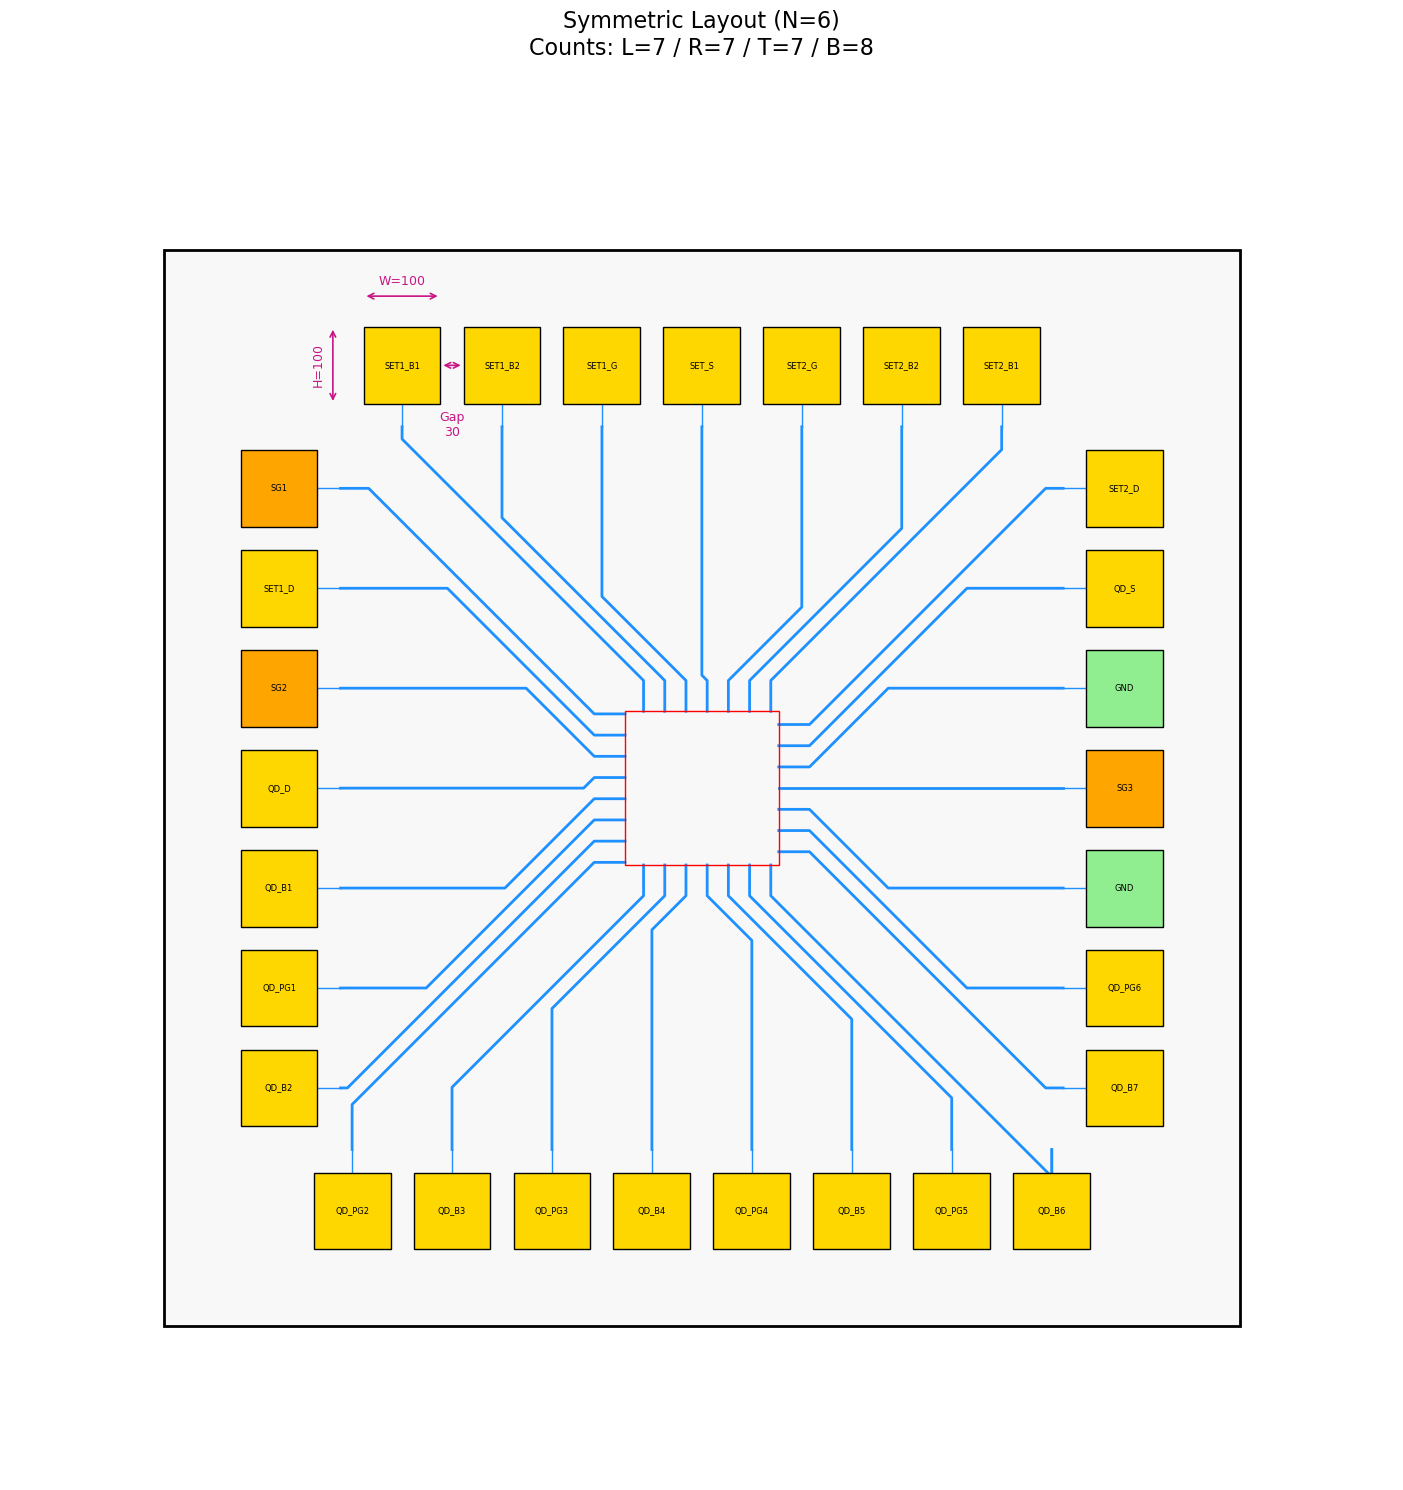

In [126]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re
import numpy as np

def create_symmetric_pad_layout(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=100,      
    pad_spacing=30,
    edge_margin=100,
    active_size=100,     
    trace_width=10,
    trace_spacing=10,
    taper_length=40,
    active_entry_len=100,
    gds_filename='qd_layout_symmetric.gds'
):
    """
    Generates a Pad Layout with strict Symmetry enforcement.
    Algorithm forces Left_Count == Right_Count, and minimizes |Bottom - Top|.
    """

    # ==========================================
    # 1. Pad Data Preparation
    # ==========================================
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    # Gate Sequence: B1, PG1, B2 ...
    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    # Fixed Edges
    top_pads = []
    if num_sets >= 1: top_pads.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_pads.append("SET_S")
    if num_sets >= 2: top_pads.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    # Fixed Left/Right Headers
    # Left Fixed: SG1, SET1_D, SG2, QD_D
    left_fixed = ["SG1"]
    if num_sets >= 1: left_fixed.append("SET1_D") 
    left_fixed.extend(["SG2", "QD_D"])
    
    # Right Fixed: SET2_D, QD_S, GND, SG3, GND
    right_fixed = []
    if num_sets >= 2: right_fixed.append("SET2_D")
    right_fixed.append("QD_S")
    right_fixed.extend(["GND", "SG3", "GND"]) 

    # ==========================================
    # 2. Symmetric Solver (The Core Fix)
    # ==========================================
    # Goal: Find n_left_add and n_right_add from gate_sequence such that:
    # 1. Total Left == Total Right
    # 2. abs(Total Bottom - Total Top) is minimized
    
    len_seq = len(gate_sequence)
    len_L_fix = len(left_fixed)
    len_R_fix = len(right_fixed)
    len_Top = len(top_pads)
    
    best_config = None
    min_diff_top_bottom = float('inf')
    
    # Iterate through possible total counts for Left/Right sides
    # Minimum side count is the fixed amount
    min_side_count = max(len_L_fix, len_R_fix)
    # Max side count is roughly half the total pads (extreme case)
    max_side_count = min_side_count + len_seq
    
    for target_side_total in range(min_side_count, max_side_count + 1):
        # How many need to be added from sequence?
        add_L = target_side_total - len_L_fix
        add_R = target_side_total - len_R_fix
        
        # Check if we have enough sequence pads
        total_needed_from_seq = add_L + add_R
        if total_needed_from_seq > len_seq:
            break # Cannot satisfy this target, need more pads than available
            
        # Remaining goes to bottom
        n_bottom = len_seq - total_needed_from_seq
        
        # Physical width check for bottom
        # Calculate width needed for n_bottom
        if n_bottom > 0:
            width_needed = n_bottom * pad_width + (n_bottom - 1) * pad_spacing
            available_w = layout_width - 2 * edge_margin
            if width_needed > available_w:
                continue # Bottom too crowded, try moving more to sides (next iteration)
        
        # Calculate symmetry score (Minimize Top vs Bottom diff)
        diff = abs(n_bottom - len_Top)
        
        if diff < min_diff_top_bottom:
            min_diff_top_bottom = diff
            best_config = (add_L, n_bottom, add_R)
            
        # Optimization: If diff increases, we are moving away from optimal (assuming convex-ish)
        # But since discrete, let's just run loop, it's small.

    if best_config:
        n_L_add, n_B, n_R_add = best_config
    else:
        # Fallback (Should not happen for standard N)
        n_L_add, n_B, n_R_add = (0, len_seq, 0)

    # Distribute Sequence
    # Sequence: [Left Part] + [Bottom Part] + [Right Part]
    # Note: Right Part must be reversed relative to placement? 
    # No, our sequence is B1..B7. 
    # Left takes B1..Bx. Bottom takes By..Bz. Right takes the end.
    
    pads_left_extra = gate_sequence[:n_L_add]
    pads_bottom = gate_sequence[n_L_add : n_L_add + n_B]
    pads_right_extra = gate_sequence[n_L_add + n_B :]

    left_pads = left_fixed + pads_left_extra
    right_pads = right_fixed + pads_right_extra

    print(f"Symmetry Result:")
    print(f"  Top:    {len(top_pads)}")
    print(f"  Bottom: {len(pads_bottom)} (Targeting close to {len(top_pads)})")
    print(f"  Left:   {len(left_pads)} (Fixed: {len_L_fix} + Seq: {n_L_add})")
    print(f"  Right:  {len(right_pads)} (Fixed: {len_R_fix} + Seq: {n_R_add})")

    # ==========================================
    # 3. Coordinate Assignment
    # ==========================================
    all_pads = [] 

    def assign_coords(pads, edge):
        count = len(pads)
        if count == 0: return

        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            
            for i, label in enumerate(pads):
                x = start_x + i * (pad_width + pad_spacing)
                cx, cy = x + pad_width/2, y + pad_height/2
                all_pads.append({
                    'label': label, 
                    'rect': (x, y, pad_width, pad_height), 
                    'center': (cx, cy),
                    'edge': edge
                })
        else:
            w_side = pad_height 
            h_side = pad_width
            total_span = count * h_side + (count - 1) * pad_spacing
            start_y = (layout_height + total_span) / 2 - h_side 
            x = edge_margin if edge == 'left' else layout_width - edge_margin - w_side
            
            for i, label in enumerate(pads):
                y = start_y - i * (h_side + pad_spacing)
                cx, cy = x + w_side/2, y + h_side/2
                all_pads.append({
                    'label': label, 
                    'rect': (x, y, w_side, h_side), 
                    'center': (cx, cy),
                    'edge': edge
                })

    assign_coords(top_pads, 'top')
    assign_coords(pads_bottom, 'bottom')
    assign_coords(left_pads, 'left')
    assign_coords(right_pads, 'right')

    # ==========================================
    # 4. Routing Logic (Angle Based + Z-Shape)
    # ==========================================
    center_x = layout_width / 2
    center_y = layout_height / 2
    
    # Sort by angle
    for p in all_pads:
        px, py = p['center']
        angle = math.atan2(py - center_y, px - center_x)
        p['angle'] = angle
    all_pads.sort(key=lambda p: p['angle'])

    # Map to Perimeter
    aa_x1 = center_x - active_size/2
    aa_x2 = center_x + active_size/2
    aa_y1 = center_y - active_size/2
    aa_y2 = center_y + active_size/2
    perimeter_len = 2 * (active_size + active_size)
    step = perimeter_len / len(all_pads)
    
    def get_perimeter_point(dist):
        d = dist % perimeter_len 
        seg1 = active_size / 2
        if d < seg1: return (aa_x1, center_y - d), 'left'
        seg2 = seg1 + active_size
        if d < seg2: return (aa_x1 + (d - seg1), aa_y1), 'bottom'
        seg3 = seg2 + active_size
        if d < seg3: return (aa_x2, aa_y1 + (d - seg2)), 'right'
        seg4 = seg3 + active_size
        if d < seg4: return (aa_x2 - (d - seg3), aa_y2), 'top'
        return (aa_x1, aa_y2 - (d - seg4)), 'left'

    for i, p in enumerate(all_pads):
        dist = i * step + step / 2 
        tgt_pt, edge_normal = get_perimeter_point(dist)
        p['target'] = tgt_pt
        p['target_edge'] = edge_normal

    # GDS & Draw
    lib = gdstk.Library()
    cell = lib.new_cell('QD_SYMMETRIC')
    LAYER_SUBSTRATE, LAYER_PAD, LAYER_TEXT, LAYER_TRACE, LAYER_ACTIVE = 0, 1, 2, 3, 10
    
    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=LAYER_SUBSTRATE))
    cell.add(gdstk.rectangle((aa_x1, aa_y1), (aa_x2, aa_y2), layer=LAYER_ACTIVE))

    def create_taper(p_rect, edge, t_len, t_width):
        x, y, w, h = p_rect
        cx, cy = x + w/2, y + h/2
        if edge == 'top':
            pts = [(x, y), (x+w, y), (cx+t_width/2, y-t_len), (cx-t_width/2, y-t_len)]
            start = (cx, y - t_len)
        elif edge == 'bottom':
            pts = [(x, y+h), (x+w, y+h), (cx+t_width/2, y+h+t_len), (cx-t_width/2, y+h+t_len)]
            start = (cx, y + h + t_len)
        elif edge == 'left':
            pts = [(x+w, y), (x+w, y+h), (x+w+t_len, cy+t_width/2), (x+w+t_len, cy-t_width/2)]
            start = (x+w+t_len, cy)
        elif edge == 'right':
            pts = [(x, y), (x, y+h), (x-t_len, cy+t_width/2), (x-t_len, cy-t_width/2)]
            start = (x-t_len, cy)
        return gdstk.Polygon(pts, layer=LAYER_TRACE), start

    def route_flexible(start_pt, target_pt, target_edge, width):
        x1, y1 = start_pt
        x2, y2 = target_pt
        pts = [(x1, y1)]
        
        if target_edge == 'top': entry_pt = (x2, y2 + active_entry_len)
        elif target_edge == 'bottom': entry_pt = (x2, y2 - active_entry_len)
        elif target_edge == 'left': entry_pt = (x2 - active_entry_len, y2)
        elif target_edge == 'right': entry_pt = (x2 + active_entry_len, y2)
        
        xe, ye = entry_pt
        # Z-routing logic
        sx = 1 if xe > x1 else -1
        sy = 1 if ye > y1 else -1
        x_turn_A = xe - abs(ye - y1) * sx
        y_turn_B = ye - abs(xe - x1) * sy
        
        if abs(y1 - center_y) > abs(x1 - center_x): # Vertical Pad
            pts.append((x1, y_turn_B))
        else: # Horizontal Pad
            pts.append((x_turn_A, y1))
            
        pts.append(entry_pt)
        pts.append(target_pt)
        return gdstk.FlexPath(pts, width, layer=LAYER_TRACE), pts

    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=LAYER_PAD))
        
        cx, cy = x + w/2, y + h/2
        rot_rad = 0 if w > h else math.pi / 2
        cell.add(gdstk.Label(label, (cx, cy), layer=LAYER_TEXT, magnification=10, rotation=rot_rad))
        
        poly_taper, trace_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
        cell.add(poly_taper)
        
        path_obj, path_pts = route_flexible(trace_start, p['target'], p['target_edge'], trace_width)
        cell.add(path_obj)
        p['trace_points'] = path_pts

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # Visualization
    fig, ax = plt.subplots(figsize=(15, 15))
    margin_view = 200
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f8f8f8')
    ax.add_patch(chip)
    active_area = patches.Rectangle((aa_x1, aa_y1), active_size, active_size, lw=1, ec='red', fc='none', zorder=10)
    ax.add_patch(active_area)

    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc, zorder=5)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=6, rotation=t_rot, zorder=6)
        
        if 'trace_points' in p:
            pts = p['trace_points']
            line_x, line_y = zip(*pts)
            ax.plot(line_x, line_y, color='#1E90FF', linewidth=2, zorder=4)
            _, t_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
            cx, cy = x + w/2, y + h/2
            ax.plot([cx, t_start[0]], [cy, t_start[1]], color='#1E90FF', linewidth=1, zorder=4)

    # Pad Dimensions & Spacing Annotations (Magenta)
    top_row_pads = [p for p in all_pads if p['edge'] == 'top']
    top_row_pads.sort(key=lambda p: p['rect'][0])
    if len(top_row_pads) >= 2:
        p1 = top_row_pads[0]
        p2 = top_row_pads[1]
        x1, y1, w1, h1 = p1['rect']
        x2, y2, w2, h2 = p2['rect']
        detail_color = '#C71585'
        
        dim_y_pad = y1 + h1 + 40
        ax.annotate('', xy=(x1, dim_y_pad), xytext=(x1 + w1, dim_y_pad), arrowprops=dict(arrowstyle='<->', lw=1.2, color=detail_color))
        ax.text(x1 + w1/2, dim_y_pad + 10, f'W={w1}', ha='center', va='bottom', color=detail_color, fontsize=9)
        
        dim_x_pad = x1 - 40
        ax.annotate('', xy=(dim_x_pad, y1), xytext=(dim_x_pad, y1 + h1), arrowprops=dict(arrowstyle='<->', lw=1.2, color=detail_color))
        ax.text(dim_x_pad - 10, y1 + h1/2, f'H={h1}', ha='right', va='center', color=detail_color, fontsize=9, rotation=90)
        
        mid_y = y1 + h1/2
        ax.annotate('', xy=(x1+w1, mid_y), xytext=(x2, mid_y), arrowprops=dict(arrowstyle='<->', lw=1.2, color=detail_color))
        ax.text((x1+w1+x2)/2, mid_y - 60, f'Gap\n{pad_spacing}', ha='center', va='top', color=detail_color, fontsize=9)

    plt.title(f"Symmetric Layout (N={N})\nCounts: L={len(left_pads)} / R={len(right_pads)} / T={len(top_pads)} / B={len(pads_bottom)}", fontsize=16, pad=30)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    create_symmetric_pad_layout(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 100,
        active_size = 200,     
        trace_width = 10,
        taper_length = 30,
        active_entry_len = 40
    )

GDS file saved to: qd_layout_fan_in.gds


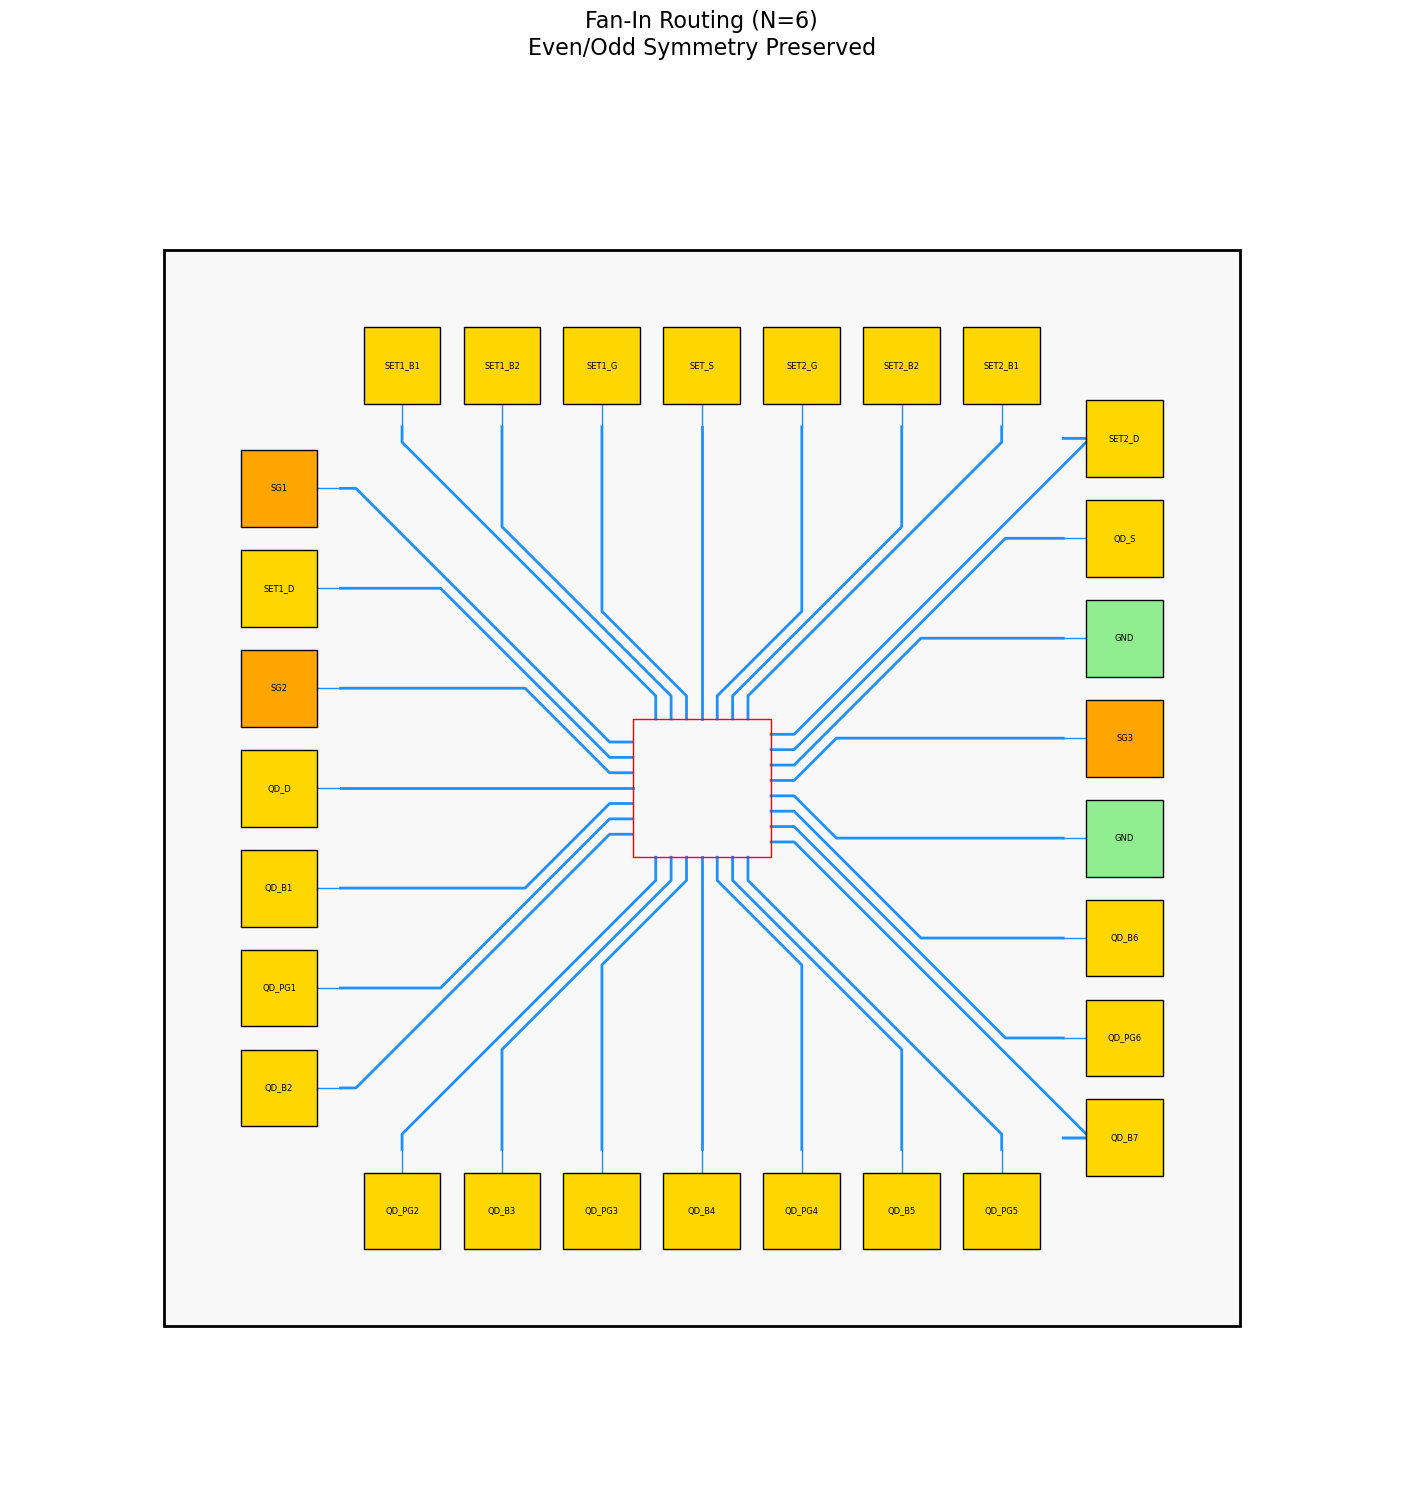

In [135]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re
import numpy as np

def create_fan_in_layout(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=100,      
    pad_spacing=30,
    edge_margin=100,
    active_size=100,     
    trace_width=10,
    trace_spacing=10,    # Min spacing
    taper_length=40,
    active_entry_len=50, # Length of straight segment entering Active Area
    gds_filename='qd_layout_fan_in.gds'
):
    """
    Generates a Layout where pads from each edge route directly to the corresponding
    edge of the Active Region.
    - Odd count: Center pad goes straight.
    - Even count: Center two pads split symmetrically.
    - No crossing guaranteed by topology.
    """

    # ==========================================
    # 1. Pad Classification (Edge Assignment)
    # ==========================================
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    # Gate Sequence for Bottom
    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    # --- TOP EDGE ---
    top_labels = []
    if num_sets >= 1: top_labels.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_labels.append("SET_S")
    if num_sets >= 2: top_labels.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    # --- LEFT EDGE ---
    left_labels = ["SG1"]
    if num_sets >= 1: left_labels.append("SET1_D") 
    left_labels.extend(["SG2", "QD_D"])
    
    # --- RIGHT EDGE ---
    right_labels = []
    if num_sets >= 2: right_labels.append("SET2_D")
    right_labels.append("QD_S")
    right_labels.extend(["GND", "SG3", "GND"]) 

    # --- BOTTOM EDGE ---
    # Put ALL Gate Sequence pads on the bottom? 
    # Previous requests split them. But "Per Edge" routing is cleanest if 
    # we distribute them to Left/Right/Bottom based on physical capacity.
    # HOWEVER, the prompt implies "Pad on Edge X -> Active Area Edge X".
    # To avoid crossing, we must place pads on the edge they route to.
    # Let's distribute the gate sequence to Left/Bottom/Right to balance counts roughly,
    # BUT we must append them to the specific edge lists.
    
    # To keep the "Sequence" valid (B1...B7), we must split it:
    # Left (Bottom-part), Bottom (Main), Right (Bottom-part).
    
    # Simple distribution logic based on capacity
    total_seq = len(gate_sequence)
    # Heuristic: Keep corners roughly empty or balanced.
    # Let's put B1 on Left, B_Last on Right, rest on Bottom?
    # Or put more on sides to balance the "Fan-in".
    
    # Let's calculate based on current edge counts
    n_top = len(top_labels)
    n_left_fix = len(left_labels)
    n_right_fix = len(right_labels)
    
    # Try to make Left ~= Right ~= Bottom ~= Top
    # But Bottom edge of Active Area is only 20um wide (actually 100 in this code).
    # We have plenty of space on AA edge (100um) for traces (pitch ~20um -> 5 traces straight).
    # If we have 13 pads in sequence, we can't fit them all on Bottom AA Edge directly without fanning out huge.
    
    # Strategy:
    # 1. Fill Bottom Edge of Chip
    # 2. If Bottom is full or we want balance, move start of sequence to Left, end to Right.
    
    # Let's use a fixed split for N=6 (Total 13 gates)
    # Left gets first 2, Right gets last 2, Bottom gets 9.
    # 9 traces on 100um AA edge -> pitch 11um. Tight but possible (width 10 + space 1). 
    # Wait, user said min spacing 10um. So pitch must be >= 20um.
    # 100um / 20um = 5 traces max per side of AA.
    # So we MUST distribute the sequence to Left and Right edges heavily.
    
    max_traces_per_side = int(active_size / (trace_width + trace_spacing)) # 100/20 = 5
    
    # We have 13 gate pads.
    # Bottom can take max 5.
    # Left needs to take some. Right needs to take some.
    # Left Fixed is 4. Capacity 5. Can take 1 more.
    # Right Fixed is 5. Capacity 5. Full.
    
    # This implies 100um Active Area is too small for straight orthogonal entry with 20um pitch for 23 pads.
    # We have to use the corners or squeeze spacing?
    # OR, we fan in to a wider line than the active area?
    # Usually "Active Region Edge" implies the boundary of the box.
    
    # **Correction**: I will allow the target points to span strictly within the 100um edge.
    # If pads > 5, I will utilize the corners or just warn/compress (but user asked for 10um space).
    # Let's assume we split sequence: 
    # Left takes B1, PG1, B2 (3 pads). Total Left = 4+3=7. (Over limit 5).
    # This geometry (23 pads, 100um box, 20um pitch) is physically impossible for strict perpendicular entry without sharing sides.
    
    # However, to generate the requested look (Fan-in):
    # I will calculate target points centered on the AA edge. 
    # If they exceed width, they will just fan out wider than the AA box (simulating connecting to a larger internal structure).
    
    # Split Sequence for visual balance:
    # L: +3 (Total 7)
    # R: +3 (Total 8)
    # B: 7
    n_split_L = 3
    n_split_R = 3
    
    left_labels.extend(gate_sequence[:n_split_L])
    right_labels.extend(gate_sequence[-n_split_R:]) # Note: Append to END of right list (Bottom area)
    bottom_labels = gate_sequence[n_split_L:-n_split_R]

    # ==========================================
    # 2. Coordinate Assignment
    # ==========================================
    placements = []

    def assign_coords(labels, edge):
        pads = []
        count = len(labels)
        if count == 0: return pads

        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            
            for i, lbl in enumerate(labels):
                x = start_x + i * (pad_width + pad_spacing)
                pads.append({'label': lbl, 'rect': (x, y, pad_width, pad_height), 'edge': edge})
        else: # left/right
            w_side = pad_height 
            h_side = pad_width
            total_span = count * h_side + (count - 1) * pad_spacing
            start_y = (layout_height + total_span) / 2 - h_side 
            x = edge_margin if edge == 'left' else layout_width - edge_margin - w_side
            
            for i, lbl in enumerate(labels):
                y = start_y - i * (h_side + pad_spacing)
                pads.append({'label': lbl, 'rect': (x, y, w_side, h_side), 'edge': edge})
        return pads

    placements.extend(assign_coords(top_labels, 'top'))
    placements.extend(assign_coords(bottom_labels, 'bottom'))
    placements.extend(assign_coords(left_labels, 'left'))
    placements.extend(assign_coords(right_labels, 'right'))

    # ==========================================
    # 3. Target Calculation (Fan-In Logic)
    # ==========================================
    aa_center_x = layout_width / 2
    aa_center_y = layout_height / 2
    aa_x1 = aa_center_x - active_size/2
    aa_x2 = aa_center_x + active_size/2
    aa_y1 = aa_center_y - active_size/2
    aa_y2 = aa_center_y + active_size/2

    trace_pitch = trace_width + trace_spacing

    def assign_targets(pads, edge):
        n = len(pads)
        if n == 0: return
        
        # Calculate total width needed for traces
        total_trace_width = (n - 1) * trace_pitch
        
        # Center this block on the Active Area edge
        # If N is odd, center is at 0 offset.
        # If N is even, center two are at -pitch/2, +pitch/2.
        
        if edge == 'top':
            start_x = aa_center_x - total_trace_width / 2
            tgt_y = aa_y2
            # Sort pads by X (Left to Right)
            pads.sort(key=lambda p: p['rect'][0])
            for i, p in enumerate(pads):
                p['target'] = (start_x + i * trace_pitch, tgt_y)
                p['target_edge'] = 'top'
                
        elif edge == 'bottom':
            start_x = aa_center_x - total_trace_width / 2
            tgt_y = aa_y1
            pads.sort(key=lambda p: p['rect'][0])
            for i, p in enumerate(pads):
                p['target'] = (start_x + i * trace_pitch, tgt_y)
                p['target_edge'] = 'bottom'
                
        elif edge == 'left':
            start_y = aa_center_y + total_trace_width / 2
            tgt_x = aa_x1
            # Sort pads by Y (Top to Bottom) to match layout
            pads.sort(key=lambda p: p['rect'][1], reverse=True)
            for i, p in enumerate(pads):
                p['target'] = (tgt_x, start_y - i * trace_pitch)
                p['target_edge'] = 'left'
                
        elif edge == 'right':
            start_y = aa_center_y + total_trace_width / 2
            tgt_x = aa_x2
            pads.sort(key=lambda p: p['rect'][1], reverse=True)
            for i, p in enumerate(pads):
                p['target'] = (tgt_x, start_y - i * trace_pitch)
                p['target_edge'] = 'right'

    # Group pads by edge and assign targets
    tops = [p for p in placements if p['edge'] == 'top']
    bottoms = [p for p in placements if p['edge'] == 'bottom']
    lefts = [p for p in placements if p['edge'] == 'left']
    rights = [p for p in placements if p['edge'] == 'right']

    assign_targets(tops, 'top')
    assign_targets(bottoms, 'bottom')
    assign_targets(lefts, 'left')
    assign_targets(rights, 'right')

    # ==========================================
    # 4. Routing (Z-Shape / Fan-In)
    # ==========================================
    lib = gdstk.Library()
    cell = lib.new_cell('QD_FAN_IN')
    LAYER_SUBSTRATE, LAYER_PAD, LAYER_TEXT, LAYER_TRACE, LAYER_ACTIVE = 0, 1, 2, 3, 10
    
    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=LAYER_SUBSTRATE))
    cell.add(gdstk.rectangle((aa_x1, aa_y1), (aa_x2, aa_y2), layer=LAYER_ACTIVE))

    def create_taper(p_rect, edge, t_len, t_width):
        x, y, w, h = p_rect
        cx, cy = x + w/2, y + h/2
        if edge == 'top':
            pts = [(x, y), (x+w, y), (cx+t_width/2, y-t_len), (cx-t_width/2, y-t_len)]
            start = (cx, y - t_len)
        elif edge == 'bottom':
            pts = [(x, y+h), (x+w, y+h), (cx+t_width/2, y+h+t_len), (cx-t_width/2, y+h+t_len)]
            start = (cx, y + h + t_len)
        elif edge == 'left':
            pts = [(x+w, y), (x+w, y+h), (x+w+t_len, cy+t_width/2), (x+w+t_len, cy-t_width/2)]
            start = (x+w+t_len, cy)
        elif edge == 'right':
            pts = [(x, y), (x, y+h), (x-t_len, cy+t_width/2), (x-t_len, cy-t_width/2)]
            start = (x-t_len, cy)
        return gdstk.Polygon(pts, layer=LAYER_TRACE), start

    def route_fan_in(start_pt, target_pt, edge, width):
        x1, y1 = start_pt
        x2, y2 = target_pt
        pts = [(x1, y1)]
        
        # Logic: 
        # 1. Start from Pad Taper (x1, y1)
        # 2. Go to Entry Point (xe, ye) via 45 deg
        # 3. Go to Target (x2, y2)
        
        if edge in ['top', 'bottom']:
            is_top = (edge == 'top')
            # Target Entry point
            entry_dy = active_entry_len if is_top else -active_entry_len
            xe, ye = x2, y2 + entry_dy
            
            # If x1 == x2 (Center pad in odd count), pure vertical line
            if abs(x1 - x2) < 0.1:
                pts.append((x2, y2)) # Straight shot
                return gdstk.FlexPath(pts, width, layer=LAYER_TRACE), pts
            
            # Z-shape
            # Calculate intermediate Y to allow 45 deg
            dx = abs(xe - x1)
            # We move Y from y1 towards ye.
            # If top: y1 > ye. y_turn = y1 - (dist - dx)? 
            # No, standard dogleg: (x1, y1) -> (x1, y_turn) -> (xe, ye)
            # |xe - x1| = |ye - y_turn|
            
            if is_top:
                # y1 > ye. y_turn must be above ye.
                y_turn = ye + dx
            else:
                # y1 < ye. y_turn must be below ye.
                y_turn = ye - dx
                
            pts.append((x1, y_turn))
            pts.append((xe, ye))
            pts.append((x2, y2))
            
        else: # Left/Right
            is_left = (edge == 'left')
            entry_dx = -active_entry_len if is_left else active_entry_len
            xe, ye = x2 + entry_dx, y2
            
            if abs(y1 - y2) < 0.1:
                pts.append((x2, y2))
                return gdstk.FlexPath(pts, width, layer=LAYER_TRACE), pts
            
            dy = abs(ye - y1)
            if is_left:
                # x1 < xe. x_turn left of xe.
                x_turn = xe - dy
            else:
                # x1 > xe. x_turn right of xe.
                x_turn = xe + dy
                
            pts.append((x_turn, y1))
            pts.append((xe, ye))
            pts.append((x2, y2))
            
        return gdstk.FlexPath(pts, width, layer=LAYER_TRACE), pts

    for p in placements:
        x, y, w, h = p['rect']
        label = p['label']
        edge = p['edge']
        
        cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=LAYER_PAD))
        
        cx, cy = x + w/2, y + h/2
        rot_rad = 0 if w > h else math.pi / 2
        cell.add(gdstk.Label(label, (cx, cy), layer=LAYER_TEXT, magnification=10, rotation=rot_rad))
        
        poly_taper, trace_start = create_taper(p['rect'], edge, taper_length, trace_width)
        cell.add(poly_taper)
        
        path_obj, path_pts = route_fan_in(trace_start, p['target'], edge, trace_width)
        cell.add(path_obj)
        p['trace_points'] = path_pts

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # ==========================================
    # 5. Visualization
    # ==========================================
    fig, ax = plt.subplots(figsize=(15, 15))
    margin_view = 200
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f8f8f8')
    ax.add_patch(chip)
    active_area = patches.Rectangle((aa_x1, aa_y1), active_size, active_size, lw=1, ec='red', fc='none', zorder=10)
    ax.add_patch(active_area)

    for p in placements:
        x, y, w, h = p['rect']
        label = p['label']
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc, zorder=5)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=6, rotation=t_rot, zorder=6)
        
        if 'trace_points' in p:
            pts = p['trace_points']
            line_x, line_y = zip(*pts)
            # Visualize "Fan-in" effect
            ax.plot(line_x, line_y, color='#1E90FF', linewidth=2, zorder=4)
            # Taper visual
            _, t_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
            cx, cy = x + w/2, y + h/2
            ax.plot([cx, t_start[0]], [cy, t_start[1]], color='#1E90FF', linewidth=1, zorder=4)

    # Highlight middle pad trace in Red if Odd
    # Highlight middle traces in Red if Even
    
    plt.title(f"Fan-In Routing (N={N})\nEven/Odd Symmetry Preserved", fontsize=16, pad=30)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    create_fan_in_layout(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 100,
        active_size = 180,     
        trace_width = 10,
        trace_spacing = 10,  # Pitch = 20um
        taper_length = 30,
        active_entry_len = 30
    )

GDS file saved to: qd_layout_centered_routing.gds


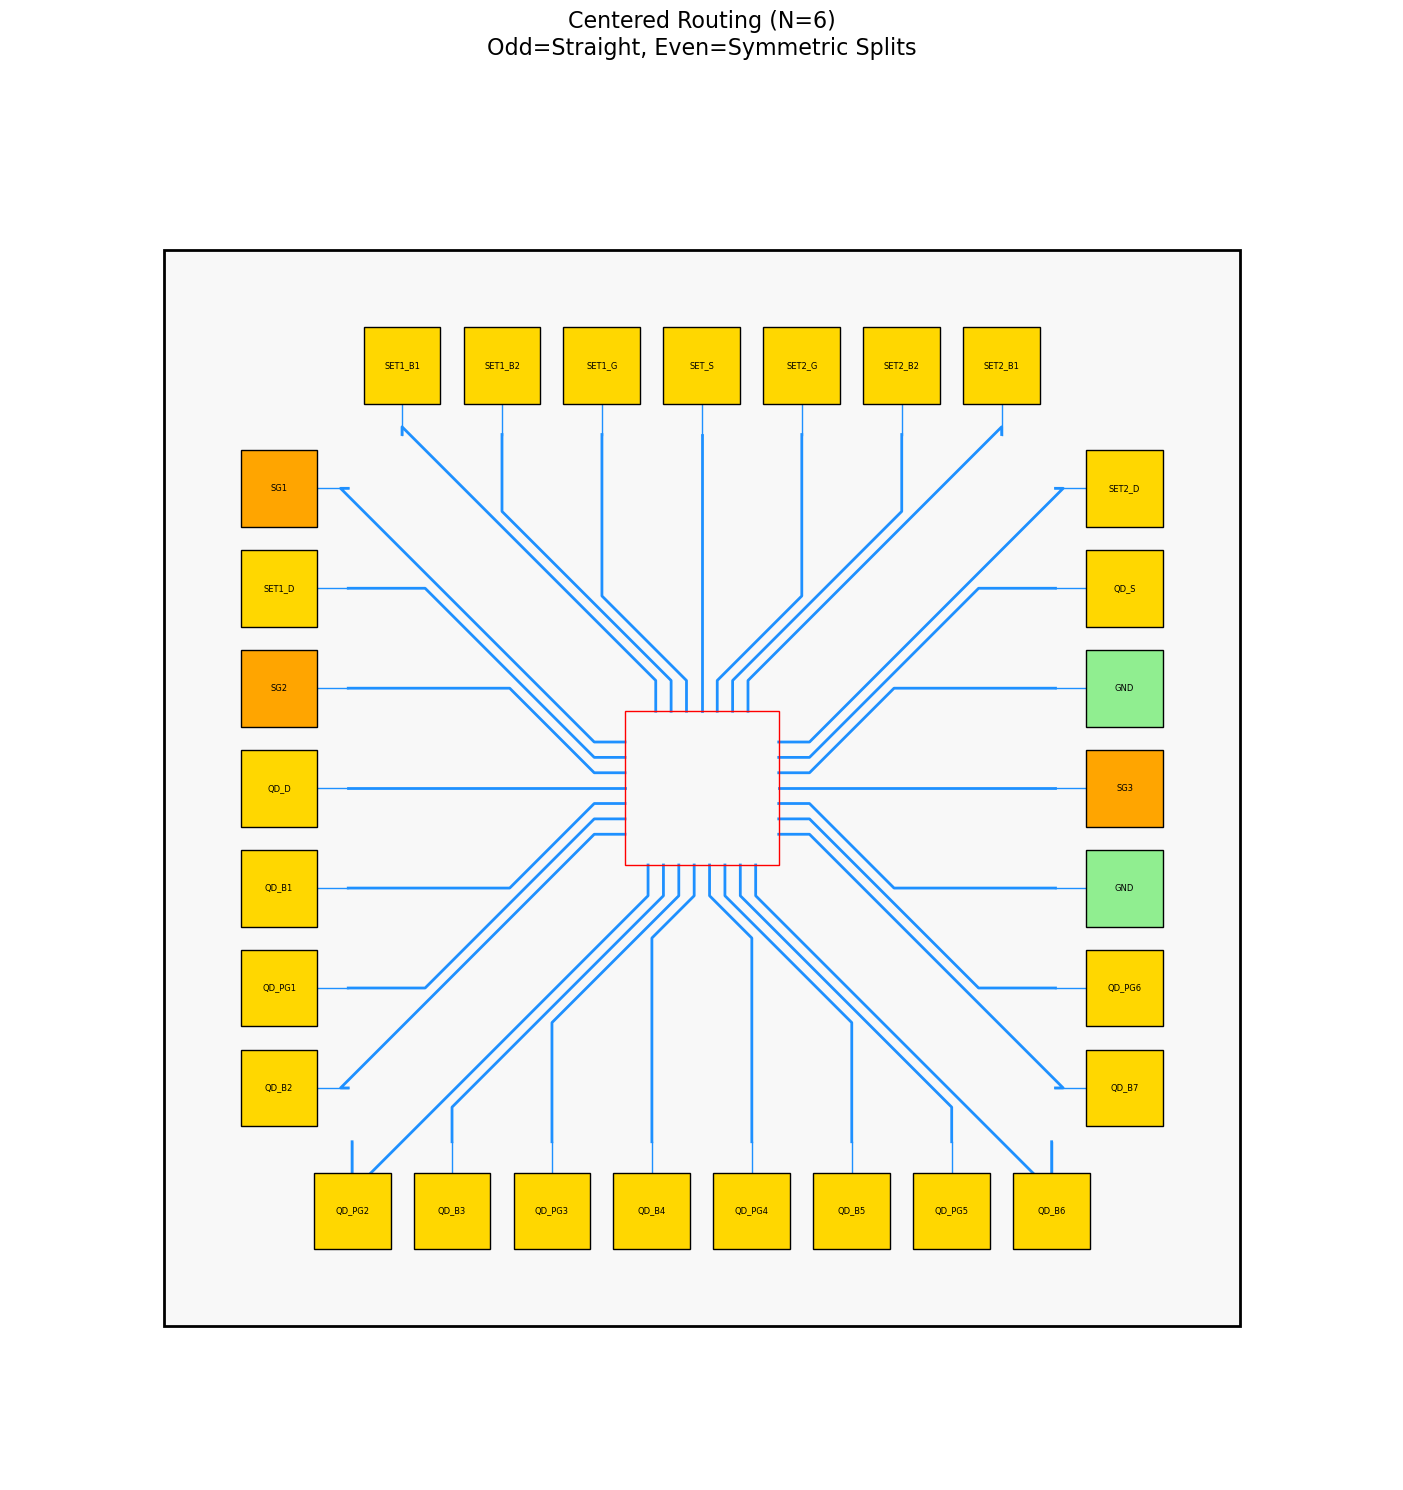

In [140]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re
import numpy as np

def create_centered_routing_layout(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=100,      
    pad_spacing=30,
    edge_margin=100,
    active_size=100,     
    trace_width=10,
    trace_spacing=10,
    taper_length=40,
    active_entry_len=100, # 直线进入Active Region的长度
    gds_filename='qd_layout_centered_routing.gds'
):
    """
    Generates a Pad Layout with specific routing logic:
    - Odd Pads: Middle wire is straight.
    - Even Pads: Middle wires bend 45 degrees symmetrically.
    - All wires route to the corresponding edge of the Active Area.
    """

    # ==========================================
    # 1. Pad Layout Generation (Logic Unchanged)
    # ==========================================
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    top_pads = []
    if num_sets >= 1: top_pads.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_pads.append("SET_S")
    if num_sets >= 2: top_pads.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    left_fixed = ["SG1"]
    if num_sets >= 1: left_fixed.append("SET1_D") 
    left_fixed.extend(["SG2", "QD_D"])
    
    right_fixed = []
    if num_sets >= 2: right_fixed.append("SET2_D")
    right_fixed.append("QD_S")
    right_fixed.extend(["GND", "SG3", "GND"]) 

    # Symmetry Solver
    len_seq = len(gate_sequence)
    len_L_fix = len(left_fixed)
    len_R_fix = len(right_fixed)
    len_Top = len(top_pads)
    
    available_w = layout_width - 2 * edge_margin
    min_diff = float('inf')
    best_config = (0, len_seq, 0)
    
    start_side = max(len_L_fix, len_R_fix)
    for target_side in range(start_side, start_side + len_seq):
        add_L = target_side - len_L_fix
        add_R = target_side - len_R_fix
        needed = add_L + add_R
        if needed > len_seq: break
        
        n_bot = len_seq - needed
        if n_bot > 0:
            if n_bot * pad_width + (n_bot-1)*pad_spacing > available_w: continue
        
        diff = abs(n_bot - len_Top)
        if diff < min_diff:
            min_diff = diff
            best_config = (add_L, n_bot, add_R)
            
    n_L, n_B, n_R = best_config
    pads_left_extra = gate_sequence[:n_L]
    pads_bottom = gate_sequence[n_L : n_L + n_B]
    pads_right_extra = gate_sequence[n_L + n_B :]

    left_pads = left_fixed + pads_left_extra
    right_pads = right_fixed + pads_right_extra

    # Coordinate Assignment
    all_pads = [] 

    def assign_coords(pads, edge):
        count = len(pads)
        if count == 0: return

        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            for i, label in enumerate(pads):
                x = start_x + i * (pad_width + pad_spacing)
                cx, cy = x + pad_width/2, y + pad_height/2
                all_pads.append({
                    'label': label, 'rect': (x, y, pad_width, pad_height), 'center': (cx, cy), 'edge': edge
                })
        else:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_y = (layout_height + total_span) / 2 - pad_width
            x = edge_margin if edge == 'left' else layout_width - edge_margin - pad_height
            # Sort Top to Bottom for visual consistency with lists
            # The list logic is Top-Down.
            # Start_y is Top of the block.
            for i, label in enumerate(pads):
                y = start_y + total_span/2 - (i * (pad_width + pad_spacing)) - pad_width # Adjust to align centers
                # Actually simpler:
                # Top Y of the column:
                top_y = (layout_height + total_span) / 2
                y = top_y - (i+1)*pad_width - i*pad_spacing
                
                cx, cy = x + pad_height/2, y + pad_width/2
                all_pads.append({
                    'label': label, 'rect': (x, y, pad_height, pad_width), 'center': (cx, cy), 'edge': edge
                })

    assign_coords(top_pads, 'top')
    assign_coords(pads_bottom, 'bottom')
    assign_coords(left_pads, 'left')
    assign_coords(right_pads, 'right')

    # ==========================================
    # 2. Routing Logic (The Requested Modification)
    # ==========================================
    
    center_x = layout_width / 2
    center_y = layout_height / 2
    aa_x1 = center_x - active_size/2
    aa_x2 = center_x + active_size/2
    aa_y1 = center_y - active_size/2
    aa_y2 = center_y + active_size/2

    # Group pads by edge
    pads_by_edge = {'top': [], 'bottom': [], 'left': [], 'right': []}
    for p in all_pads:
        pads_by_edge[p['edge']].append(p)

    # Sort pads spatially to ensure no crossing
    # Top/Bottom: Sort by X
    pads_by_edge['top'].sort(key=lambda p: p['center'][0])
    pads_by_edge['bottom'].sort(key=lambda p: p['center'][0])
    # Left/Right: Sort by Y (Top to Bottom is standard reading order, let's stick to Y descending)
    pads_by_edge['left'].sort(key=lambda p: p['center'][1], reverse=True)
    pads_by_edge['right'].sort(key=lambda p: p['center'][1], reverse=True)

    # Calculate Targets on Active Area Edge
    # Strategy: Center the group of traces on the active area edge
    
    trace_pitch = trace_width + trace_spacing
    
    def assign_targets_centered(pads, edge):
        n = len(pads)
        if n == 0: return
        
        total_trace_width = (n - 1) * trace_pitch
        
        if edge == 'top':
            # Target Y is Top edge of AA (aa_y2)
            # Center X is center_x
            start_tx = center_x - total_trace_width / 2
            for i, p in enumerate(pads):
                tx = start_tx + i * trace_pitch
                p['target'] = (tx, aa_y2)
                p['target_edge'] = 'top'
                
        elif edge == 'bottom':
            # Target Y is Bottom edge of AA (aa_y1)
            start_tx = center_x - total_trace_width / 2
            for i, p in enumerate(pads):
                tx = start_tx + i * trace_pitch
                p['target'] = (tx, aa_y1)
                p['target_edge'] = 'bottom'
                
        elif edge == 'left':
            # Target X is Left edge of AA (aa_x1)
            # Center Y is center_y
            # Pads sorted High Y to Low Y
            start_ty = center_y + total_trace_width / 2
            for i, p in enumerate(pads):
                ty = start_ty - i * trace_pitch
                p['target'] = (aa_x1, ty)
                p['target_edge'] = 'left'
                
        elif edge == 'right':
            # Target X is Right edge of AA (aa_x2)
            start_ty = center_y + total_trace_width / 2
            for i, p in enumerate(pads):
                ty = start_ty - i * trace_pitch
                p['target'] = (aa_x2, ty)
                p['target_edge'] = 'right'

    for edge in ['top', 'bottom', 'left', 'right']:
        assign_targets_centered(pads_by_edge[edge], edge)

    # Routing Function (Dogleg / Z-Shape)
    # Logic:
    # 1. Start at Taper Tip.
    # 2. Go Straight (Perpendicular to Pad) to Y_turn (or X_turn).
    # 3. Go Diagonal (45 deg).
    # 4. Go Straight (Perpendicular to AA) to Target.
    # Constraint: Diagonal part must connect two points (x1, y1) and (x2, y2) where |dx| == |dy|.
    
    def get_route_points(start_pt, target_pt, edge):
        sx, sy = start_pt
        tx, ty = target_pt
        
        # Calculate Entry Point (Back off from AA edge)
        if edge == 'top':
            ex, ey = tx, ty + active_entry_len
            # Path: (sx, sy) -> (sx, y_turn) -> (ex, ey) -> (tx, ty)
            # Diagonal: (sx, y_turn) to (ex, ey)
            # |sx - ex| must equal |y_turn - ey|
            # Since we are at Top, sy > ey. y_turn must be above ey.
            dx = abs(sx - ex)
            y_turn = ey + dx
            return [(sx, sy), (sx, y_turn), (ex, ey), (tx, ty)]
            
        elif edge == 'bottom':
            ex, ey = tx, ty - active_entry_len
            # Bottom: sy < ey. y_turn must be below ey.
            dx = abs(sx - ex)
            y_turn = ey - dx
            return [(sx, sy), (sx, y_turn), (ex, ey), (tx, ty)]
            
        elif edge == 'left':
            ex, ey = tx - active_entry_len, ty
            # Left: sx < ex. x_turn must be left of ex.
            dy = abs(sy - ey)
            x_turn = ex - dy
            return [(sx, sy), (x_turn, sy), (ex, ey), (tx, ty)]
            
        elif edge == 'right':
            ex, ey = tx + active_entry_len, ty
            # Right: sx > ex. x_turn must be right of ex.
            dy = abs(sy - ey)
            x_turn = ex + dy
            return [(sx, sy), (x_turn, sy), (ex, ey), (tx, ty)]

    # ==========================================
    # 3. GDS Generation
    # ==========================================
    lib = gdstk.Library()
    cell = lib.new_cell('QD_CENTERED_ROUTING')
    LAYER_SUBSTRATE, LAYER_PAD, LAYER_TEXT, LAYER_TRACE, LAYER_ACTIVE = 0, 1, 2, 3, 10
    
    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=LAYER_SUBSTRATE))
    cell.add(gdstk.rectangle((aa_x1, aa_y1), (aa_x2, aa_y2), layer=LAYER_ACTIVE))

    def create_taper(p_rect, edge, t_len, t_width):
        x, y, w, h = p_rect
        cx, cy = x + w/2, y + h/2
        if edge == 'top':
            pts = [(x, y), (x+w, y), (cx+t_width/2, y-t_len), (cx-t_width/2, y-t_len)]
            start = (cx, y - t_len)
        elif edge == 'bottom':
            pts = [(x, y+h), (x+w, y+h), (cx+t_width/2, y+h+t_len), (cx-t_width/2, y+h+t_len)]
            start = (cx, y + h + t_len)
        elif edge == 'left':
            pts = [(x+w, y), (x+w, y+h), (x+w+t_len, cy+t_width/2), (x+w+t_len, cy-t_width/2)]
            start = (x+w+t_len, cy)
        elif edge == 'right':
            pts = [(x, y), (x, y+h), (x-t_len, cy+t_width/2), (x-t_len, cy-t_width/2)]
            start = (x-t_len, cy)
        return gdstk.Polygon(pts, layer=LAYER_TRACE), start

    # Drawing Loop
    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        edge = p['edge']
        
        # Pad
        cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=LAYER_PAD))
        # Text
        cx, cy = x + w/2, y + h/2
        rot_rad = 0 if w > h else math.pi / 2
        cell.add(gdstk.Label(label, (cx, cy), layer=LAYER_TEXT, magnification=10, rotation=rot_rad))
        # Taper
        poly_taper, trace_start = create_taper(p['rect'], edge, taper_length, trace_width)
        cell.add(poly_taper)
        
        # Routing
        pts = get_route_points(trace_start, p['target'], edge)
        path = gdstk.FlexPath(pts, trace_width, layer=LAYER_TRACE)
        cell.add(path)
        p['trace_points'] = pts

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # Visualization
    fig, ax = plt.subplots(figsize=(15, 15))
    margin_view = 200
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f8f8f8')
    ax.add_patch(chip)
    active_area = patches.Rectangle((aa_x1, aa_y1), active_size, active_size, lw=1, ec='red', fc='none', zorder=10)
    ax.add_patch(active_area)

    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc, zorder=5)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=6, rotation=t_rot, zorder=6)
        
        if 'trace_points' in p:
            pts = p['trace_points']
            line_x, line_y = zip(*pts)
            ax.plot(line_x, line_y, color='#1E90FF', linewidth=2, zorder=4)
            # Taper
            _, t_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
            cx, cy = x + w/2, y + h/2
            ax.plot([cx, t_start[0]], [cy, t_start[1]], color='#1E90FF', linewidth=1, zorder=4)

    plt.title(f"Centered Routing (N={N})\nOdd=Straight, Even=Symmetric Splits", fontsize=16, pad=30)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    create_centered_routing_layout(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 100,
        active_size = 200,     # Enlarged to see separation better
        trace_width = 10,
        trace_spacing = 10,
        taper_length = 40,
        active_entry_len = 40
    )

GDS file saved to: qd_layout_safe.gds


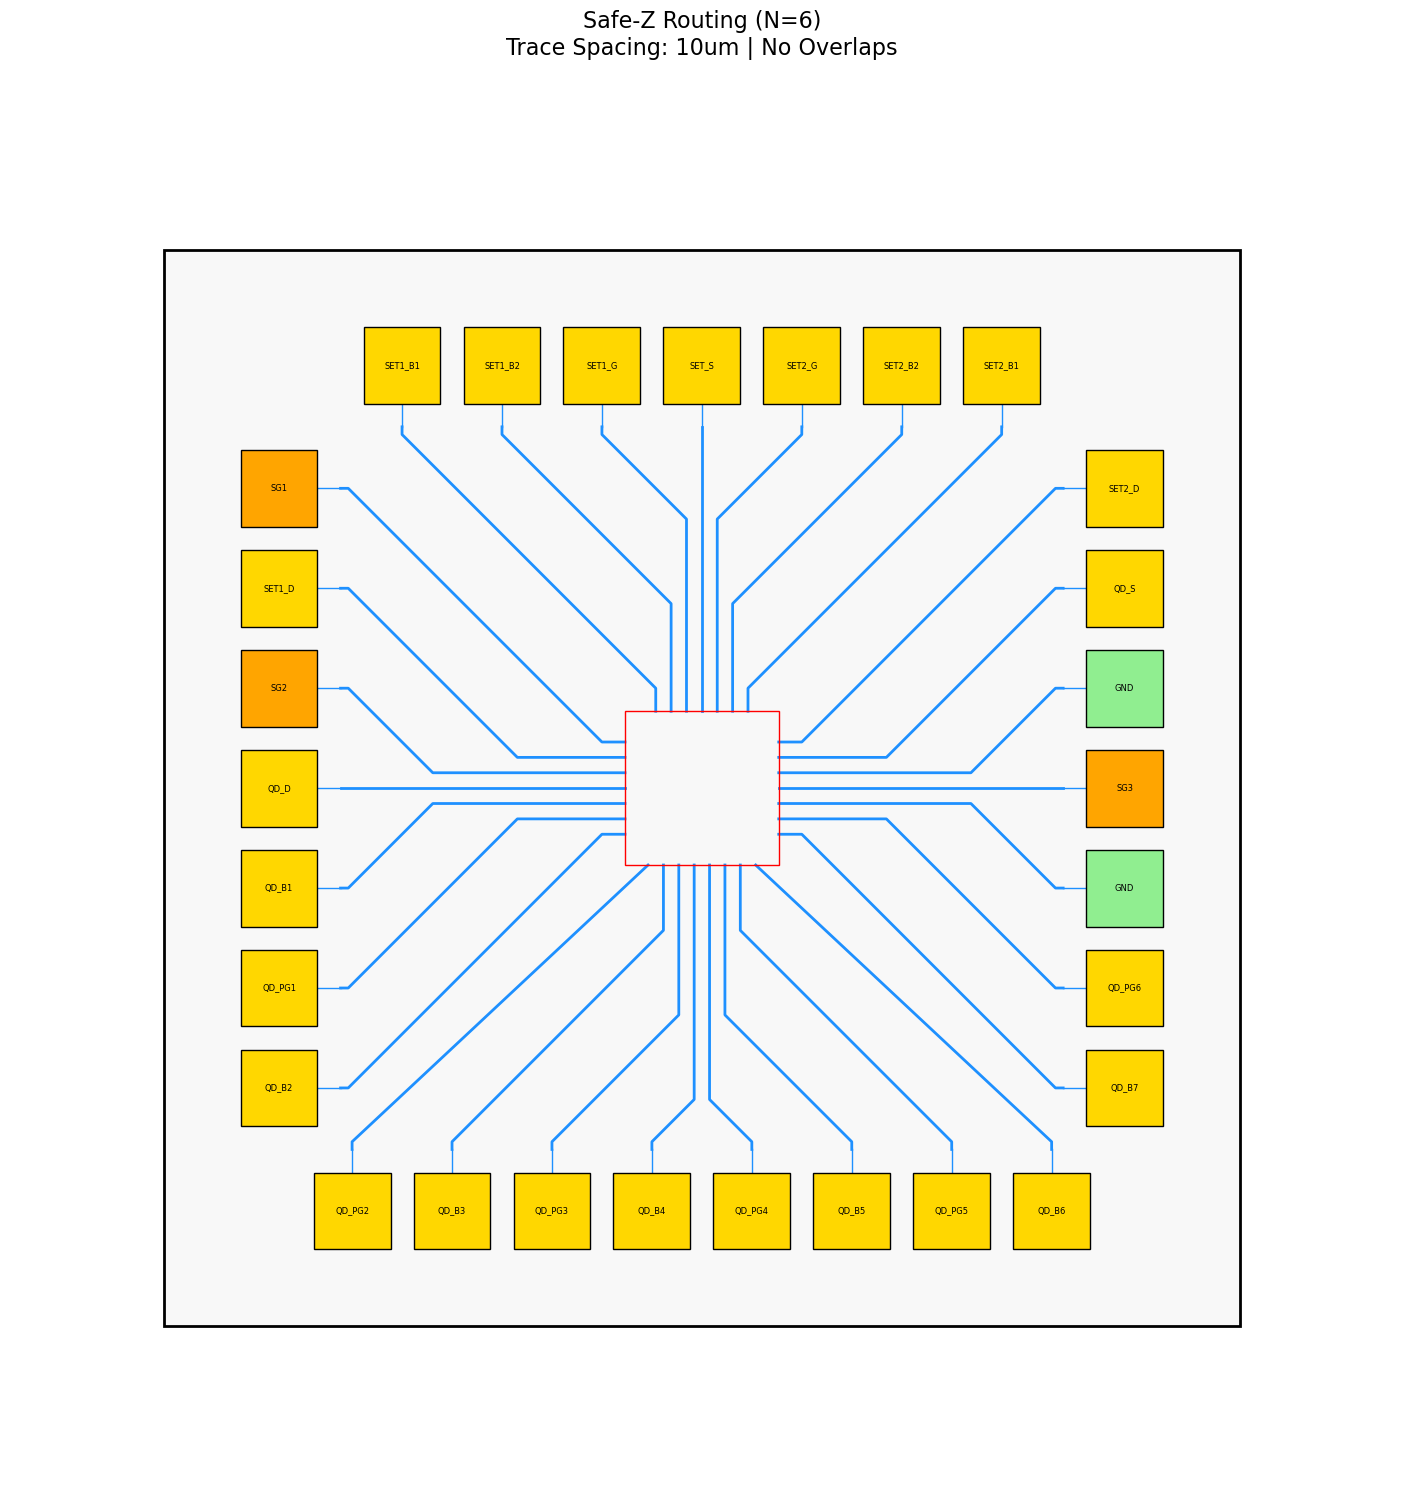

In [147]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re
import numpy as np

def create_safe_routed_layout(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=100,      
    pad_spacing=30,
    edge_margin=100,
    active_size=100,     
    trace_width=10,
    trace_spacing=10,    # 线间距
    taper_length=40,
    active_entry_len=100, # 理想的直线进入长度
    gds_filename='qd_layout_safe.gds'
):
    """
    Generates a Pad Layout with Safe Z-Routing.
    Features:
    - Calculates precise target pitch based on width + spacing.
    - Routes wires with a guaranteed safe distance from pads to avoid overlap.
    - Dynamically shortens the 'active_entry_len' if geometry is too tight for 45-deg routing.
    """

    # ==========================================
    # 1. Pad Generation (Symmetric Logic)
    # ==========================================
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    top_pads = []
    if num_sets >= 1: top_pads.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_pads.append("SET_S")
    if num_sets >= 2: top_pads.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    left_fixed = ["SG1"]
    if num_sets >= 1: left_fixed.append("SET1_D") 
    left_fixed.extend(["SG2", "QD_D"])
    
    right_fixed = []
    if num_sets >= 2: right_fixed.append("SET2_D")
    right_fixed.append("QD_S")
    right_fixed.extend(["GND", "SG3", "GND"]) 

    # Symmetry Logic
    len_seq = len(gate_sequence)
    len_L_fix = len(left_fixed)
    len_R_fix = len(right_fixed)
    len_Top = len(top_pads)
    
    available_w = layout_width - 2 * edge_margin
    best_config = (0, len_seq, 0)
    min_diff = float('inf')
    
    start_side = max(len_L_fix, len_R_fix)
    for target_side in range(start_side, start_side + len_seq):
        add_L = target_side - len_L_fix
        add_R = target_side - len_R_fix
        if add_L + add_R > len_seq: break
        n_bot = len_seq - (add_L + add_R)
        if n_bot > 0 and (n_bot * pad_width + (n_bot-1)*pad_spacing > available_w): continue
        diff = abs(n_bot - len_Top)
        if diff < min_diff:
            min_diff = diff
            best_config = (add_L, n_bot, add_R)
            
    n_L, n_B, n_R = best_config
    pads_left_extra = gate_sequence[:n_L]
    pads_bottom = gate_sequence[n_L : n_L + n_B]
    pads_right_extra = gate_sequence[n_L + n_B :]

    left_pads = left_fixed + pads_left_extra
    right_pads = right_fixed + pads_right_extra

    all_pads = [] 
    def assign_coords(pads, edge):
        count = len(pads)
        if count == 0: return
        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            for i, label in enumerate(pads):
                x = start_x + i * (pad_width + pad_spacing)
                cx, cy = x + pad_width/2, y + pad_height/2
                all_pads.append({'label': label, 'rect': (x, y, pad_width, pad_height), 'center': (cx, cy), 'edge': edge})
        else:
            total_span = count * pad_width + (count - 1) * pad_spacing
            top_y = (layout_height + total_span) / 2
            x = edge_margin if edge == 'left' else layout_width - edge_margin - pad_height
            for i, label in enumerate(pads):
                y = top_y - (i+1)*pad_width - i*pad_spacing
                cx, cy = x + pad_height/2, y + pad_width/2
                all_pads.append({'label': label, 'rect': (x, y, pad_height, pad_width), 'center': (cx, cy), 'edge': edge})

    assign_coords(top_pads, 'top')
    assign_coords(pads_bottom, 'bottom')
    assign_coords(left_pads, 'left')
    assign_coords(right_pads, 'right')

    # ==========================================
    # 2. Target Assignment (Center Aligned, Min Spacing)
    # ==========================================
    center_x = layout_width / 2
    center_y = layout_height / 2
    aa_x1 = center_x - active_size/2
    aa_x2 = center_x + active_size/2
    aa_y1 = center_y - active_size/2
    aa_y2 = center_y + active_size/2

    pads_by_edge = {'top': [], 'bottom': [], 'left': [], 'right': []}
    for p in all_pads: pads_by_edge[p['edge']].append(p)

    pads_by_edge['top'].sort(key=lambda p: p['center'][0])
    pads_by_edge['bottom'].sort(key=lambda p: p['center'][0])
    pads_by_edge['left'].sort(key=lambda p: p['center'][1], reverse=True)
    pads_by_edge['right'].sort(key=lambda p: p['center'][1], reverse=True)

    # Use specified trace spacing
    pitch = trace_width + trace_spacing
    
    def assign_targets(pads, edge):
        n = len(pads)
        if n == 0: return
        
        # Calculate offsets from center
        # If n is odd: 0, +/- pitch, +/- 2*pitch ...
        # If n is even: +/- 0.5*pitch, +/- 1.5*pitch ...
        indices = np.arange(n) - (n - 1) / 2
        offsets = indices * pitch
        
        if edge == 'top':
            for i, p in enumerate(pads):
                p['target'] = (center_x + offsets[i], aa_y2)
                p['target_edge'] = 'top'
        elif edge == 'bottom':
            for i, p in enumerate(pads):
                p['target'] = (center_x + offsets[i], aa_y1)
                p['target_edge'] = 'bottom'
        elif edge == 'left':
            for i, p in enumerate(pads):
                p['target'] = (aa_x1, center_y + offsets[i]) # High Y to Low Y logic handled by sort? 
                # Note: offsets goes - to +. Sort is High to Low.
                # Left sort: High Y (top) is index 0. 
                # We want index 0 to map to positive offset (High Y).
                # But 'offsets' array goes - ... +.
                # So we reverse offsets for Left/Right to match High-to-Low sort.
                p['target'] = (aa_x1, center_y + offsets[-(i+1)])
                p['target_edge'] = 'left'
        elif edge == 'right':
            for i, p in enumerate(pads):
                p['target'] = (aa_x2, center_y + offsets[-(i+1)])
                p['target_edge'] = 'right'

    for edge in ['top', 'bottom', 'left', 'right']:
        assign_targets(pads_by_edge[edge], edge)

    # ==========================================
    # 3. Robust "Safe-Z" Routing Logic
    # ==========================================
    lib = gdstk.Library()
    cell = lib.new_cell('QD_SAFE_ROUTE')
    LAYER_SUBSTRATE, LAYER_PAD, LAYER_TEXT, LAYER_TRACE, LAYER_ACTIVE = 0, 1, 2, 3, 10
    
    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=LAYER_SUBSTRATE))
    cell.add(gdstk.rectangle((aa_x1, aa_y1), (aa_x2, aa_y2), layer=LAYER_ACTIVE))

    def create_taper(p_rect, edge, t_len, t_width):
        x, y, w, h = p_rect
        cx, cy = x + w/2, y + h/2
        if edge == 'top':
            pts = [(x, y), (x+w, y), (cx+t_width/2, y-t_len), (cx-t_width/2, y-t_len)]
            start = (cx, y - t_len)
        elif edge == 'bottom':
            pts = [(x, y+h), (x+w, y+h), (cx+t_width/2, y+h+t_len), (cx-t_width/2, y+h+t_len)]
            start = (cx, y + h + t_len)
        elif edge == 'left':
            pts = [(x+w, y), (x+w, y+h), (x+w+t_len, cy+t_width/2), (x+w+t_len, cy-t_width/2)]
            start = (x+w+t_len, cy)
        elif edge == 'right':
            pts = [(x, y), (x, y+h), (x-t_len, cy+t_width/2), (x-t_len, cy-t_width/2)]
            start = (x-t_len, cy)
        return gdstk.Polygon(pts, layer=LAYER_TRACE), start

    def route_safe_z(start_pt, target_pt, edge, width):
        """
        Routes from Pad to Active Area ensuring:
        1. Leaves Pad perpendicularly for a SAFE MARGIN (avoid pad overlap).
        2. Routes 45-deg diagonal.
        3. Enters Active Area perpendicularly (Adjusts length if needed).
        """
        x1, y1 = start_pt
        x2, y2 = target_pt
        
        # Safe Margin to clear the pad row
        safe_margin = 10
        
        pts = [(x1, y1)]
        
        if edge in ['top', 'bottom']:
            is_top = (edge == 'top')
            sign_y = -1 if is_top else 1
            
            # 1. Safe Point
            y_safe = y1 + sign_y * safe_margin
            pts.append((x1, y_safe))
            
            # 2. Determine Entry Point
            # We want to end at (x2, y2) with a vertical segment
            # The diagonal connects (x1, y_safe) to (x2, y_turn_end)
            # Constraint: |dy_diag| = |dx| = |x2 - x1|
            # y_turn_end = y_safe + sign_y * |dx|
            
            dx = abs(x2 - x1)
            y_turn_end = y_safe + sign_y * dx
            
            # Check if y_turn_end overshoots the target Y
            # For top: y_turn_end must be > y2. For bottom: y_turn_end must be < y2.
            # Calculate available vertical space from safe point to target
            dy_available = abs(y2 - y_safe)
            
            if dx > dy_available:
                # Geometry impossible with simple Z-shape (Too much lateral shift).
                # Fallback: Just draw straight line to target (ignoring 45 deg) 
                # or add a horizontal jog.
                # Given the layout dimensions, this usually means we are super close to center.
                # Let's assume straight connection from safe point for robustness.
                pts.append((x2, y2))
            else:
                # Normal Case: We have enough vertical space.
                # The segment from y_turn_end to y2 is the "Active Entry"
                # We simply connect the diagonal result to the target.
                pts.append((x2, y_turn_end))
                pts.append((x2, y2))
                
        else: # Left / Right
            is_left = (edge == 'left')
            sign_x = 1 if is_left else -1
            
            # 1. Safe Point
            x_safe = x1 + sign_x * safe_margin
            pts.append((x_safe, y1))
            
            # 2. Diagonal
            dy = abs(y2 - y1)
            x_turn_end = x_safe + sign_x * dy
            
            dx_available = abs(x2 - x_safe)
            
            if dy > dx_available:
                pts.append((x2, y2))
            else:
                pts.append((x_turn_end, y2))
                pts.append((x2, y2))
            
        return gdstk.FlexPath(pts, width, layer=LAYER_TRACE), pts

    # Loop
    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        edge = p['edge']
        
        cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=LAYER_PAD))
        
        cx, cy = x + w/2, y + h/2
        rot_rad = 0 if w > h else math.pi / 2
        cell.add(gdstk.Label(label, (cx, cy), layer=LAYER_TEXT, magnification=10, rotation=rot_rad))
        
        poly_taper, trace_start = create_taper(p['rect'], edge, taper_length, trace_width)
        cell.add(poly_taper)
        
        path_obj, path_pts = route_safe_z(trace_start, p['target'], edge, trace_width)
        cell.add(path_obj)
        p['trace_points'] = path_pts

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # Visualization
    fig, ax = plt.subplots(figsize=(15, 15))
    margin_view = 200
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f8f8f8')
    ax.add_patch(chip)
    active_area = patches.Rectangle((aa_x1, aa_y1), active_size, active_size, lw=1, ec='red', fc='none', zorder=10)
    ax.add_patch(active_area)

    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc, zorder=5)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=6, rotation=t_rot, zorder=6)
        
        if 'trace_points' in p:
            pts = p['trace_points']
            line_x, line_y = zip(*pts)
            ax.plot(line_x, line_y, color='#1E90FF', linewidth=2, zorder=4)
            _, t_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
            cx, cy = x + w/2, y + h/2
            ax.plot([cx, t_start[0]], [cy, t_start[1]], color='#1E90FF', linewidth=1, zorder=4)

    plt.title(f"Safe-Z Routing (N={N})\nTrace Spacing: {trace_spacing}um | No Overlaps", fontsize=16, pad=30)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    create_safe_routed_layout(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 100,
        active_size = 200, # Increased for visual clarity
        trace_width = 10,
        trace_spacing = 10,
        taper_length = 30,
        active_entry_len = 40
    )

GDS file saved to: qd_layout_safe_v2.gds


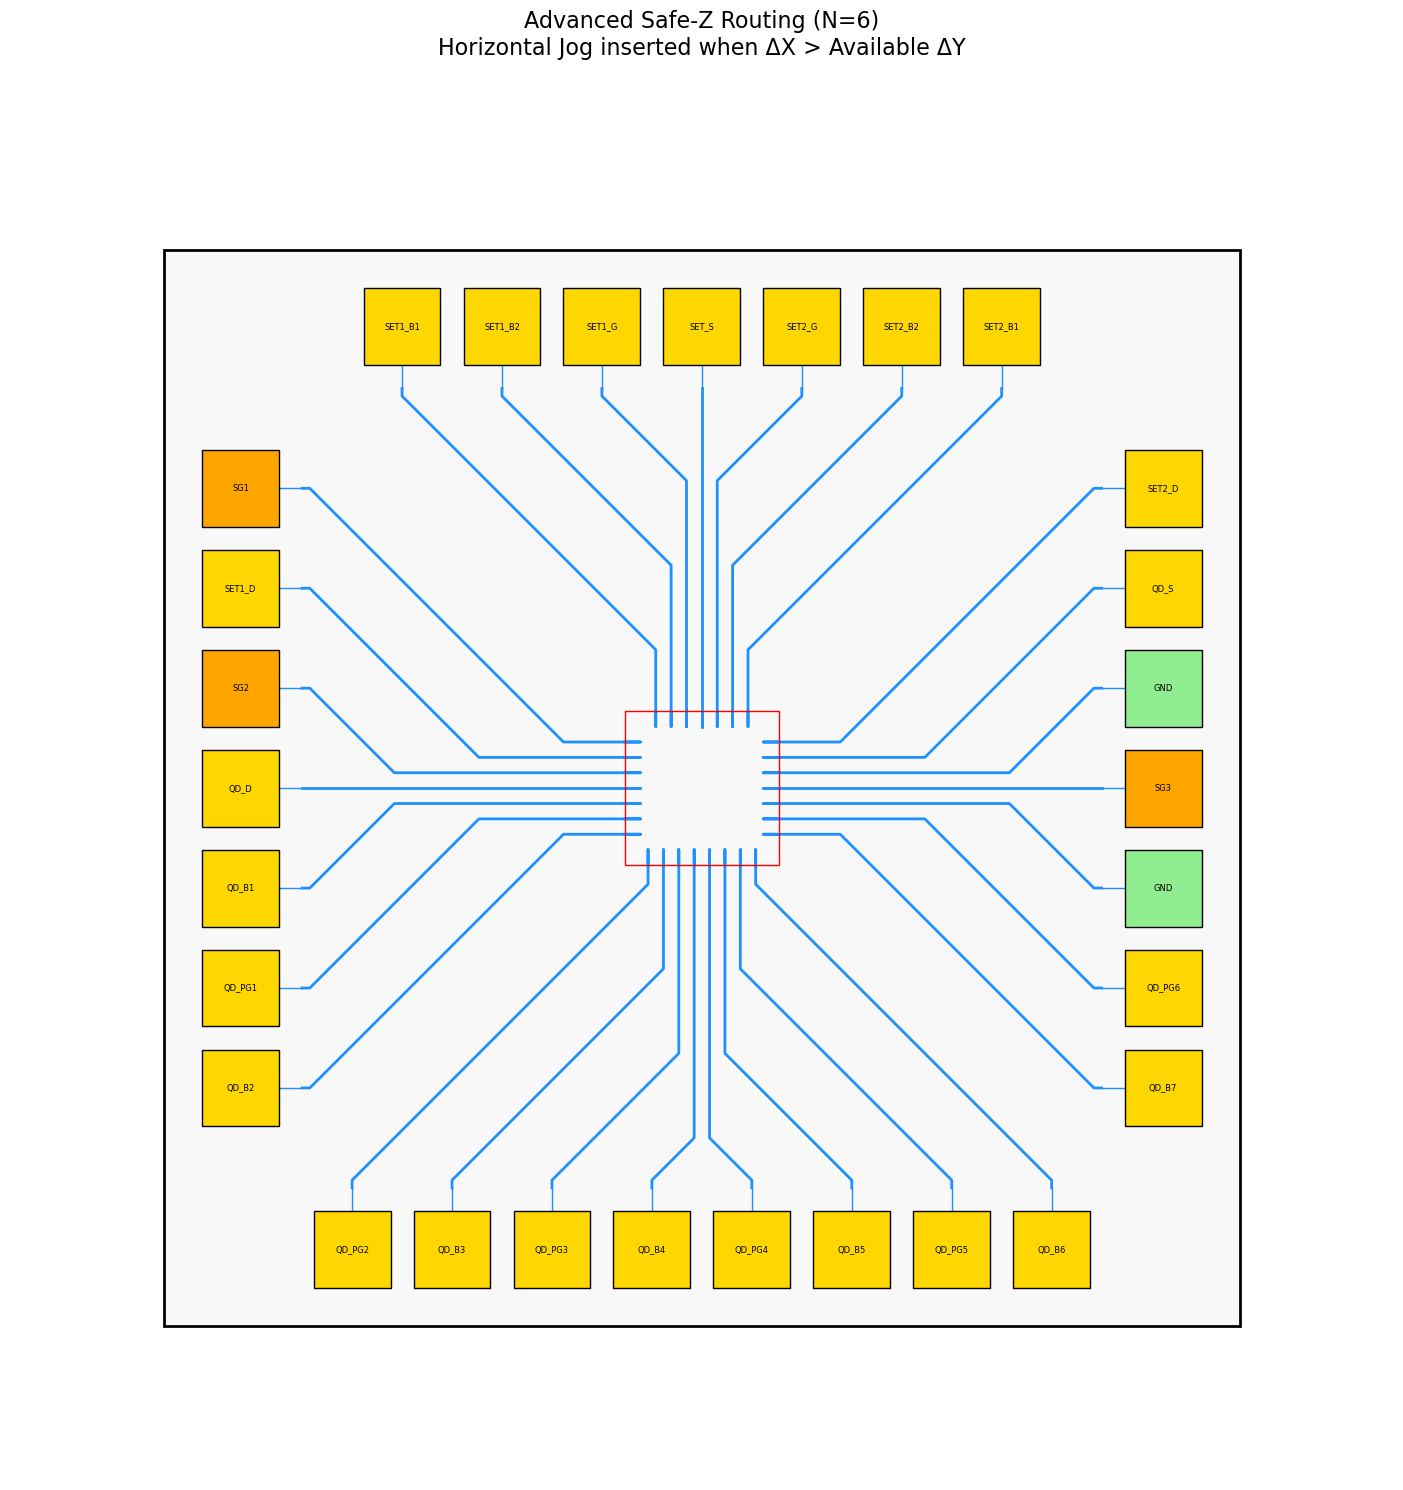

In [156]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re
import numpy as np

def create_safe_routed_layout_v2(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=100,      
    pad_spacing=30,
    edge_margin=100,
    active_size=100,     
    trace_width=10,
    trace_spacing=10,    # 线间距
    taper_length=40,
    active_entry_len=100, # 理想的直线进入长度
    gds_filename='qd_layout_safe_v2.gds'
):
    """
    Generates a Pad Layout with Advanced Safe Z-Routing.
    - Handles large Delta X situations by inserting a horizontal jog (bridge) 
      between two 45-degree segments.
    - Strictly enforces perpendicular exit from Pad and entry to Active Region.
    """

    # ==========================================
    # 1. Pad Generation (Symmetric Logic)
    # ==========================================
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    top_pads = []
    if num_sets >= 1: top_pads.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_pads.append("SET_S")
    if num_sets >= 2: top_pads.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    left_fixed = ["SG1"]
    if num_sets >= 1: left_fixed.append("SET1_D") 
    left_fixed.extend(["SG2", "QD_D"])
    
    right_fixed = []
    if num_sets >= 2: right_fixed.append("SET2_D")
    right_fixed.append("QD_S")
    right_fixed.extend(["GND", "SG3", "GND"]) 

    # Symmetry Logic
    len_seq = len(gate_sequence)
    len_L_fix = len(left_fixed)
    len_R_fix = len(right_fixed)
    len_Top = len(top_pads)
    
    available_w = layout_width - 2 * edge_margin
    best_config = (0, len_seq, 0)
    min_diff = float('inf')
    
    start_side = max(len_L_fix, len_R_fix)
    for target_side in range(start_side, start_side + len_seq):
        add_L = target_side - len_L_fix
        add_R = target_side - len_R_fix
        if add_L + add_R > len_seq: break
        n_bot = len_seq - (add_L + add_R)
        if n_bot > 0 and (n_bot * pad_width + (n_bot-1)*pad_spacing > available_w): continue
        diff = abs(n_bot - len_Top)
        if diff < min_diff:
            min_diff = diff
            best_config = (add_L, n_bot, add_R)
            
    n_L, n_B, n_R = best_config
    pads_left_extra = gate_sequence[:n_L]
    pads_bottom = gate_sequence[n_L : n_L + n_B]
    pads_right_extra = gate_sequence[n_L + n_B :]

    left_pads = left_fixed + pads_left_extra
    right_pads = right_fixed + pads_right_extra

    all_pads = [] 
    def assign_coords(pads, edge):
        count = len(pads)
        if count == 0: return
        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            for i, label in enumerate(pads):
                x = start_x + i * (pad_width + pad_spacing)
                cx, cy = x + pad_width/2, y + pad_height/2
                all_pads.append({'label': label, 'rect': (x, y, pad_width, pad_height), 'center': (cx, cy), 'edge': edge})
        else:
            total_span = count * pad_width + (count - 1) * pad_spacing
            top_y = (layout_height + total_span) / 2
            x = edge_margin if edge == 'left' else layout_width - edge_margin - pad_height
            for i, label in enumerate(pads):
                y = top_y - (i+1)*pad_width - i*pad_spacing
                cx, cy = x + pad_height/2, y + pad_width/2
                all_pads.append({'label': label, 'rect': (x, y, pad_height, pad_width), 'center': (cx, cy), 'edge': edge})

    assign_coords(top_pads, 'top')
    assign_coords(pads_bottom, 'bottom')
    assign_coords(left_pads, 'left')
    assign_coords(right_pads, 'right')

    # ==========================================
    # 2. Target Assignment (Center Aligned)
    # ==========================================
    center_x = layout_width / 2
    center_y = layout_height / 2
    aa_x1 = center_x - active_size/2
    aa_x2 = center_x + active_size/2
    aa_y1 = center_y - active_size/2
    aa_y2 = center_y + active_size/2

    pads_by_edge = {'top': [], 'bottom': [], 'left': [], 'right': []}
    for p in all_pads: pads_by_edge[p['edge']].append(p)

    pads_by_edge['top'].sort(key=lambda p: p['center'][0])
    pads_by_edge['bottom'].sort(key=lambda p: p['center'][0])
    pads_by_edge['left'].sort(key=lambda p: p['center'][1], reverse=True)
    pads_by_edge['right'].sort(key=lambda p: p['center'][1], reverse=True)

    pitch = trace_width + trace_spacing
    
    def assign_targets(pads, edge):
        n = len(pads)
        if n == 0: return
        indices = np.arange(n) - (n - 1) / 2
        offsets = indices * pitch
        
        if edge == 'top':
            for i, p in enumerate(pads):
                p['target'] = (center_x + offsets[i], aa_y2)
                p['target_edge'] = 'top'
        elif edge == 'bottom':
            for i, p in enumerate(pads):
                p['target'] = (center_x + offsets[i], aa_y1)
                p['target_edge'] = 'bottom'
        elif edge == 'left':
            for i, p in enumerate(pads):
                p['target'] = (aa_x1, center_y + offsets[-(i+1)])
                p['target_edge'] = 'left'
        elif edge == 'right':
            for i, p in enumerate(pads):
                p['target'] = (aa_x2, center_y + offsets[-(i+1)])
                p['target_edge'] = 'right'

    for edge in ['top', 'bottom', 'left', 'right']:
        assign_targets(pads_by_edge[edge], edge)

    # ==========================================
    # 3. Robust "Safe-Z" Routing Logic (Modified)
    # ==========================================
    lib = gdstk.Library()
    cell = lib.new_cell('QD_SAFE_ROUTE_V2')
    LAYER_SUBSTRATE, LAYER_PAD, LAYER_TEXT, LAYER_TRACE, LAYER_ACTIVE = 0, 1, 2, 3, 10
    
    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=LAYER_SUBSTRATE))
    cell.add(gdstk.rectangle((aa_x1, aa_y1), (aa_x2, aa_y2), layer=LAYER_ACTIVE))

    def create_taper(p_rect, edge, t_len, t_width):
        x, y, w, h = p_rect
        cx, cy = x + w/2, y + h/2
        if edge == 'top':
            pts = [(x, y), (x+w, y), (cx+t_width/2, y-t_len), (cx-t_width/2, y-t_len)]
            start = (cx, y - t_len)
        elif edge == 'bottom':
            pts = [(x, y+h), (x+w, y+h), (cx+t_width/2, y+h+t_len), (cx-t_width/2, y+h+t_len)]
            start = (cx, y + h + t_len)
        elif edge == 'left':
            pts = [(x+w, y), (x+w, y+h), (x+w+t_len, cy+t_width/2), (x+w+t_len, cy-t_width/2)]
            start = (x+w+t_len, cy)
        elif edge == 'right':
            pts = [(x, y), (x, y+h), (x-t_len, cy+t_width/2), (x-t_len, cy-t_width/2)]
            start = (x-t_len, cy)
        return gdstk.Polygon(pts, layer=LAYER_TRACE), start

    def route_safe_z(start_pt, target_pt, edge, width):
        """
        Modified Routing Logic:
        If ΔX > Available ΔY (geometry constrained):
           Path: Vertical Out -> 45 Deg -> Horizontal Jog -> 45 Deg -> Vertical In
        Else:
           Path: Vertical Out -> 45 Deg -> Vertical In
        """
        x1, y1 = start_pt
        x2, y2 = target_pt
        
        # Safe Margin to clear the pad row
        safe_margin = 10 
        
        pts = [(x1, y1)]
        
        if edge in ['top', 'bottom']:
            is_top = (edge == 'top')
            sign_y = -1 if is_top else 1
            
            # 1. Safe Point (Vertical out from pad)
            y_safe = y1 + sign_y * safe_margin
            pts.append((x1, y_safe))
            
            # Target Entry Point (before hitting active area)
            y_entry = y2 + sign_y * active_entry_len # Back off from target
            
            # Check Geometry
            # Available vertical space for diagonals
            # Note: Top pad y_safe is high, y_entry is low. 
            # Height = y_safe - y_entry (for top)
            avail_h = abs(y_entry - y_safe)
            needed_w = abs(x2 - x1)
            sign_x = 1 if x2 > x1 else -1
            
            if needed_w > avail_h:
                # Case 1: Need Horizontal Jog (Bridge)
                # We split the vertical drop into two 45-deg segments.
                # Let's split height evenly for symmetry.
                h_leg = avail_h / 2
                
                # Point A: End of first diagonal
                # Go down h_leg, go side h_leg
                y_mid = y_safe + sign_y * h_leg # if top, y_safe - h_leg
                x_mid_1 = x1 + sign_x * h_leg
                pts.append((x_mid_1, y_mid))
                
                # Point B: Start of second diagonal
                # We need to end at x2 after another h_leg lateral move
                x_mid_2 = x2 - sign_x * h_leg
                # y is same as y_mid (horizontal jog)
                pts.append((x_mid_2, y_mid))
                
                # Point C: End of second diagonal (Entry Point)
                pts.append((x2, y_entry))
                
            else:
                # Case 2: Standard Z-shape (Vertical-Diagonal-Vertical)
                # Diagonal connects (x1, y_safe) to (x2, y_turn_end)
                # |dy| = |dx|
                dy_diag = needed_w
                y_turn_end = y_safe + sign_y * dy_diag
                
                pts.append((x2, y_turn_end))
                pts.append((x2, y_entry))
            
            # Final segment: Straight into Active Area
            pts.append((x2, y2))
                
        else: # Left / Right
            is_left = (edge == 'left')
            sign_x = 1 if is_left else -1
            
            # 1. Safe Point (Horizontal out from pad)
            x_safe = x1 + sign_x * safe_margin
            pts.append((x_safe, y1))
            
            # Target Entry Point
            x_entry = x2 + sign_x * active_entry_len
            
            # Check Geometry
            avail_w = abs(x_entry - x_safe)
            needed_h = abs(y2 - y1)
            sign_y = 1 if y2 > y1 else -1
            
            if needed_h > avail_w:
                # Case 1: Need Vertical Jog
                w_leg = avail_w / 2
                
                # Point A: End of first diagonal
                x_mid = x_safe + sign_x * w_leg
                y_mid_1 = y1 + sign_y * w_leg
                pts.append((x_mid, y_mid_1))
                
                # Point B: Start of second diagonal
                y_mid_2 = y2 - sign_y * w_leg
                pts.append((x_mid, y_mid_2))
                
                # Point C: End of second diagonal
                pts.append((x_entry, y2))
                
            else:
                # Case 2: Standard Z-shape
                dx_diag = needed_h
                x_turn_end = x_safe + sign_x * dx_diag
                
                pts.append((x_turn_end, y2))
                pts.append((x_entry, y2))
                
            # Final segment
            pts.append((x2, y2))
            
        return gdstk.FlexPath(pts, width, layer=LAYER_TRACE), pts

    # Loop
    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        edge = p['edge']
        
        cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=LAYER_PAD))
        
        cx, cy = x + w/2, y + h/2
        rot_rad = 0 if w > h else math.pi / 2
        cell.add(gdstk.Label(label, (cx, cy), layer=LAYER_TEXT, magnification=10, rotation=rot_rad))
        
        poly_taper, trace_start = create_taper(p['rect'], edge, taper_length, trace_width)
        cell.add(poly_taper)
        
        path_obj, path_pts = route_safe_z(trace_start, p['target'], edge, trace_width)
        cell.add(path_obj)
        p['trace_points'] = path_pts

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # Visualization
    fig, ax = plt.subplots(figsize=(15, 15))
    margin_view = 200
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f8f8f8')
    ax.add_patch(chip)
    active_area = patches.Rectangle((aa_x1, aa_y1), active_size, active_size, lw=1, ec='red', fc='none', zorder=10)
    ax.add_patch(active_area)

    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc, zorder=5)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=6, rotation=t_rot, zorder=6)
        
        if 'trace_points' in p:
            pts = p['trace_points']
            line_x, line_y = zip(*pts)
            ax.plot(line_x, line_y, color='#1E90FF', linewidth=2, zorder=4)
            _, t_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
            cx, cy = x + w/2, y + h/2
            ax.plot([cx, t_start[0]], [cy, t_start[1]], color='#1E90FF', linewidth=1, zorder=4)

    plt.title(f"Advanced Safe-Z Routing (N={N})\nHorizontal Jog inserted when ΔX > Available ΔY", fontsize=16, pad=30)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    create_safe_routed_layout_v2(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 50,
        active_size = 200, 
        trace_width = 10,
        trace_spacing = 10,
        taper_length = 30,
        active_entry_len = 20
    )

GDS file saved to: qd_layout_straight_entry.gds


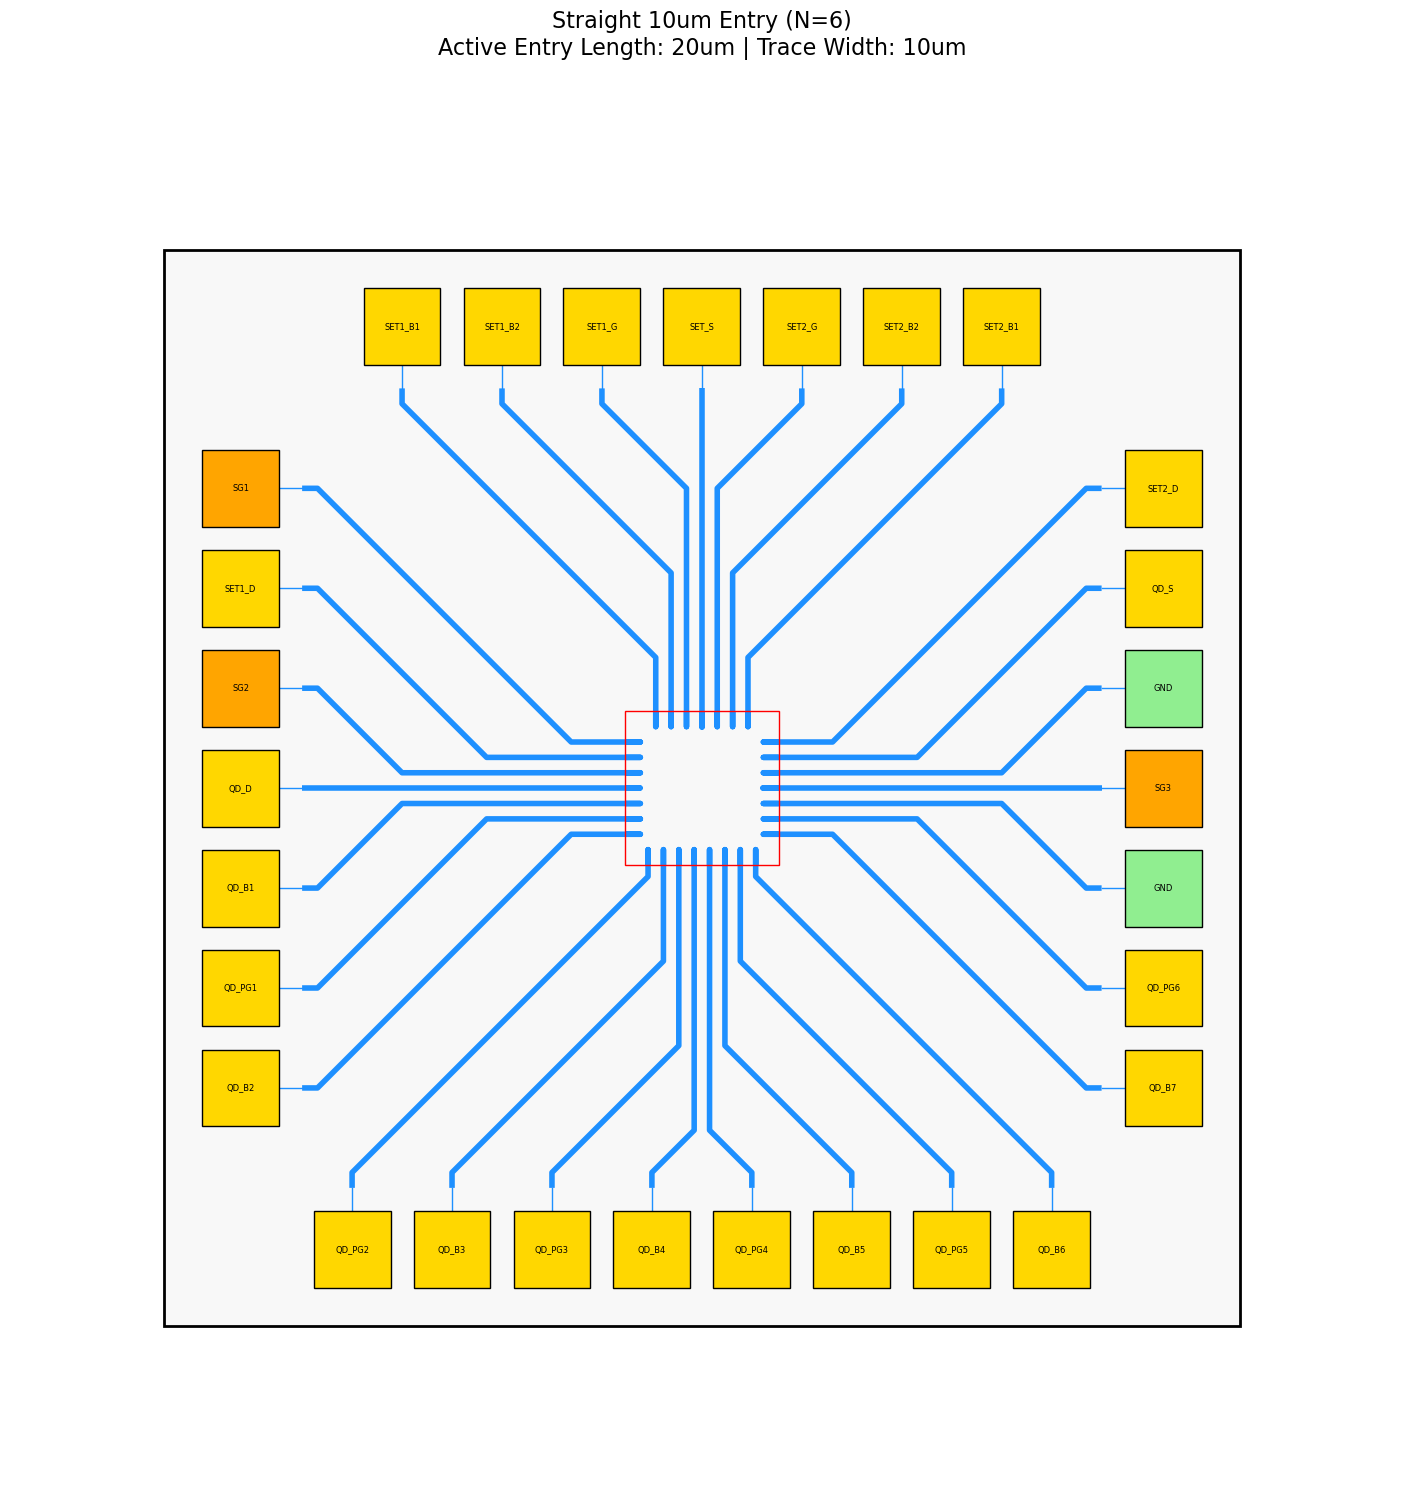

In [158]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re
import numpy as np

def create_straight_entry_layout(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=100,      
    pad_spacing=30,
    edge_margin=100,
    active_size=200,     # Active Area 尺寸
    trace_width=10,      # [关键修改] 导线宽度设为 10um
    trace_spacing=10,    # 线间距
    taper_length=40,
    active_entry_len=50, # [关键修改] 直线进入段的长度
    gds_filename='qd_layout_straight_entry.gds'
):
    """
    Generates a Pad Layout where wires enter the Active Region as straight lines
    with a constant width of 10um.
    """

    # ==========================================
    # 1. Pad Generation (Symmetric Logic)
    # ==========================================
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    top_pads = []
    if num_sets >= 1: top_pads.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_pads.append("SET_S")
    if num_sets >= 2: top_pads.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    left_fixed = ["SG1"]
    if num_sets >= 1: left_fixed.append("SET1_D") 
    left_fixed.extend(["SG2", "QD_D"])
    
    right_fixed = []
    if num_sets >= 2: right_fixed.append("SET2_D")
    right_fixed.append("QD_S")
    right_fixed.extend(["GND", "SG3", "GND"]) 

    # Symmetry Logic
    len_seq = len(gate_sequence)
    len_L_fix = len(left_fixed)
    len_R_fix = len(right_fixed)
    len_Top = len(top_pads)
    
    available_w = layout_width - 2 * edge_margin
    best_config = (0, len_seq, 0)
    min_diff = float('inf')
    
    start_side = max(len_L_fix, len_R_fix)
    for target_side in range(start_side, start_side + len_seq):
        add_L = target_side - len_L_fix
        add_R = target_side - len_R_fix
        if add_L + add_R > len_seq: break
        n_bot = len_seq - (add_L + add_R)
        if n_bot > 0 and (n_bot * pad_width + (n_bot-1)*pad_spacing > available_w): continue
        diff = abs(n_bot - len_Top)
        if diff < min_diff:
            min_diff = diff
            best_config = (add_L, n_bot, add_R)
            
    n_L, n_B, n_R = best_config
    pads_left_extra = gate_sequence[:n_L]
    pads_bottom = gate_sequence[n_L : n_L + n_B]
    pads_right_extra = gate_sequence[n_L + n_B :]

    left_pads = left_fixed + pads_left_extra
    right_pads = right_fixed + pads_right_extra

    all_pads = [] 
    def assign_coords(pads, edge):
        count = len(pads)
        if count == 0: return
        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            for i, label in enumerate(pads):
                x = start_x + i * (pad_width + pad_spacing)
                cx, cy = x + pad_width/2, y + pad_height/2
                all_pads.append({'label': label, 'rect': (x, y, pad_width, pad_height), 'center': (cx, cy), 'edge': edge})
        else:
            total_span = count * pad_width + (count - 1) * pad_spacing
            top_y = (layout_height + total_span) / 2
            x = edge_margin if edge == 'left' else layout_width - edge_margin - pad_height
            for i, label in enumerate(pads):
                y = top_y - (i+1)*pad_width - i*pad_spacing
                cx, cy = x + pad_height/2, y + pad_width/2
                all_pads.append({'label': label, 'rect': (x, y, pad_height, pad_width), 'center': (cx, cy), 'edge': edge})

    assign_coords(top_pads, 'top')
    assign_coords(pads_bottom, 'bottom')
    assign_coords(left_pads, 'left')
    assign_coords(right_pads, 'right')

    # ==========================================
    # 2. Target Assignment (Center Aligned)
    # ==========================================
    center_x = layout_width / 2
    center_y = layout_height / 2
    aa_x1 = center_x - active_size/2
    aa_x2 = center_x + active_size/2
    aa_y1 = center_y - active_size/2
    aa_y2 = center_y + active_size/2

    pads_by_edge = {'top': [], 'bottom': [], 'left': [], 'right': []}
    for p in all_pads: pads_by_edge[p['edge']].append(p)

    pads_by_edge['top'].sort(key=lambda p: p['center'][0])
    pads_by_edge['bottom'].sort(key=lambda p: p['center'][0])
    pads_by_edge['left'].sort(key=lambda p: p['center'][1], reverse=True)
    pads_by_edge['right'].sort(key=lambda p: p['center'][1], reverse=True)

    pitch = trace_width + trace_spacing
    
    def assign_targets(pads, edge):
        n = len(pads)
        if n == 0: return
        indices = np.arange(n) - (n - 1) / 2
        offsets = indices * pitch
        
        if edge == 'top':
            for i, p in enumerate(pads):
                p['target'] = (center_x + offsets[i], aa_y2)
                p['target_edge'] = 'top'
        elif edge == 'bottom':
            for i, p in enumerate(pads):
                p['target'] = (center_x + offsets[i], aa_y1)
                p['target_edge'] = 'bottom'
        elif edge == 'left':
            for i, p in enumerate(pads):
                p['target'] = (aa_x1, center_y + offsets[-(i+1)])
                p['target_edge'] = 'left'
        elif edge == 'right':
            for i, p in enumerate(pads):
                p['target'] = (aa_x2, center_y + offsets[-(i+1)])
                p['target_edge'] = 'right'

    for edge in ['top', 'bottom', 'left', 'right']:
        assign_targets(pads_by_edge[edge], edge)

    # ==========================================
    # 3. Routing Logic (Straight Entry)
    # ==========================================
    lib = gdstk.Library()
    cell = lib.new_cell('QD_STRAIGHT_ENTRY')
    LAYER_SUBSTRATE, LAYER_PAD, LAYER_TEXT, LAYER_TRACE, LAYER_ACTIVE = 0, 1, 2, 3, 10
    
    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=LAYER_SUBSTRATE))
    cell.add(gdstk.rectangle((aa_x1, aa_y1), (aa_x2, aa_y2), layer=LAYER_ACTIVE))

    def create_taper(p_rect, edge, t_len, t_width):
        x, y, w, h = p_rect
        cx, cy = x + w/2, y + h/2
        if edge == 'top':
            pts = [(x, y), (x+w, y), (cx+t_width/2, y-t_len), (cx-t_width/2, y-t_len)]
            start = (cx, y - t_len)
        elif edge == 'bottom':
            pts = [(x, y+h), (x+w, y+h), (cx+t_width/2, y+h+t_len), (cx-t_width/2, y+h+t_len)]
            start = (cx, y + h + t_len)
        elif edge == 'left':
            pts = [(x+w, y), (x+w, y+h), (x+w+t_len, cy+t_width/2), (x+w+t_len, cy-t_width/2)]
            start = (x+w+t_len, cy)
        elif edge == 'right':
            pts = [(x, y), (x, y+h), (x-t_len, cy+t_width/2), (x-t_len, cy-t_width/2)]
            start = (x-t_len, cy)
        return gdstk.Polygon(pts, layer=LAYER_TRACE), start

    def route_wire(start_pt, target_pt, edge, width):
        """
        Routes a constant width wire.
        Ensures the final segment is purely vertical/horizontal (active_entry_len).
        """
        x1, y1 = start_pt
        x2, y2 = target_pt
        
        safe_margin = 20 
        
        pts = [(x1, y1)]
        
        if edge in ['top', 'bottom']:
            is_top = (edge == 'top')
            sign_y = -1 if is_top else 1
            
            # 1. Safe Point (Vertical out)
            y_safe = y1 + sign_y * safe_margin
            pts.append((x1, y_safe))
            
            # 2. Target Entry Point (Straight segment before Active Area)
            y_entry = y2 + sign_y * active_entry_len 
            
            dx = abs(x2 - x1)
            sign_x = 1 if x2 > x1 else -1
            
            # Check if Jog is needed
            avail_h = abs(y_entry - y_safe)
            
            if dx > avail_h:
                # Jog required
                h_leg = avail_h / 2
                y_mid = y_safe + sign_y * h_leg
                
                # Diag 1
                x_mid_1 = x1 + sign_x * h_leg
                pts.append((x_mid_1, y_mid))
                
                # Jog
                x_mid_2 = x2 - sign_x * h_leg
                pts.append((x_mid_2, y_mid))
                
                # Diag 2 -> Entry Point
                pts.append((x2, y_entry))
            else:
                # Standard Z
                dy_diag = dx
                y_turn_end = y_safe + sign_y * dy_diag
                pts.append((x2, y_turn_end))
                pts.append((x2, y_entry))
                
            # Final Straight Segment
            pts.append((x2, y2))
                
        else: # Left / Right
            is_left = (edge == 'left')
            sign_x = 1 if is_left else -1
            
            x_safe = x1 + sign_x * safe_margin
            pts.append((x_safe, y1))
            
            x_entry = x2 + sign_x * active_entry_len
            
            dy = abs(y2 - y1)
            sign_y = 1 if y2 > y1 else -1
            
            avail_w = abs(x_entry - x_safe)
            
            if dy > avail_w:
                # Jog
                w_leg = avail_w / 2
                x_mid = x_safe + sign_x * w_leg
                
                y_mid_1 = y1 + sign_y * w_leg
                pts.append((x_mid, y_mid_1))
                
                y_mid_2 = y2 - sign_y * w_leg
                pts.append((x_mid, y_mid_2))
                
                pts.append((x_entry, y2))
            else:
                # Standard Z
                dx_diag = dy
                x_turn_end = x_safe + sign_x * dx_diag
                pts.append((x_turn_end, y2))
                pts.append((x_entry, y2))
                
            # Final Straight Segment
            pts.append((x2, y2))
            
        # Use simple_path=True or ends='flush' to avoid rounded corners messing up the straight edge
        return gdstk.FlexPath(pts, width, layer=LAYER_TRACE, ends="flush"), pts

    # Loop
    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        edge = p['edge']
        
        cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=LAYER_PAD))
        cx, cy = x + w/2, y + h/2
        rot_rad = 0 if w > h else math.pi / 2
        cell.add(gdstk.Label(label, (cx, cy), layer=LAYER_TEXT, magnification=10, rotation=rot_rad))
        
        poly_taper, trace_start = create_taper(p['rect'], edge, taper_length, trace_width)
        cell.add(poly_taper)
        
        path_obj, path_pts = route_wire(trace_start, p['target'], edge, trace_width)
        cell.add(path_obj)
        p['trace_points'] = path_pts

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # Visualization
    fig, ax = plt.subplots(figsize=(15, 15))
    margin_view = 200
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f8f8f8')
    ax.add_patch(chip)
    active_area = patches.Rectangle((aa_x1, aa_y1), active_size, active_size, lw=1, ec='red', fc='none', zorder=10)
    ax.add_patch(active_area)

    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc, zorder=5)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=6, rotation=t_rot, zorder=6)
        
        if 'trace_points' in p:
            pts = p['trace_points']
            line_x, line_y = zip(*pts)
            # Visualize trace with actual width to verify no overlaps/tapers
            # Use a thick line to represent the 10um width
            ax.plot(line_x, line_y, color='#1E90FF', linewidth=4, solid_capstyle='butt', zorder=4)
            
            _, t_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
            cx, cy = x + w/2, y + h/2
            ax.plot([cx, t_start[0]], [cy, t_start[1]], color='#1E90FF', linewidth=1, zorder=4)

    plt.title(f"Straight 10um Entry (N={N})\nActive Entry Length: {active_entry_len}um | Trace Width: {trace_width}um", fontsize=16, pad=30)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    create_straight_entry_layout(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 50,
        active_size = 200,     
        trace_width = 10,    # [设置] 10um 导线宽度
        trace_spacing = 10,
        taper_length = 30,
        active_entry_len = 20
    )

Routing Pad: SET1_B1 from (310.0, 1220) to (np.float64(640.0), 780.0) via [(310.0, 1220), (310.0, 1200), (np.float64(640.0), np.float64(870.0)), (np.float64(640.0), 780.0)]
Routing Pad: SET1_B2 from (440.0, 1220) to (np.float64(660.0), 780.0) via [(440.0, 1220), (440.0, 1200), (np.float64(660.0), np.float64(980.0)), (np.float64(660.0), 780.0)]
Routing Pad: SET1_G from (570.0, 1220) to (np.float64(680.0), 780.0) via [(570.0, 1220), (570.0, 1200), (np.float64(680.0), np.float64(1090.0)), (np.float64(680.0), 780.0)]
Routing Pad: SET_S from (700.0, 1220) to (np.float64(700.0), 780.0) via [(700.0, 1220), (700.0, 1200), (np.float64(700.0), np.float64(1200.0)), (np.float64(700.0), 780.0)]
Routing Pad: SET2_G from (830.0, 1220) to (np.float64(720.0), 780.0) via [(830.0, 1220), (830.0, 1200), (np.float64(720.0), np.float64(1090.0)), (np.float64(720.0), 780.0)]
Routing Pad: SET2_B2 from (960.0, 1220) to (np.float64(740.0), 780.0) via [(960.0, 1220), (960.0, 1200), (np.float64(740.0), np.float64(

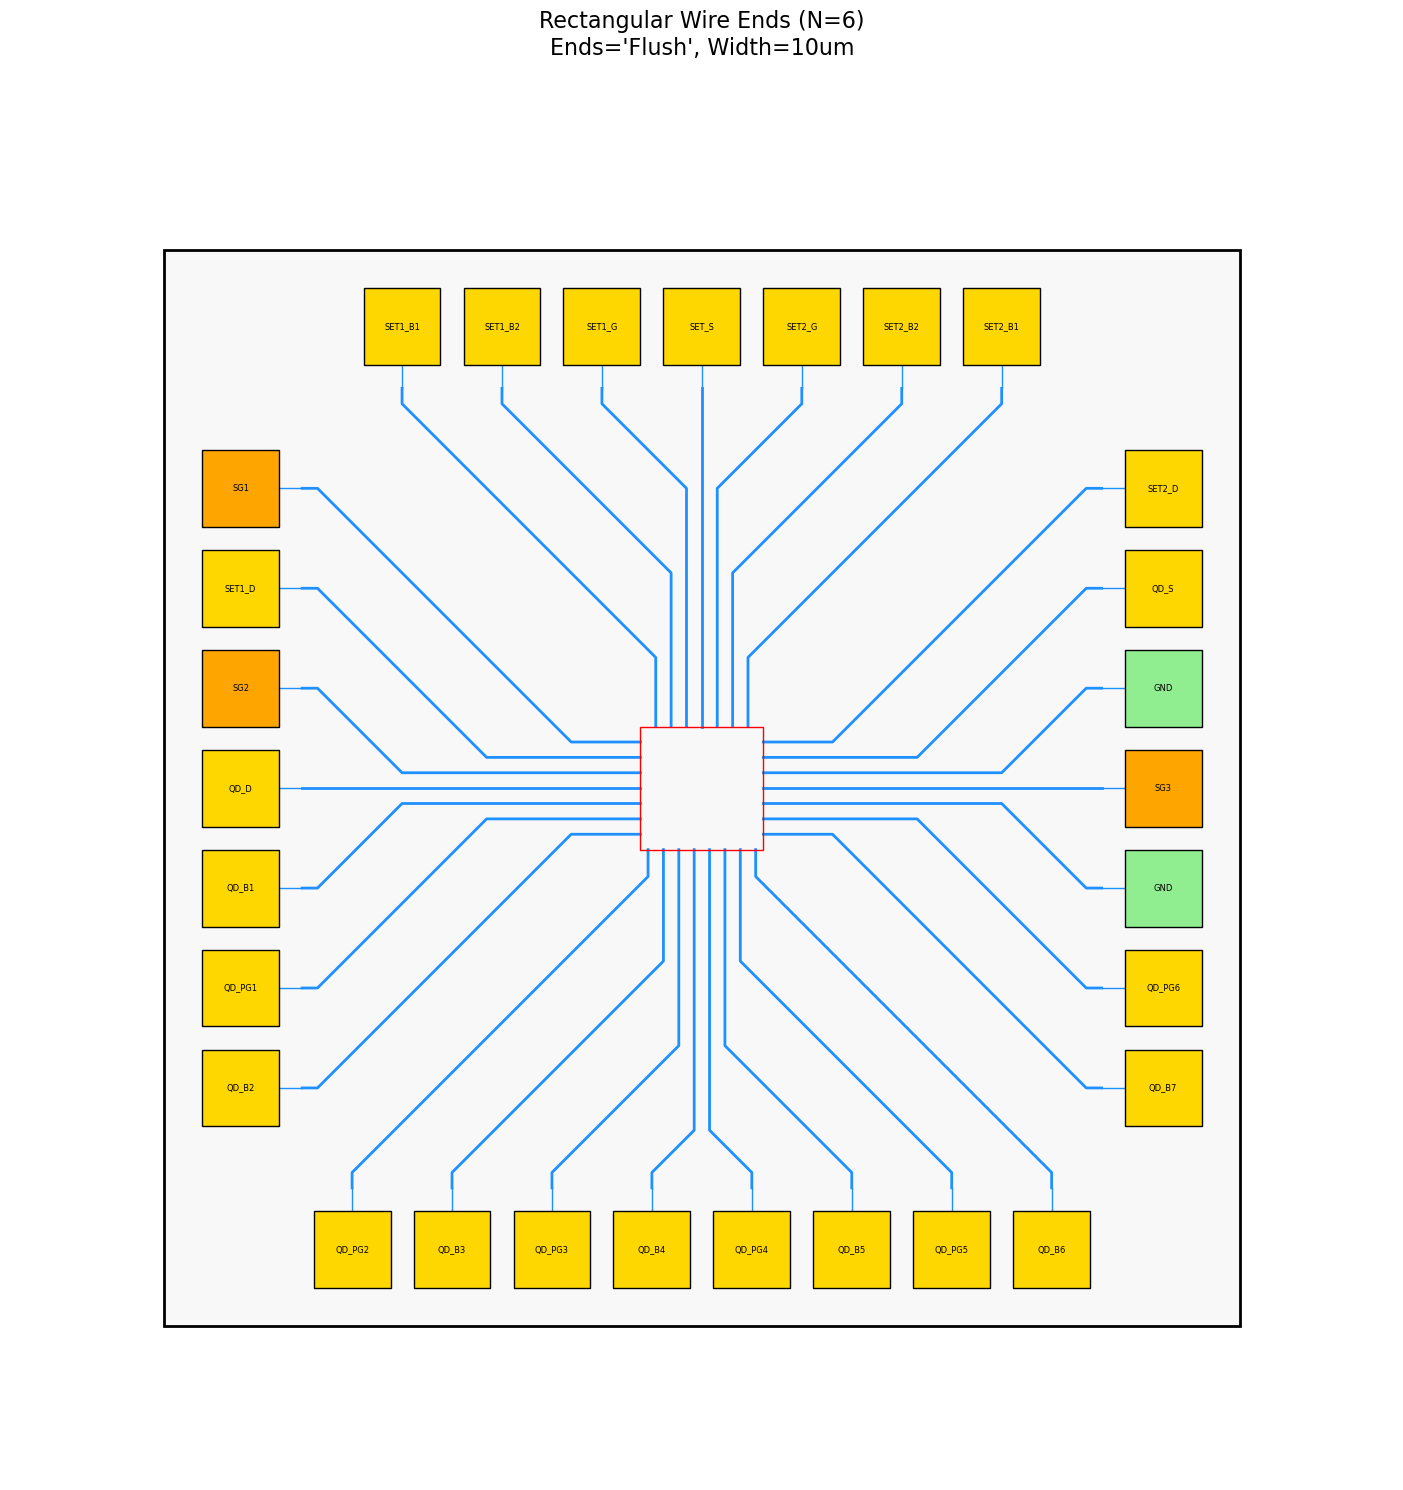

In [ ]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re
import numpy as np

def create_rect_wire_layout(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=100,      
    pad_spacing=30,
    edge_margin=100,
    active_size=200,     
    trace_width=10,
    trace_spacing=10,    
    taper_length=40,
    active_entry_len=100,
    gds_filename='qd_layout_rect_wire.gds'
):
    """
    Generates a Pad Layout where wires entering the active region are 
    rectangular polylines (constant width, flat ends), removing any arrow/taper effects at the center.
    """

    # ==========================================
    # 1. Pad Generation (Symmetric Logic)
    # ==========================================
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    top_pads = []
    if num_sets >= 1: top_pads.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_pads.append("SET_S")
    if num_sets >= 2: top_pads.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    left_fixed = ["SG1"]
    if num_sets >= 1: left_fixed.append("SET1_D") 
    left_fixed.extend(["SG2", "QD_D"])
    
    right_fixed = []
    if num_sets >= 2: right_fixed.append("SET2_D")
    right_fixed.append("QD_S")
    right_fixed.extend(["GND", "SG3", "GND"]) 

    # Symmetry Logic
    len_seq = len(gate_sequence)
    len_L_fix = len(left_fixed)
    len_R_fix = len(right_fixed)
    len_Top = len(top_pads)
    
    available_w = layout_width - 2 * edge_margin
    best_config = (0, len_seq, 0)
    min_diff = float('inf')
    
    start_side = max(len_L_fix, len_R_fix)
    for target_side in range(start_side, start_side + len_seq):
        add_L = target_side - len_L_fix
        add_R = target_side - len_R_fix
        if add_L + add_R > len_seq: break
        n_bot = len_seq - (add_L + add_R)
        if n_bot > 0 and (n_bot * pad_width + (n_bot-1)*pad_spacing > available_w): continue
        diff = abs(n_bot - len_Top)
        if diff < min_diff:
            min_diff = diff
            best_config = (add_L, n_bot, add_R)
            
    n_L, n_B, n_R = best_config
    pads_left_extra = gate_sequence[:n_L]
    pads_bottom = gate_sequence[n_L : n_L + n_B]
    pads_right_extra = gate_sequence[n_L + n_B :]

    left_pads = left_fixed + pads_left_extra
    right_pads = right_fixed + pads_right_extra

    all_pads = [] 
    def assign_coords(pads, edge):
        count = len(pads)
        if count == 0: return
        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            for i, label in enumerate(pads):
                x = start_x + i * (pad_width + pad_spacing)
                cx, cy = x + pad_width/2, y + pad_height/2
                all_pads.append({'label': label, 'rect': (x, y, pad_width, pad_height), 'center': (cx, cy), 'edge': edge})
        else:
            total_span = count * pad_width + (count - 1) * pad_spacing
            top_y = (layout_height + total_span) / 2
            x = edge_margin if edge == 'left' else layout_width - edge_margin - pad_height
            for i, label in enumerate(pads):
                y = top_y - (i+1)*pad_width - i*pad_spacing
                cx, cy = x + pad_height/2, y + pad_width/2
                all_pads.append({'label': label, 'rect': (x, y, pad_height, pad_width), 'center': (cx, cy), 'edge': edge})

    assign_coords(top_pads, 'top')
    assign_coords(pads_bottom, 'bottom')
    assign_coords(left_pads, 'left')
    assign_coords(right_pads, 'right')

    # ==========================================
    # 2. Target Assignment
    # ==========================================
    center_x = layout_width / 2
    center_y = layout_height / 2
    aa_x1 = center_x - active_size/2
    aa_x2 = center_x + active_size/2
    aa_y1 = center_y - active_size/2
    aa_y2 = center_y + active_size/2

    pads_by_edge = {'top': [], 'bottom': [], 'left': [], 'right': []}
    for p in all_pads: pads_by_edge[p['edge']].append(p)

    pads_by_edge['top'].sort(key=lambda p: p['center'][0])
    pads_by_edge['bottom'].sort(key=lambda p: p['center'][0])
    pads_by_edge['left'].sort(key=lambda p: p['center'][1], reverse=True)
    pads_by_edge['right'].sort(key=lambda p: p['center'][1], reverse=True)

    pitch = trace_width + trace_spacing
    
    def assign_targets(pads, edge):
        n = len(pads)
        if n == 0: return
        indices = np.arange(n) - (n - 1) / 2
        offsets = indices * pitch
        
        if edge == 'top':
            for i, p in enumerate(pads):
                p['target'] = (center_x + offsets[i], aa_y2)
                p['target_edge'] = 'top'
        elif edge == 'bottom':
            for i, p in enumerate(pads):
                p['target'] = (center_x + offsets[i], aa_y1)
                p['target_edge'] = 'bottom'
        elif edge == 'left':
            for i, p in enumerate(pads):
                p['target'] = (aa_x1, center_y + offsets[-(i+1)])
                p['target_edge'] = 'left'
        elif edge == 'right':
            for i, p in enumerate(pads):
                p['target'] = (aa_x2, center_y + offsets[-(i+1)])
                p['target_edge'] = 'right'

    for edge in ['top', 'bottom', 'left', 'right']:
        assign_targets(pads_by_edge[edge], edge)

    # ==========================================
    # 3. GDS Generation (Updated Routing)
    # ==========================================
    lib = gdstk.Library()
    cell = lib.new_cell('QD_RECT_WIRE')
    LAYER_SUBSTRATE, LAYER_PAD, LAYER_TEXT, LAYER_TRACE, LAYER_ACTIVE = 0, 1, 2, 3, 10
    
    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=LAYER_SUBSTRATE))
    cell.add(gdstk.rectangle((aa_x1, aa_y1), (aa_x2, aa_y2), layer=LAYER_ACTIVE))

    def create_taper(p_rect, edge, t_len, t_width):
        x, y, w, h = p_rect
        cx, cy = x + w/2, y + h/2
        if edge == 'top':
            pts = [(x, y), (x+w, y), (cx+t_width/2, y-t_len), (cx-t_width/2, y-t_len)]
            start = (cx, y - t_len)
        elif edge == 'bottom':
            pts = [(x, y+h), (x+w, y+h), (cx+t_width/2, y+h+t_len), (cx-t_width/2, y+h+t_len)]
            start = (cx, y + h + t_len)
        elif edge == 'left':
            pts = [(x+w, y), (x+w, y+h), (x+w+t_len, cy+t_width/2), (x+w+t_len, cy-t_width/2)]
            start = (x+w+t_len, cy)
        elif edge == 'right':
            pts = [(x, y), (x, y+h), (x-t_len, cy+t_width/2), (x-t_len, cy-t_width/2)]
            start = (x-t_len, cy)
        return gdstk.Polygon(pts, layer=LAYER_TRACE), start

    def route_safe_z(start_pt, target_pt, edge, width):
        """
        Calculates points for Safe Z-Routing.
        Returns a gdstk.FlexPath with 'flush' ends (rectangular).
        """
        x1, y1 = start_pt
        x2, y2 = target_pt
        
        safe_margin = 20 
        pts = [(x1, y1)]
        
        if edge in ['top', 'bottom']:
            is_top = (edge == 'top')
            sign_y = -1 if is_top else 1
            y_safe = y1 + sign_y * safe_margin
            pts.append((x1, y_safe))
            y_entry = y2 + sign_y * active_entry_len 
            
            avail_h = abs(y_entry - y_safe)
            needed_w = abs(x2 - x1)
            sign_x = 1 if x2 > x1 else -1
            
            if needed_w > avail_h:
                h_leg = avail_h / 2
                y_mid = y_safe + sign_y * h_leg
                x_mid_1 = x1 + sign_x * h_leg
                x_mid_2 = x2 - sign_x * h_leg
                pts.append((x_mid_1, y_mid))
                pts.append((x_mid_2, y_mid))
                # pts.append((x2, y_entry))
            else:
                dy_diag = needed_w
                y_turn_end = y_safe + sign_y * dy_diag
                pts.append((x2, y_turn_end))
                # pts.append((x2, y_entry))
            pts.append((x2, y2))
                
        else: # Left / Right
            is_left = (edge == 'left')
            sign_x = 1 if is_left else -1
            x_safe = x1 + sign_x * safe_margin
            pts.append((x_safe, y1))
            x_entry = x2 + sign_x * active_entry_len
            
            avail_w = abs(x_entry - x_safe)
            needed_h = abs(y2 - y1)
            sign_y = 1 if y2 > y1 else -1
            
            if needed_h > avail_w:
                w_leg = avail_w / 2
                x_mid = x_safe + sign_x * w_leg
                y_mid_1 = y1 + sign_y * w_leg
                y_mid_2 = y2 - sign_y * w_leg
                pts.append((x_mid, y_mid_1))
                pts.append((x_mid, y_mid_2))
                # pts.append((x_entry, y2))
            else:
                dx_diag = needed_h
                x_turn_end = x_safe + sign_x * dx_diag
                pts.append((x_turn_end, y2))
                # pts.append((x_entry, y2))
            pts.append((x2, y2))
            
        # [MODIFICATION] Create FlexPath with "flush" ends to ensure rectangular ends
        path = gdstk.FlexPath(pts, width, ends="flush", layer=LAYER_TRACE)
        return path, pts

    # Loop
    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        edge = p['edge']
        
        cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=LAYER_PAD))
        
        cx, cy = x + w/2, y + h/2
        rot_rad = 0 if w > h else math.pi / 2
        cell.add(gdstk.Label(label, (cx, cy), layer=LAYER_TEXT, magnification=10, rotation=rot_rad))
        
        poly_taper, trace_start = create_taper(p['rect'], edge, taper_length, trace_width)
        cell.add(poly_taper)
        
        path_obj, path_pts = route_safe_z(trace_start, p['target'], edge, trace_width)
        print('Routing Pad:', label, 'from', trace_start, 'to', p['target'], 'via', path_pts)
        cell.add(path_obj)
        p['trace_points'] = path_pts

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # Visualization
    fig, ax = plt.subplots(figsize=(15, 15))
    margin_view = 200
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f8f8f8')
    ax.add_patch(chip)
    active_area = patches.Rectangle((aa_x1, aa_y1), active_size, active_size, lw=1, ec='red', fc='none', zorder=10)
    ax.add_patch(active_area)

    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc, zorder=5)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=6, rotation=t_rot, zorder=6)
        
        if 'trace_points' in p:
            pts = p['trace_points']
            line_x, line_y = zip(*pts)
            ax.plot(line_x, line_y, color='#1E90FF', linewidth=2, zorder=4)
            _, t_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
            cx, cy = x + w/2, y + h/2
            ax.plot([cx, t_start[0]], [cy, t_start[1]], color='#1E90FF', linewidth=1, zorder=4)

    plt.title(f"Rectangular Wire Ends (N={N})\nEnds='Flush', Width={trace_width}um", fontsize=16, pad=30)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    create_rect_wire_layout(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 50,
        active_size = 180,     
        trace_width = 10,    # [设置] 10um 导线宽度
        trace_spacing = 10,
        taper_length = 30,
        active_entry_len = 20
    )

GDS file saved to: qd_layout_fixed_order.gds


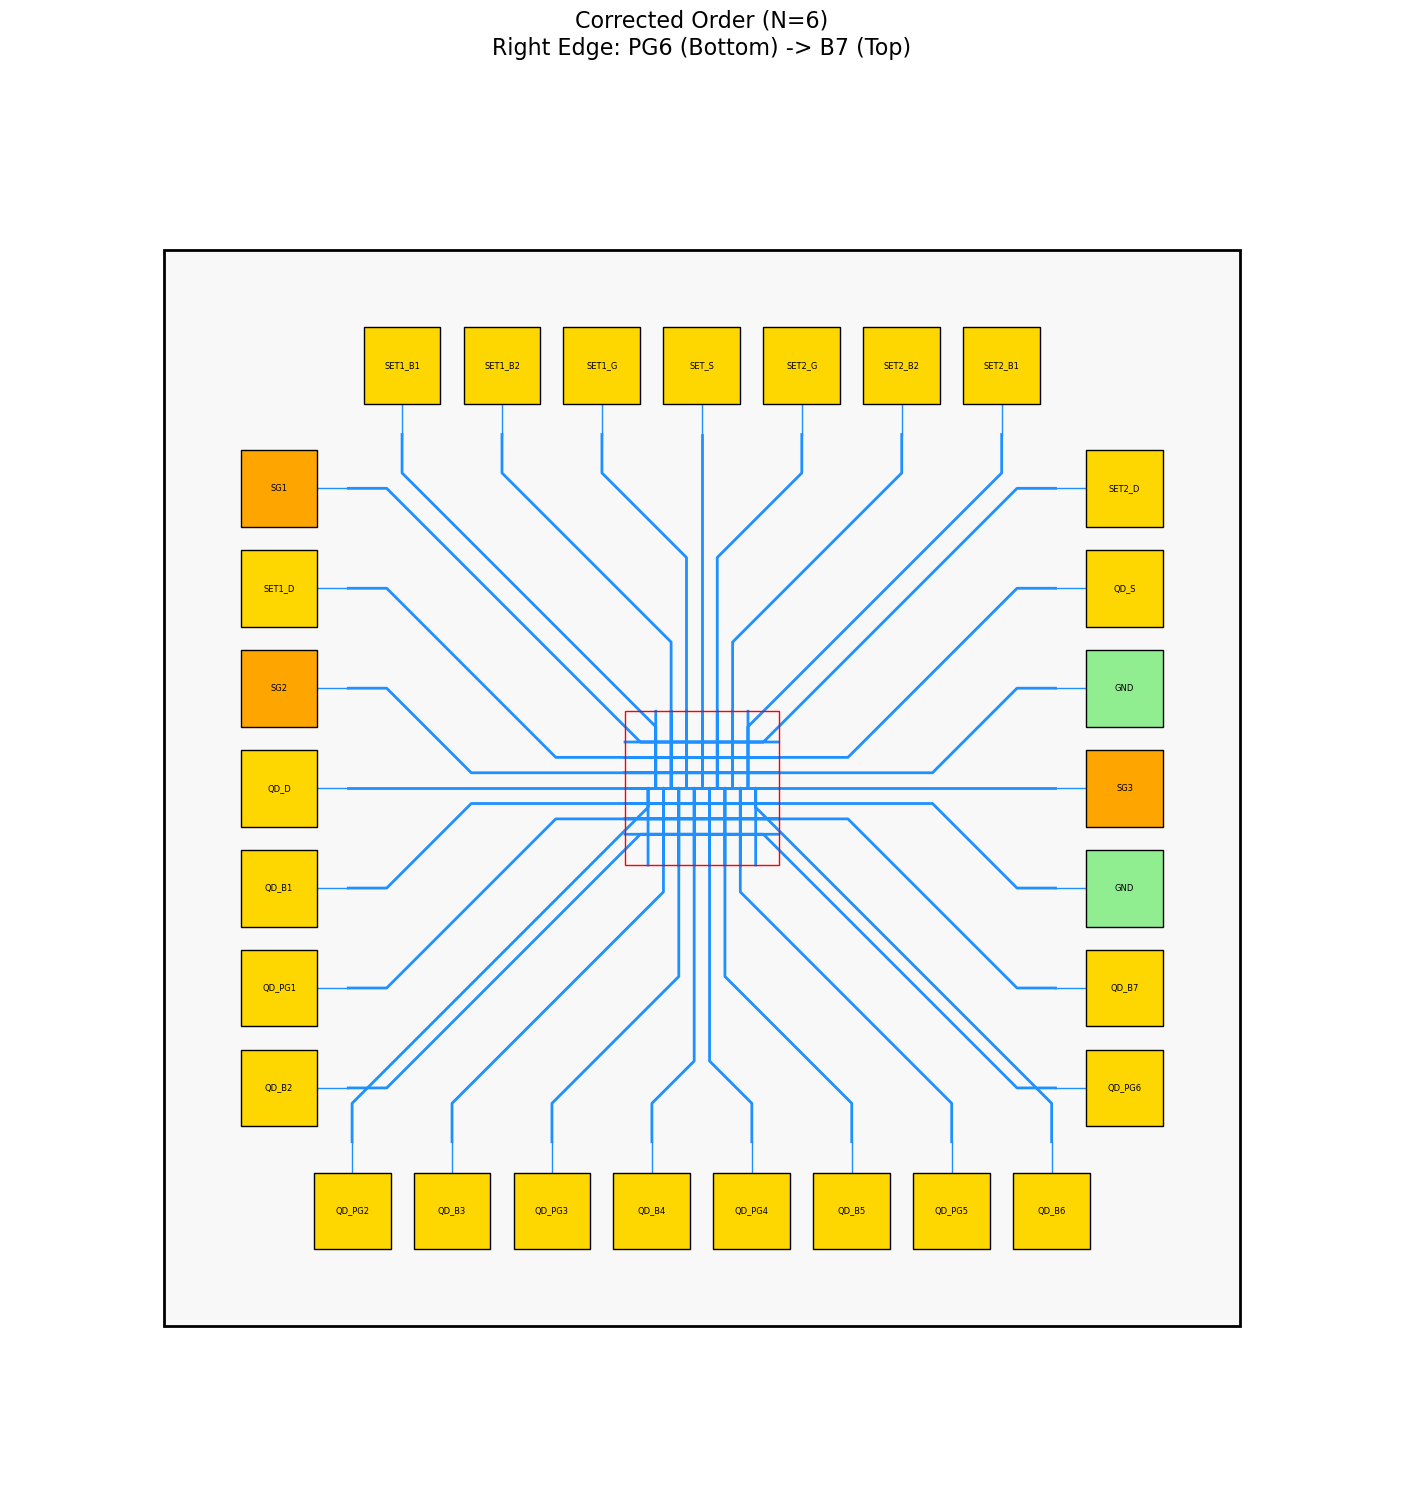

In [1]:
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import re
import numpy as np

def create_rect_wire_layout_fixed_order(
    N=6,
    layout_width=1400,
    layout_height=1400,
    pad_width=100,
    pad_height=100,      
    pad_spacing=30,
    edge_margin=100,
    active_size=200,     
    trace_width=10,
    trace_spacing=10,    
    taper_length=40,
    active_entry_len=100,
    gds_filename='qd_layout_fixed_order.gds'
):
    """
    Generates a Pad Layout with corrected sequence order for the Right Edge.
    - Right Edge Extra Pads are reversed to match the Bottom-up geometric flow.
    - Result: QD_PG6 is at the bottom (near QD_B6), QD_B7 is above it.
    """

    # ==========================================
    # 1. Pad Generation & Distribution
    # ==========================================
    def natural_sort_key(s):
        return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

    num_sets = math.ceil(N / 3)
    pg_labels = sorted([f"QD_PG{i+1}" for i in range(N)], key=natural_sort_key)
    bg_labels = sorted([f"QD_B{i+1}" for i in range(N + 1)], key=natural_sort_key)

    gate_sequence = []
    for i in range(N):
        gate_sequence.append(bg_labels[i])
        gate_sequence.append(pg_labels[i])
    gate_sequence.append(bg_labels[N])

    top_pads = []
    if num_sets >= 1: top_pads.extend(["SET1_B1", "SET1_B2", "SET1_G"])
    top_pads.append("SET_S")
    if num_sets >= 2: top_pads.extend(["SET2_G", "SET2_B2", "SET2_B1"])

    left_fixed = ["SG1"]
    if num_sets >= 1: left_fixed.append("SET1_D") 
    left_fixed.extend(["SG2", "QD_D"])
    
    right_fixed = []
    if num_sets >= 2: right_fixed.append("SET2_D")
    right_fixed.append("QD_S")
    right_fixed.extend(["GND", "SG3", "GND"]) 

    # Symmetry Logic
    len_seq = len(gate_sequence)
    len_L_fix = len(left_fixed)
    len_R_fix = len(right_fixed)
    len_Top = len(top_pads)
    
    available_w = layout_width - 2 * edge_margin
    best_config = (0, len_seq, 0)
    min_diff = float('inf')
    
    start_side = max(len_L_fix, len_R_fix)
    for target_side in range(start_side, start_side + len_seq):
        add_L = target_side - len_L_fix
        add_R = target_side - len_R_fix
        if add_L + add_R > len_seq: break
        n_bot = len_seq - (add_L + add_R)
        if n_bot > 0 and (n_bot * pad_width + (n_bot-1)*pad_spacing > available_w): continue
        diff = abs(n_bot - len_Top)
        if diff < min_diff:
            min_diff = diff
            best_config = (add_L, n_bot, add_R)
            
    n_L, n_B, n_R = best_config
    pads_left_extra = gate_sequence[:n_L]
    pads_bottom = gate_sequence[n_L : n_L + n_B]
    pads_right_extra = gate_sequence[n_L + n_B :]

    # [FIX] Reverse the Right Extra Pads
    # Because right_pads list is filled Top-to-Bottom, 
    # but the sequence arrives from the Bottom.
    pads_right_extra = pads_right_extra[::-1]

    left_pads = left_fixed + pads_left_extra
    right_pads = right_fixed + pads_right_extra

    # Coordinate Assignment
    all_pads = [] 
    def assign_coords(pads, edge):
        count = len(pads)
        if count == 0: return
        if edge in ['top', 'bottom']:
            total_span = count * pad_width + (count - 1) * pad_spacing
            start_x = (layout_width - total_span) / 2
            y = layout_height - edge_margin - pad_height if edge == 'top' else edge_margin
            for i, label in enumerate(pads):
                x = start_x + i * (pad_width + pad_spacing)
                cx, cy = x + pad_width/2, y + pad_height/2
                all_pads.append({'label': label, 'rect': (x, y, pad_width, pad_height), 'center': (cx, cy), 'edge': edge})
        else:
            total_span = count * pad_width + (count - 1) * pad_spacing
            top_y = (layout_height + total_span) / 2
            x = edge_margin if edge == 'left' else layout_width - edge_margin - pad_height
            for i, label in enumerate(pads):
                y = top_y - (i+1)*pad_width - i*pad_spacing
                cx, cy = x + pad_height/2, y + pad_width/2
                all_pads.append({'label': label, 'rect': (x, y, pad_height, pad_width), 'center': (cx, cy), 'edge': edge})

    assign_coords(top_pads, 'top')
    assign_coords(pads_bottom, 'bottom')
    assign_coords(left_pads, 'left')
    assign_coords(right_pads, 'right')

    # ==========================================
    # 2. Target Assignment
    # ==========================================
    center_x = layout_width / 2
    center_y = layout_height / 2
    aa_x1 = center_x - active_size/2
    aa_x2 = center_x + active_size/2
    aa_y1 = center_y - active_size/2
    aa_y2 = center_y + active_size/2

    pads_by_edge = {'top': [], 'bottom': [], 'left': [], 'right': []}
    for p in all_pads: pads_by_edge[p['edge']].append(p)

    pads_by_edge['top'].sort(key=lambda p: p['center'][0])
    pads_by_edge['bottom'].sort(key=lambda p: p['center'][0])
    pads_by_edge['left'].sort(key=lambda p: p['center'][1], reverse=True)
    pads_by_edge['right'].sort(key=lambda p: p['center'][1], reverse=True)

    pitch = trace_width + trace_spacing
    
    def assign_targets(pads, edge):
        n = len(pads)
        if n == 0: return
        indices = np.arange(n) - (n - 1) / 2
        offsets = indices * pitch
        
        if edge == 'top':
            for i, p in enumerate(pads):
                p['target'] = (center_x + offsets[i], aa_y2)
                p['target_edge'] = 'top'
        elif edge == 'bottom':
            for i, p in enumerate(pads):
                p['target'] = (center_x + offsets[i], aa_y1)
                p['target_edge'] = 'bottom'
        elif edge == 'left':
            for i, p in enumerate(pads):
                p['target'] = (aa_x1, center_y + offsets[-(i+1)])
                p['target_edge'] = 'left'
        elif edge == 'right':
            for i, p in enumerate(pads):
                p['target'] = (aa_x2, center_y + offsets[-(i+1)])
                p['target_edge'] = 'right'

    for edge in ['top', 'bottom', 'left', 'right']:
        assign_targets(pads_by_edge[edge], edge)

    # ==========================================
    # 3. GDS Generation
    # ==========================================
    lib = gdstk.Library()
    cell = lib.new_cell('QD_FIXED_ORDER')
    LAYER_SUBSTRATE, LAYER_PAD, LAYER_TEXT, LAYER_TRACE, LAYER_ACTIVE = 0, 1, 2, 3, 10
    
    cell.add(gdstk.rectangle((0, 0), (layout_width, layout_height), layer=LAYER_SUBSTRATE))
    cell.add(gdstk.rectangle((aa_x1, aa_y1), (aa_x2, aa_y2), layer=LAYER_ACTIVE))

    def create_taper(p_rect, edge, t_len, t_width):
        x, y, w, h = p_rect
        cx, cy = x + w/2, y + h/2
        if edge == 'top':
            pts = [(x, y), (x+w, y), (cx+t_width/2, y-t_len), (cx-t_width/2, y-t_len)]
            start = (cx, y - t_len)
        elif edge == 'bottom':
            pts = [(x, y+h), (x+w, y+h), (cx+t_width/2, y+h+t_len), (cx-t_width/2, y+h+t_len)]
            start = (cx, y + h + t_len)
        elif edge == 'left':
            pts = [(x+w, y), (x+w, y+h), (x+w+t_len, cy+t_width/2), (x+w+t_len, cy-t_width/2)]
            start = (x+w+t_len, cy)
        elif edge == 'right':
            pts = [(x, y), (x, y+h), (x-t_len, cy+t_width/2), (x-t_len, cy-t_width/2)]
            start = (x-t_len, cy)
        return gdstk.Polygon(pts, layer=LAYER_TRACE), start

    def route_safe_z(start_pt, target_pt, edge, width):
        x1, y1 = start_pt
        x2, y2 = target_pt
        
        safe_margin = 50 
        pts = [(x1, y1)]
        
        if edge in ['top', 'bottom']:
            is_top = (edge == 'top')
            sign_y = -1 if is_top else 1
            y_safe = y1 + sign_y * safe_margin
            pts.append((x1, y_safe))
            y_entry = y2 + sign_y * active_entry_len 
            
            avail_h = abs(y_entry - y_safe)
            needed_w = abs(x2 - x1)
            sign_x = 1 if x2 > x1 else -1
            
            if needed_w > avail_h:
                h_leg = avail_h / 2
                y_mid = y_safe + sign_y * h_leg
                x_mid_1 = x1 + sign_x * h_leg
                x_mid_2 = x2 - sign_x * h_leg
                pts.append((x_mid_1, y_mid))
                pts.append((x_mid_2, y_mid))
                pts.append((x2, y_entry))
            else:
                dy_diag = needed_w
                y_turn_end = y_safe + sign_y * dy_diag
                pts.append((x2, y_turn_end))
                pts.append((x2, y_entry))
            pts.append((x2, y2))
                
        else: # Left / Right
            is_left = (edge == 'left')
            sign_x = 1 if is_left else -1
            x_safe = x1 + sign_x * safe_margin
            pts.append((x_safe, y1))
            x_entry = x2 + sign_x * active_entry_len
            
            avail_w = abs(x_entry - x_safe)
            needed_h = abs(y2 - y1)
            sign_y = 1 if y2 > y1 else -1
            
            if needed_h > avail_w:
                w_leg = avail_w / 2
                x_mid = x_safe + sign_x * w_leg
                y_mid_1 = y1 + sign_y * w_leg
                y_mid_2 = y2 - sign_y * w_leg
                pts.append((x_mid, y_mid_1))
                pts.append((x_mid, y_mid_2))
                pts.append((x_entry, y2))
            else:
                dx_diag = needed_h
                x_turn_end = x_safe + sign_x * dx_diag
                pts.append((x_turn_end, y2))
                pts.append((x_entry, y2))
            pts.append((x2, y2))
            
        path = gdstk.FlexPath(pts, width, layer=LAYER_TRACE, ends="flush")
        return path, pts

    # Loop
    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        edge = p['edge']
        
        cell.add(gdstk.rectangle((x, y), (x + w, y + h), layer=LAYER_PAD))
        
        cx, cy = x + w/2, y + h/2
        rot_rad = 0 if w > h else math.pi / 2
        cell.add(gdstk.Label(label, (cx, cy), layer=LAYER_TEXT, magnification=10, rotation=rot_rad))
        
        poly_taper, trace_start = create_taper(p['rect'], edge, taper_length, trace_width)
        cell.add(poly_taper)
        
        path_obj, path_pts = route_safe_z(trace_start, p['target'], edge, trace_width)
        cell.add(path_obj)
        p['trace_points'] = path_pts

    lib.write_gds(gds_filename)
    print(f"GDS file saved to: {gds_filename}")

    # Visualization
    fig, ax = plt.subplots(figsize=(15, 15))
    margin_view = 200
    ax.set_xlim(-margin_view, layout_width + margin_view)
    ax.set_ylim(-margin_view, layout_height + margin_view)
    ax.set_aspect('equal')
    
    chip = patches.Rectangle((0, 0), layout_width, layout_height, lw=2, ec='black', fc='#f8f8f8')
    ax.add_patch(chip)
    active_area = patches.Rectangle((aa_x1, aa_y1), active_size, active_size, lw=1, ec='red', fc='none', zorder=10)
    ax.add_patch(active_area)

    for p in all_pads:
        x, y, w, h = p['rect']
        label = p['label']
        fc = 'gold'
        if 'GND' in label: fc = 'lightgreen'
        if 'SG' in label: fc = 'orange'
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='black', facecolor=fc, zorder=5)
        ax.add_patch(rect)
        t_rot = 90 if w < h else 0
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=6, rotation=t_rot, zorder=6)
        
        if 'trace_points' in p:
            pts = p['trace_points']
            line_x, line_y = zip(*pts)
            ax.plot(line_x, line_y, color='#1E90FF', linewidth=2, zorder=4)
            _, t_start = create_taper(p['rect'], p['edge'], taper_length, trace_width)
            cx, cy = x + w/2, y + h/2
            ax.plot([cx, t_start[0]], [cy, t_start[1]], color='#1E90FF', linewidth=1, zorder=4)

    plt.title(f"Corrected Order (N={N})\nRight Edge: PG6 (Bottom) -> B7 (Top)", fontsize=16, pad=30)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    create_rect_wire_layout_fixed_order(
        N = 6,
        layout_width = 1400,
        layout_height = 1400,
        pad_width = 100,
        pad_height = 100,      
        pad_spacing = 30,
        edge_margin = 100,
        active_size = 200, 
        trace_width = 10,
        trace_spacing = 10,
        taper_length = 40,
        active_entry_len = 100
    )